# Silicon Valley Bank - Data Analysis

## 0. Imports and Functions

In [226]:
# ======================================================
# SVB analysis â€” ordered, in-memory, and clean display
# ======================================================

import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import statsmodels.api as sm
from statsmodels.stats.outliers_influence import variance_inflation_factor
from scipy.stats import chi2
import seaborn as sns
from fredapi import Fred
from IPython.display import display
import pandas_market_calendars as mcal

sns.set_theme(context="notebook", style="whitegrid")

# -----------------------------
# Helpers used multiple times
# -----------------------------
def add_covid_shade(ax):
    ax.axvspan(COVID_START, COVID_END, color='grey', alpha=0.15)

def winsorize_series(s, p=0.01):
    lo, hi = s.quantile([p, 1-p])
    return s.clip(lo, hi)

def fit_ols_hac(X, y):
    return sm.OLS(y, X).fit(cov_type='HAC', cov_kwds={'maxlags':5})

def tidy_coef_table(model):
    rows = []
    for name in model.params.index:
        rows.append({
            "var": name,
            "coef": model.params[name],
            "se": model.bse[name],
            "t": model.tvalues[name],
            "p": model.pvalues[name]
        })
    return pd.DataFrame(rows)[["var","coef","se","t","p"]]

def compute_vif(X_no_const):
    Xv = sm.add_constant(X_no_const, has_constant='add')
    vals = []
    for i, col in enumerate(Xv.columns):
        if col == "const": 
            continue
        try:
            v = variance_inflation_factor(Xv.values, i)
        except Exception:
            v = np.nan
        vals.append((col, v))
    return pd.DataFrame(vals, columns=["feature","VIF"]).replace([np.inf, -np.inf], np.nan)

def regime_dummies(index, b1, b2=None):
    d = pd.DataFrame(index=index)
    if b2 is None:
        pre, post = f"Pre-{b1.date()}", f"Post-{b1.date()}"
        d[pre] = (index < b1).astype(int)
        d[post] = (index >= b1).astype(int)
        return d, [pre, post]
    r1, r2, r3 = f"Pre-{b1.date()}", f"{b1.date()} to {b2.date()}", f"Post-{b2.date()}"
    d[r1] = (index < b1).astype(int)
    d[r2] = ((index >= b1) & (index < b2)).astype(int)
    d[r3] = (index >= b2).astype(int)
    return d, [r1, r2, r3]

def build_X_interactions(Xb, R, regimes):
    X = Xb.copy()
    for r in regimes[1:]:
        for col in Xb.columns:
            X[f"{col}_x_{r}"] = Xb[col].values * R[r].values
    return X

def extract_full_betas(res, Xb_cols, regimes):
    P, V = res.params, res.cov_params()
    rows = []
    for col in Xb_cols:  # includes const
        J, labels = [], []
        j0 = np.zeros(len(P)); j0[P.index.get_loc(col)] = 1.0
        J.append(j0); labels.append(f"{col}:{regimes[0]}")
        for r in regimes[1:]:
            jr = np.zeros(len(P)); jr[P.index.get_loc(col)] = 1.0
            iname = f"{col}_x_{r}"
            if iname in P.index:
                jr[P.index.get_loc(iname)] = 1.0
            J.append(jr); labels.append(f"{col}:{r}")
        J = np.vstack(J)
        b = J @ P.values
        C = J @ V.values @ J.T
        se = np.sqrt(np.diag(C))
        t = b / se
        for lab, bi, sei, ti in zip(labels, b, se, t):
            var, reg = lab.split(":")
            rows.append({"var": var, "regime": reg, "coef": bi, "se": sei, "t": ti})
    return pd.DataFrame(rows)

def wald_equal_betas(res, Xb_cols, regimes):
    P, V = res.params, res.cov_params()
    out = {}
    for col in Xb_cols:
        J = []
        j0 = np.zeros(len(P)); j0[P.index.get_loc(col)] = 1.0
        J.append(j0)
        for r in regimes[1:]:
            jr = np.zeros(len(P)); jr[P.index.get_loc(col)] = 1.0
            iname = f"{col}_x_{r}"
            if iname in P.index: jr[P.index.get_loc(iname)] = 1.0
            J.append(jr)
        J = np.vstack(J)
        b = J @ P.values
        C = J @ V.values @ J.T
        if len(regimes) > 1:
            Rm = []
            for k in range(1, len(regimes)):
                row = np.zeros(len(regimes)); row[k] = 1.0; row[0] = -1.0
                Rm.append(row)
            Rm = np.vstack(Rm)
            Rc = Rm @ C @ Rm.T
            stat = float((Rm @ b).T @ np.linalg.inv(Rc) @ (Rm @ b))
            df = Rm.shape[0]; pval = chi2.sf(stat, df)
        else:
            stat = np.nan; df = 0; pval = np.nan
        out[col] = {"chi2": stat, "df": df, "p": pval}
    return out

def wald_pairwise_betas(res, Xb_cols, regimes):
    P, V = res.params, res.cov_params()
    out = {}
    for col in Xb_cols:
        J = []
        j0 = np.zeros(len(P)); j0[P.index.get_loc(col)] = 1.0
        J.append(j0)
        for r in regimes[1:]:
            jr = np.zeros(len(P)); jr[P.index.get_loc(col)] = 1.0
            iname = f"{col}_x_{r}"
            if iname in P.index: jr[P.index.get_loc(iname)] = 1.0
            J.append(jr)
        J = np.vstack(J)
        b = J @ P.values
        C = J @ V.values @ J.T
        tests = []
        for i in range(len(regimes)):
            for j in range(i+1, len(regimes)):
                R = np.zeros(len(regimes)); R[i] = 1; R[j] = -1
                diff = R @ b
                var  = R @ C @ R.T
                if var > 0:
                    stat = float(diff**2 / var); pval = chi2.sf(stat, 1)
                else:
                    stat = np.nan; pval = np.nan
                tests.append({"reg1": regimes[i], "reg2": regimes[j], "chi2": stat, "p": pval})
        out[col] = tests
    return out

def regime_fit_stats(Y, X_base, tab, regimes, R):
    res = []
    for r in regimes:
        mask = R[r] == 1
        y_sub = Y.loc[mask]
        X_sub = X_base.loc[mask]
        sub_tab = tab[tab['regime'] == r].set_index('var')
        betas = sub_tab['coef'].reindex(X_sub.columns).values
        y_hat = X_sub.values @ betas
        resid = y_sub.values - y_hat
        ss_res = np.sum(resid**2)
        ss_tot = np.sum((y_sub - y_sub.mean())**2)
        r2 = 1 - ss_res/ss_tot if ss_tot > 0 else np.nan
        n = len(y_sub)
        k = X_sub.shape[1] - 1
        adj_r2 = 1 - (1-r2) * (n-1)/(n-k-1) if n > k+1 else np.nan
        res.append({"Regime": r, "Obs": n, "Adj_R2": round(adj_r2, 3)})
    return pd.DataFrame(res).set_index("Regime")

def add_residualized(df, target, base):
    """
    Create a column '<target>_on_<base>' = residuals of target ~ base.
    """
    newcol = f"{target}_on_{base}"
    if newcol not in df.columns:
        df[newcol] = sm.OLS(df[target], sm.add_constant(df[base], has_constant='add')).fit().resid
    return df

def prepare_rhs(df, rhs_vars):
    """
    Expand rhs_vars: if any are like 'X_on_Y', create residualized column.
    """
    dfX = df.copy()
    rhs_eff = []
    for v in rhs_vars:
        if "_on_" in v:
            target, base = v.split("_on_")
            dfX = add_residualized(dfX, target, base)
            rhs_eff.append(v)  # keep the new name
        else:
            rhs_eff.append(v)
    return dfX, rhs_eff

# -----------------------------
# Core runners
# -----------------------------
def run_baseline(df, rhs_vars, dep="SVB"):
    XY = df[[dep] + rhs_vars].dropna()
    Y = XY[dep]
    X = sm.add_constant(XY[rhs_vars], has_constant='add')
    m = fit_ols_hac(X, Y)
    return {
        "dep": dep,
        "coefs": tidy_coef_table(m),
        "N": int(m.nobs),
        "Adj_R2": float(m.rsquared_adj),
        "vif": compute_vif(X.drop(columns=['const'])),
        "model": m,
    }

def run_regime(df, rhs_vars, dep="SVB", two_state=True):
    XY = df[[dep] + rhs_vars].dropna()
    Y = XY[dep]
    Xb = sm.add_constant(XY[rhs_vars], has_constant='add')

    if two_state:
        R, regs = regime_dummies(Y.index, BREAK_1, None)
    else:
        R, regs = regime_dummies(Y.index, BREAK_1, BREAK_2)

    X = build_X_interactions(Xb, R, regs)
    m = fit_ols_hac(X, Y)

    full_betas = extract_full_betas(m, Xb.columns, regs)
    w_over = wald_equal_betas(m, Xb.columns, regs)
    w_pair = wald_pairwise_betas(m, Xb.columns, regs)
    fstats  = regime_fit_stats(Y, Xb, full_betas, regs, R)

    return {
        "full_betas": full_betas,     # coef, se, t by regime and var
        "wald_overall": w_over,       # per var dict: chi2, df, p
        "wald_pairwise": w_pair,      # per var list of pairwise tests
        "fitstats": fstats,           # per regime N and Adj_R2
        "vif": compute_vif(Xb.drop(columns=['const'])),
        "regimes": regs,
        "model": m,
    }

# -----------------------------
# Reporting helpers
# -----------------------------

def fmt4(x):
    """format floats to 4 decimals, else str"""
    try:
        return f"{x:.4f}"
    except Exception:
        return str(x)
    
def sigstars(val, kind="p"):
    """
    Return significance stars given a p-value or t-statistic.
    kind = "p"  -> val is a p-value
    kind = "t"  -> val is a t-stat
    """
    try:
        if kind == "p":
            if val < 0.01: return "***"
            elif val < 0.05: return "**"
            elif val < 0.1: return "*"
            else: return ""
        elif kind == "t":
            if abs(val) > 2.58: return "***"   # ~1% two-tailed
            elif abs(val) > 1.96: return "**"  # ~5%
            elif abs(val) > 1.64: return "*"   # ~10%
            else: return ""
        else:
            return ""
    except Exception:
        return ""

# def ordered_vars(df_vars):
#     """Return consistent order: Intercept first, then regressors present."""
#     order_map = {
#         "const": 0, "QQQ": 1, "NBI": 2, "DFF_LVL": 3, "dDFF_bps": 4,
#         "MKT_LVL": 5, "dMKT_bps": 6, "SPY": 7, "QQQ_on_SPY": 8, "NBI_on_SPY": 9, "QQQ_on_NBI": 10
#     }
#     # keep only variables that are present in this regression
#     return sorted([v for v in df_vars if v in order_map],
#                   key=lambda v: order_map[v])

def ordered_vars(df_vars):
    return [v for v in var_order if v in df_vars]

def format_baseline(entry):
    coefs = entry["coefs"].copy()

    # ensure we order by raw variable names
    raw_vars = coefs["var"].tolist()
    ordered = [v for v in var_order if v in raw_vars]

    coefs = coefs.set_index("var").reindex(ordered)

    # apply labels afterwards
    coefs.index = coefs.index.map(lambda v: var_labels.get(v, v))

    # format as strings
    coefs["coef_str"] = coefs["coef"].apply(fmt4).astype(str)
    coefs["t_str"]    = coefs["t"].apply(fmt4).astype(str)
    coefs["p_str"]    = coefs["p"].apply(fmt4).astype(str)

    # stars
    stars = entry["coefs"].set_index("var")["p"].reindex(ordered).map(sigstars).astype(str).values
    coefs["stars"] = stars

    # combined string
    coefs["coef (t)"] = coefs["coef_str"] + " (" + coefs["t_str"] + ")" + coefs["stars"]

    return coefs[["coef (t)","p_str"]].rename(columns={"p_str":"p-val"})

def format_regime(entry):
    bet = entry["full_betas"].copy()
    ordered = ordered_vars(bet["var"].unique())
    # format numbers
    bet[["coef","t"]] = bet[["coef","t"]].map(fmt4)
    # use your unified sigstars function (kind="t")
    bet["stars"] = bet["t"].astype(float).apply(lambda t: sigstars(t, kind="t") if pd.notnull(t) else "")
    # build coef (t) string with stars
    bet["coef (t)"] = bet["coef"] + " (" + bet["t"] + ")" + bet["stars"]
    # pivot for display
    piv = bet.pivot(index="var", columns="regime", values="coef (t)")
    piv = piv.reindex(index=ordered)
    piv.index = piv.index.map(lambda v: var_labels.get(v, v))
    piv = piv[entry["regimes"]]
    return piv


from IPython.display import display, HTML

def display_section(section_name, section_dict, selected_specs=None):
    print(f"\n--- {section_name.upper()} ---")
    for spec_key, entry in section_dict.items():
        short = spec_short.get(spec_key, spec_key)
        if (selected_specs is not None) and (short not in selected_specs):
            continue

        pretty = spec_labels.get(spec_key, spec_key)
        display(HTML(f"<b>{pretty}</b>"))

        if section_name == "baseline":
            out = format_baseline(entry)
            display(HTML(out.to_html()))
            print(f"N = {entry['N']}, Adj R^2 = {fmt4(entry['Adj_R2'])}")
            vif = entry["vif"].copy()
            vif["VIF"] = vif["VIF"].map(fmt4)
            display(HTML(vif.to_html(index=False)))
        else:
            piv = format_regime(entry)
            display(HTML(piv.to_html()))

            print("\nFit stats by regime:")
            fs = entry["fitstats"].copy()
            fs["Adj_R2"] = fs["Adj_R2"].map(fmt4)
            display(HTML(fs.to_html()))

            print("\nOverall Wald tests:")
            wrows = []
            for v, st in entry["wald_overall"].items():
                wrows.append({
                    "var": v,
                    "chi2": fmt4(st["chi2"]),
                    "df": st["df"],
                    "p": fmt4(st["p"]),
                    "stars": sigstars(st["p"])
                })
            display(HTML(pd.DataFrame(wrows).to_html(index=False)))

            print("\nPairwise Wald tests:")
            pw = []
            for v, lst in entry["wald_pairwise"].items():
                for d in lst:
                    pw.append({
                        "var": v,
                        "reg1": d["reg1"], "reg2": d["reg2"],
                        "chi2": fmt4(d["chi2"]),
                        "p": fmt4(d["p"]),
                        "stars": sigstars(d["p"])
                    })
            if len(pw):
                display(HTML(pd.DataFrame(pw).to_html(index=False)))
            else:
                print("None")

            vif = entry["vif"].copy()
            vif["VIF"] = vif["VIF"].map(fmt4)
            display(HTML(vif.to_html(index=False)))

def print_report(results, selected_samples=None, selected_sections=None, selected_specs=None):
    """
    Pretty-print regression results with flexible filtering.
    """
    if selected_samples is None:
        selected_samples = results.keys()
    if selected_sections is None:
        selected_sections = ["baseline","two_state","three_state"]

    for sample_name, buckets in results.items():
        if sample_name not in selected_samples:
            continue

        for resid_key, sections in buckets.items():
            print("\n" + "="*72)
            print(f"SAMPLE: {sample_name.upper()} | FACTORS: {'Residualized' if resid_key=='resid' else 'Raw'}")
            print("="*72)

            for section_name, section_dict in sections.items():
                if section_name not in selected_sections:
                    continue
                display_section(section_name, section_dict, selected_specs=selected_specs)

## 1. Analysis

### 1.1 Data and Setup

In [ ]:
# -----------------------------
# Parameters
# -----------------------------
START, END = "2009-01-01", "2023-03-10"
BREAK_1, BREAK_2 = pd.to_datetime("2020-07-01"), pd.to_datetime("2022-10-15")
COVID_START, COVID_END = pd.to_datetime("2020-02-15"), pd.to_datetime("2020-04-15")

EXCEL_PATH = r"data/Input/SVB/Equity_Mkt_Data.xlsx"

# FRED series (percent)
FRED_API_KEY = os.getenv("FRED_API_KEY", "f7bd6800ee6e028d316414339437dd09")
DFF_SERIES = "DFF"   # effective fed funds
MKT_SERIES = "DGS2"  # 2y UST constant maturity

# -----------------------------
# Load + prepare data once
# -----------------------------
raw = pd.read_excel(EXCEL_PATH, skiprows=[1,2])
raw = raw.rename(columns={
    'Unnamed: 0': 'Date',
    'SIVBQ US Equity': 'SVB', 'Unnamed: 2': 'SVB_net',
    'QQQ US Equity': 'QQQ',  'Unnamed: 4': 'QQQ_net',
    'CBNK Index': 'NBI',     'Unnamed: 6': 'NBI_net',
    'BKXTR Index': 'KBW',    'Unnamed: 8': 'KBW_net',
    'SPY': 'SPY'
})
raw['Date'] = pd.to_datetime(raw['Date'])
raw = raw[(raw['Date'] >= START) & (raw['Date'] <= END)]
raw.set_index('Date', inplace=True)
# Exclude SPY from division (already decimal) and add back later 
raw[['SVB','QQQ','NBI','KBW']] = raw[['SVB','QQQ','NBI','KBW']].div(100.0)
rets = raw[['SVB','QQQ','NBI','KBW', 'SPY']].apply(pd.to_numeric, errors='coerce').dropna().sort_index()

fred = Fred(api_key=FRED_API_KEY)
dff = fred.get_series(DFF_SERIES, START, END).to_frame("DFF")     # percent
mkt = fred.get_series(MKT_SERIES, START, END).to_frame("MKT")     # percent

# Strict alignment by intersection (no ffill)
idx = rets.index.intersection(dff.dropna().index).intersection(mkt.dropna().index)
rets = rets.loc[idx].copy()
dff  = dff.loc[idx].copy()
mkt  = mkt.loc[idx].copy()

# Build level (decimal) and daily changes (bps)
rets['DFF_LVL']  = dff['DFF']/100.0
rets['dDFF_bps'] = rets['DFF_LVL'].diff().mul(1e2)
rets['MKT_LVL']  = mkt['MKT']/100.0
rets['dMKT_bps'] = rets['MKT_LVL'].diff().mul(1e2)

In [ ]:
import pandas as pd
import pandas_market_calendars as mcal

# Bank data and setup
other_banks = pd.read_csv("data/Input/SVB/Bank_Components_Rets_v2.csv", low_memory=False)
other_banks['RET'] = pd.to_numeric(other_banks['RET'], errors='coerce')
other_banks['date'] = pd.to_datetime(other_banks['date'])

# Retrieve US market holidays using pandas_market_calendars
nyse = mcal.get_calendar('NYSE')
# If you know the sample range, use it here to speed things up
# e.g. holidays = nyse.holidays(start_date=START, end_date=END).holidays
holidays = nyse.holidays().holidays

# Filter out ALL holidays (days reported as market holidays that are not Saturday or Sunday)
other_banks = other_banks[~other_banks['date'].isin(holidays)]

other_banks_piv = (
    other_banks
    .drop_duplicates(['date', 'TICKER'])
    .pivot(index='date', columns='TICKER', values='RET')
    .sort_index()
)

other_banks_piv = other_banks_piv[START:END].dropna(how='all')
# remove cols with all NaNs
other_banks_piv = other_banks_piv.dropna(axis=1, how='all')

# ------------- Filter 1: by total assets (from 2010 data) -------------

other_banks_assets = pd.read_excel("data/Input/SVB/Banks_Assets_2010.xlsx")

# Make sure the column name is correct, adjust if needed
col_assets = 'Tot Assets LF\n'
other_banks_assets[col_assets] = pd.to_numeric(other_banks_assets[col_assets], errors='coerce')
other_banks_assets[col_assets] = other_banks_assets[col_assets] / 1e6  # in billions

# Keep only tickers that exist in the return panel
other_banks_assets = other_banks_assets[
    other_banks_assets['Ticker'].isin(other_banks_piv.columns)
]

large_banks = other_banks_assets[other_banks_assets[col_assets] > 10]['Ticker'].tolist()

# ------------- Filter 2: by sample period coverage -------------

# Fraction of missing observations per bank
other_banks_na_fraction = other_banks_piv.isna().sum() / other_banks_piv.shape[0]
# Keep only banks with data for at least 80 percent of the sample period
other_banks_coverage = other_banks_na_fraction[other_banks_na_fraction <= 0.9].index.tolist()

# ------------- Filter 3: by daily trading volume -------------

# # Build daily volume panel
# other_banks_volumes = (
#     other_banks
#     .drop_duplicates(['date', 'TICKER'])
#     .pivot(index='date', columns='TICKER', values='VOL')
#     .sort_index()
# )

# # Restrict volumes to banks that appear in the return panel
# other_banks_volumes = other_banks_volumes[other_banks_volumes.columns.intersection(other_banks_piv.columns)]

# # Banks that have strictly positive volume on all days in the sample period
# valid_vol = (other_banks_volumes[START:END] > 0).all(axis=0)
# other_banks_volume_filter = valid_vol[valid_vol].index.tolist()

# ------------- Filter 3: by daily trading volume -------------

# Build daily volume panel
other_banks_volumes = (
    other_banks
    .drop_duplicates(['date', 'TICKER'])
    .pivot(index='date', columns='TICKER', values='VOL')
    .sort_index()
)

# Restrict volumes to banks that appear in the return panel
other_banks_volumes = other_banks_volumes[
    other_banks_volumes.columns.intersection(other_banks_piv.columns)
]

# Banks that have strictly positive volume on at least a given fraction of days
vol_panel = other_banks_volumes[START:END]

volume_min_fraction = 0.99  # require positive volume on at least 99% of sample days
vol_pos_fraction = (vol_panel > 0).sum(axis=0) / vol_panel.shape[0]

other_banks_volume_filter = vol_pos_fraction[vol_pos_fraction >= volume_min_fraction].index.tolist()


# ------------- Apply filters 1, 2 and 3 together -------------

final_cols = (
    set(large_banks)
    & set(other_banks_coverage)
    & set(other_banks_volume_filter)
)

# Keep only banks satisfying all three filters
other_banks_filtered = other_banks_piv.loc[:, sorted(final_cols)]
other_banks_filtered

TICKER,ABCB,AMNB,AROW,ASRV,ATLO,BANF,BANR,BCBP,BFIN,BMRC,...,UMPQ,UVSP,WABC,WASH,WSBC,WSBF,WSFS,WTBA,WTFC,ZION
date,,,,,,,,,,,,,,,,,,,,,
2010-01-04,0.020950,0.025571,0.004000,-0.089820,0.000947,0.009719,0.026119,0.004440,0.018182,0.012285,...,0.022371,0.012550,0.013726,0.022465,0.032415,0.151219,0.011705,0.020284,-0.010718,0.038971
2010-01-05,0.010944,-0.033838,-0.028685,-0.013158,-0.024609,-0.031551,-0.018182,-0.005525,-0.012897,-0.008799,...,-0.013129,-0.050141,-0.020845,-0.035154,-0.032967,0.016949,-0.020440,-0.007952,0.007223,0.035259
2010-01-06,0.020298,-0.031797,-0.001230,0.060000,-0.054828,0.006074,-0.007407,0.013889,-0.016080,-0.008571,...,0.001478,-0.004745,-0.000182,-0.026025,-0.017857,-0.070833,-0.004724,-0.012024,0.015319,0.086957
2010-01-07,0.033156,-0.005712,0.011088,-0.056604,-0.010780,0.007135,0.055970,0.000000,0.019408,-0.004014,...,0.032472,0.020262,0.036215,0.034736,0.056198,0.067265,0.008900,0.004057,0.007705,0.112000
2010-01-08,0.003851,0.005744,0.006093,0.073333,0.018682,0.001362,0.056537,-0.013699,0.005010,0.017049,...,0.000000,0.002921,0.006674,-0.014848,0.028951,0.042017,0.017840,-0.002020,0.003504,-0.016187
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2023-03-06,-0.009764,-0.006367,-0.005751,0.005063,-0.004144,-0.013219,-0.005541,-0.021226,-0.011561,-0.008539,...,NaN,-0.009132,-0.007949,-0.005954,-0.005032,-0.016030,-0.026348,-0.016206,0.001094,-0.009547
2023-03-07,-0.041586,-0.008239,-0.007486,-0.005038,-0.005410,-0.005966,-0.024833,-0.010843,0.000000,-0.015899,...,NaN,-0.018788,-0.023857,-0.022520,-0.026412,-0.015664,-0.033306,-0.017926,-0.038781,-0.047580
2023-03-08,0.004697,0.004615,0.000343,0.010127,-0.003347,-0.004757,-0.001306,-0.010353,0.007797,-0.042410,...,NaN,0.002168,-0.003918,0.002451,0.000577,0.002546,0.008398,-0.003453,-0.011024,0.005168


### 1.2 Correlation Analysis

In [229]:
# Define a fixed color mapping
color_map = {
    'SVB': 'tab:blue',
    'QQQ': 'tab:orange',
    'NBI': 'tab:green',
    'DFF_LVL': 'black',
    'MKT_LVL': 'grey',
    'Corr(SVB, QQQ)': 'tab:orange',
    'Corr(SVB, NBI)': 'tab:green',
    'Corr(SVB, 2y)': 'grey',
    'Corr(SVB, d2y)': 'tab:red',  # pick a spare tab color
}

# --- correlation helper ---
def corr_ranking(df, ref_col='QQQ'):
    s = df.corr()[ref_col].drop(ref_col).sort_values(ascending=False)
    return s
    

# --- compression logic ---
def compress_series(s, top_n=10, bottom_n=10):
    """Show top N, filler, and bottom N entries."""
    if len(s) <= top_n + bottom_n:
        return s
    head = s.head(top_n)
    tail = s.tail(bottom_n)
    filler = pd.Series({'...': np.nan})
    return pd.concat([head, filler, tail])

# --- plotting ---
def plot_corr_rank(s, highlight='SVB', title='', top_n=10, bottom_n=10, text_side='left'):
    # apply compression with custom top/bottom counts
    s_disp = compress_series(s, top_n=top_n, bottom_n=bottom_n)

    fig, ax = plt.subplots(figsize=(5, 6), dpi=200)

    # highlight SVB
    colors = ['tab:red' if name == highlight else 'tab:blue' for name in s_disp.index]

    # draw bars
    ax.barh(s_disp.index, s_disp.values, color=colors)
    ax.invert_yaxis()

    # annotate correlation values
    for val, label in zip(s_disp.values, s_disp.index):
        if pd.notna(val):
            ax.text(val + 0.01, label, f"{val:.2f}",
                    va='center', fontsize=12) #ha=text_side,

    # format
    ax.set_title(title, fontsize=14, pad=6)
    ax.set_xlabel('Correlation with QQQ', fontsize=12)
    ax.tick_params(labelsize=10)
    ax.set_xlim(s_disp.min() - 0.1, s_disp.max() + 0.1)
    ax.grid(axis='x', linestyle='--', alpha=0.5)
    ax.grid(axis='y', visible=False)
    # line at zero
    ax.axvline(0, color='black', linewidth=0.75)
    plt.tight_layout()
    return fig, ax



#### Figure 1: Cumulative Returns - SVB vs Nasdaq Bank Index

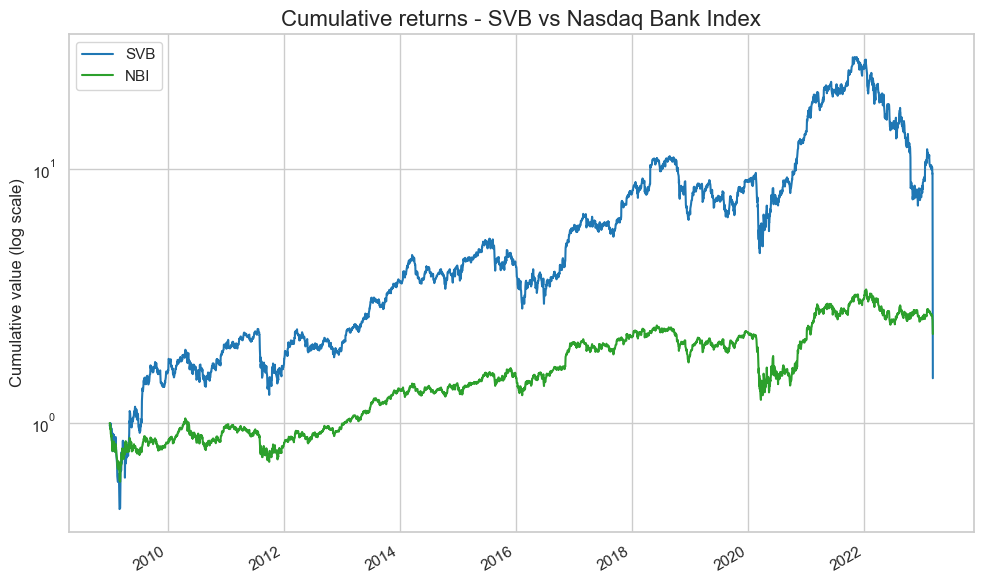

In [230]:
# Plot cumulative returns only for SVB vs NBI
cum_1 = (1 + rets[['SVB','NBI']]).cumprod()
fig, ax1 = plt.subplots(figsize=(10,6), dpi=100)
cum_1.plot(ax=ax1, color=[color_map[c] for c in cum_1.columns])
ax1.set_yscale('log')
ax1.set_ylabel('Cumulative value (log scale)', fontsize=12)
# add_covid_shade(ax1)
ax1.set_title('Cumulative returns - SVB vs Nasdaq Bank Index', fontsize=16)
ax1.legend(loc='upper left')

ax1.grid(True)

plt.tight_layout()
plt.show()

#### Figure 2: Cumulative Returns - SVB vs QQQ

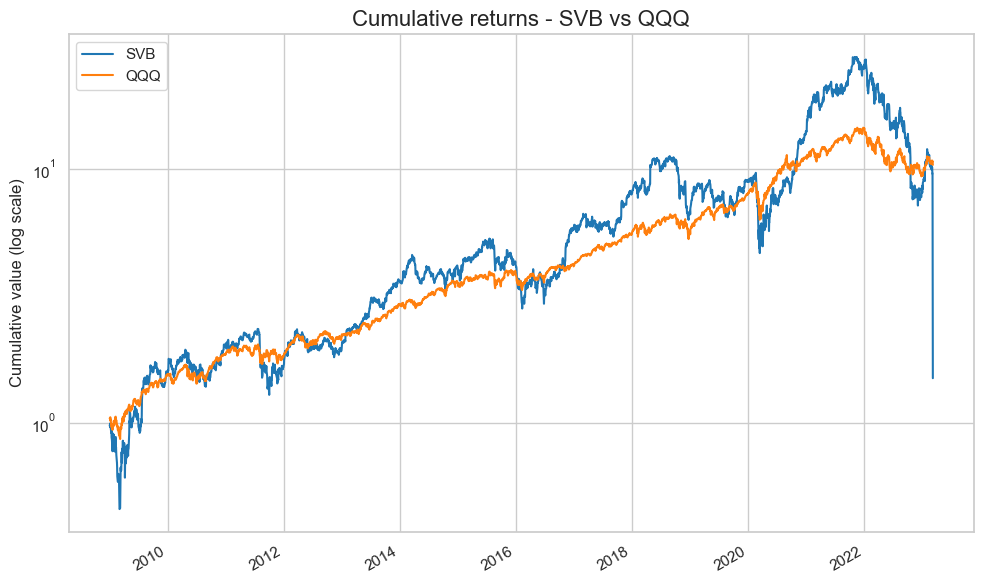

In [231]:
# Plot cumulative returns only for SVB vs QQQ
cum_2 = (1 + rets[['SVB','QQQ']]).cumprod()
fig, ax1 = plt.subplots(figsize=(10,6), dpi=100)
cum_2.plot(ax=ax1, color=[color_map[c] for c in cum_2.columns])
ax1.set_yscale('log')
ax1.set_ylabel('Cumulative value (log scale)', fontsize=12)
# add_covid_shade(ax1)
ax1.set_title('Cumulative returns - SVB vs QQQ', fontsize=16)
ax1.legend(loc='upper left')

ax1.grid(True)

plt.tight_layout()
plt.show()

#### Figure 3: Correlations Ranking - SVB vs NBI Components

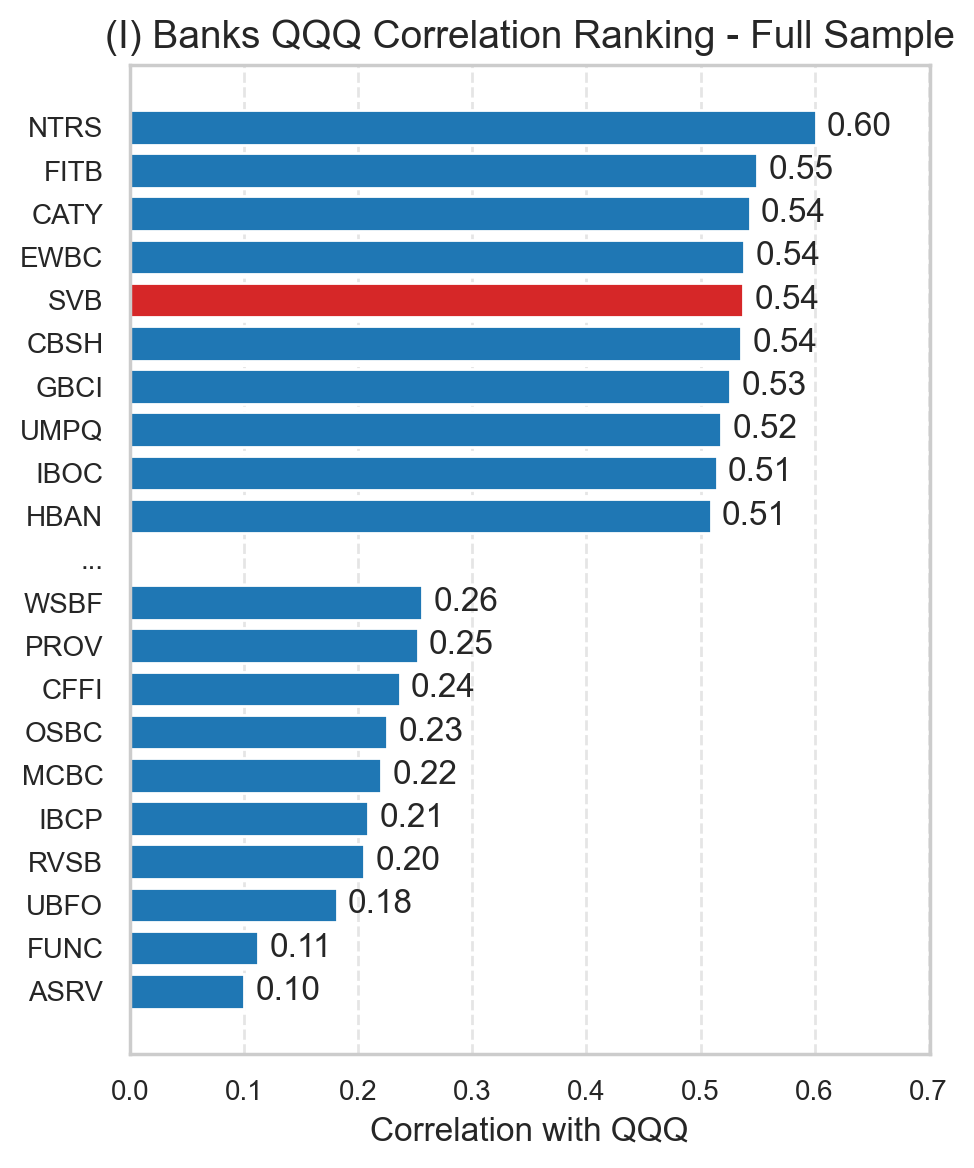

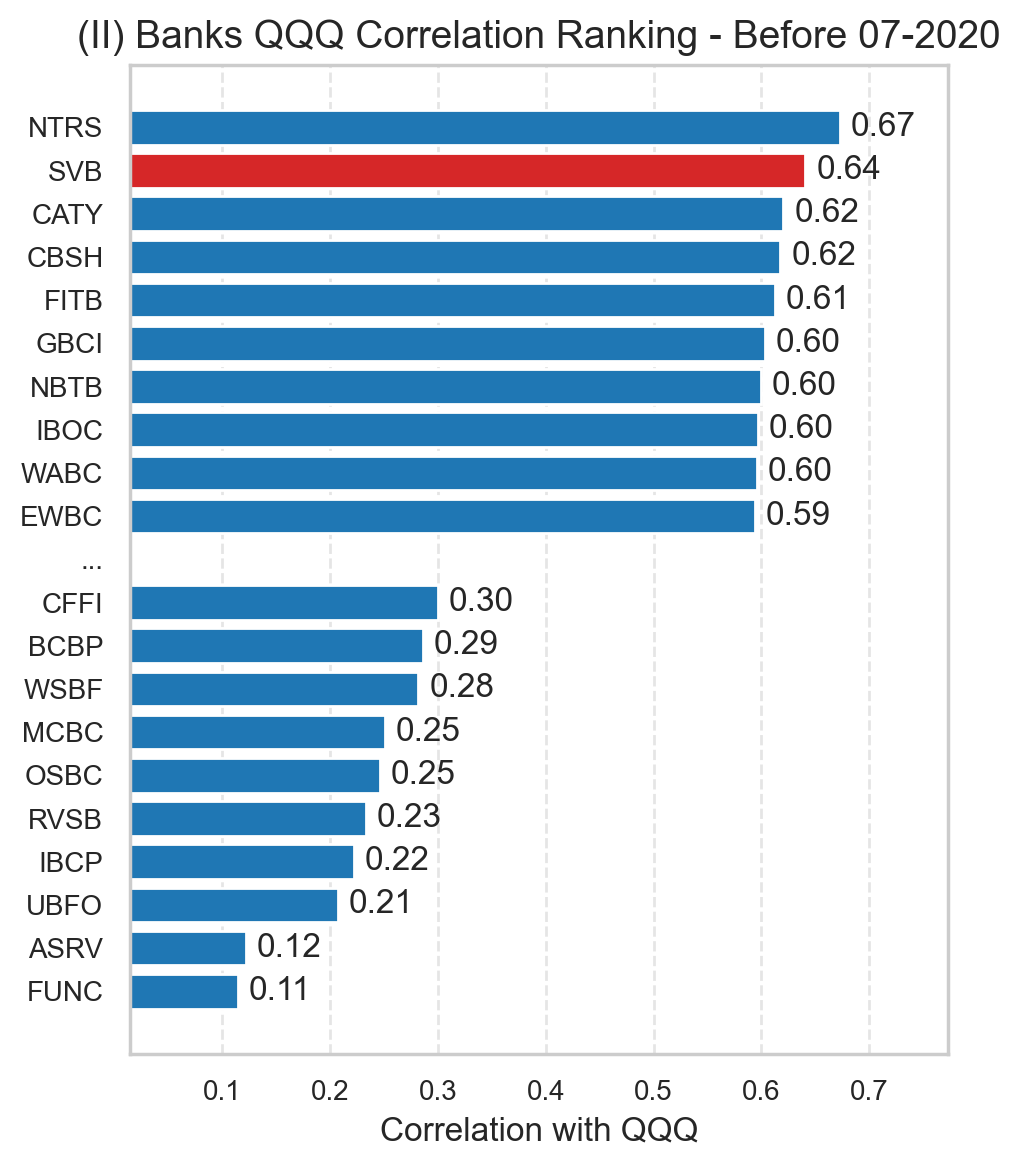

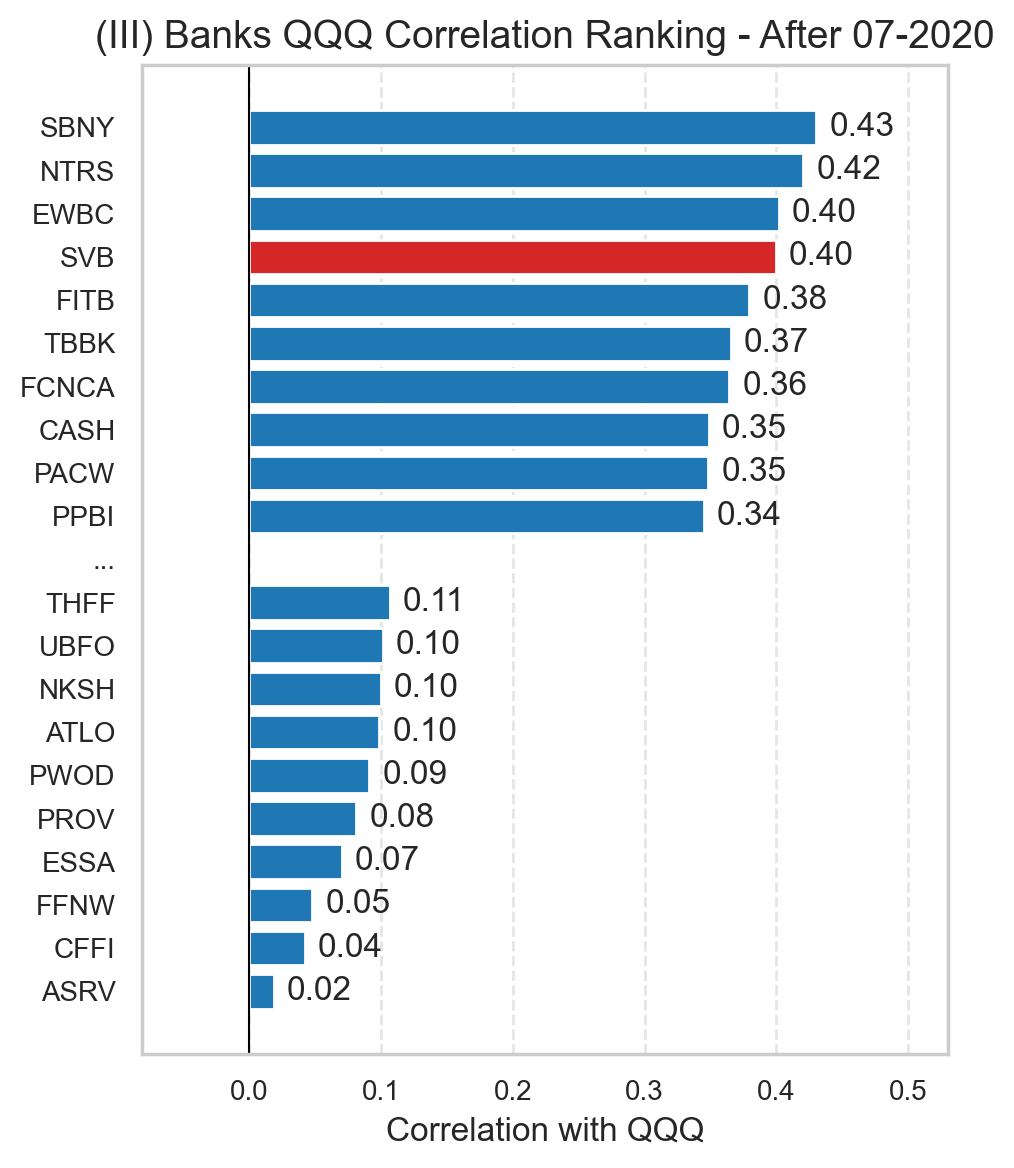

In [232]:
corr_df = rets[['QQQ', 'SVB']].copy()
qqq_orth = add_residualized(rets, "QQQ", "SPY")
corr_df['QQQ_on_SPY'] = qqq_orth['QQQ_on_SPY']
# add in correspondence to dates all other bank returns
corr_df = corr_df.join(other_banks_filtered, how='left')
corr_df = corr_df.dropna(how='all', subset=other_banks_filtered.columns)  # drop rows where all other banks are NaN
corr_matrix = corr_df.corr()

# --- subsets ---
pre_df = corr_df.loc[corr_df.index < BREAK_1]
post_df = corr_df.loc[corr_df.index >= BREAK_1]

# --- correlations ---
corr_all = corr_ranking(corr_df).dropna()
corr_pre = corr_ranking(pre_df).dropna()
corr_post = corr_ranking(post_df).dropna()

# drop corr with QQQ_on_SPY from these
corr_all = corr_all[corr_all.index != 'QQQ_on_SPY']
corr_pre = corr_pre[corr_pre.index != 'QQQ_on_SPY']
corr_post = corr_post[corr_post.index != 'QQQ_on_SPY']

# --- correlations QQQ orth ---
corr_orth_all = corr_ranking(corr_df, ref_col='QQQ_on_SPY').dropna()
corr_orth_pre = corr_ranking(pre_df, ref_col='QQQ_on_SPY').dropna()
corr_orth_post = corr_ranking(post_df, ref_col='QQQ_on_SPY').dropna()

# drop corr with QQQ from these
corr_orth_all = corr_orth_all[corr_orth_all.index != 'QQQ']
corr_orth_pre = corr_orth_pre[corr_orth_pre.index != 'QQQ']
corr_orth_post = corr_orth_post[corr_orth_post.index != 'QQQ']

# --- plots ---
plot_corr_rank(corr_all, highlight='SVB', title='(I) Banks QQQ Correlation Ranking - Full Sample', top_n=10, bottom_n=10)
plt.show()

plot_corr_rank(corr_pre, highlight='SVB', title='(II) Banks QQQ Correlation Ranking - Before 07-2020', top_n=10, bottom_n=10)
plt.show()

plot_corr_rank(corr_post, highlight='SVB', title='(III) Banks QQQ Correlation Ranking - After 07-2020', top_n=10, bottom_n=10)
plt.show()

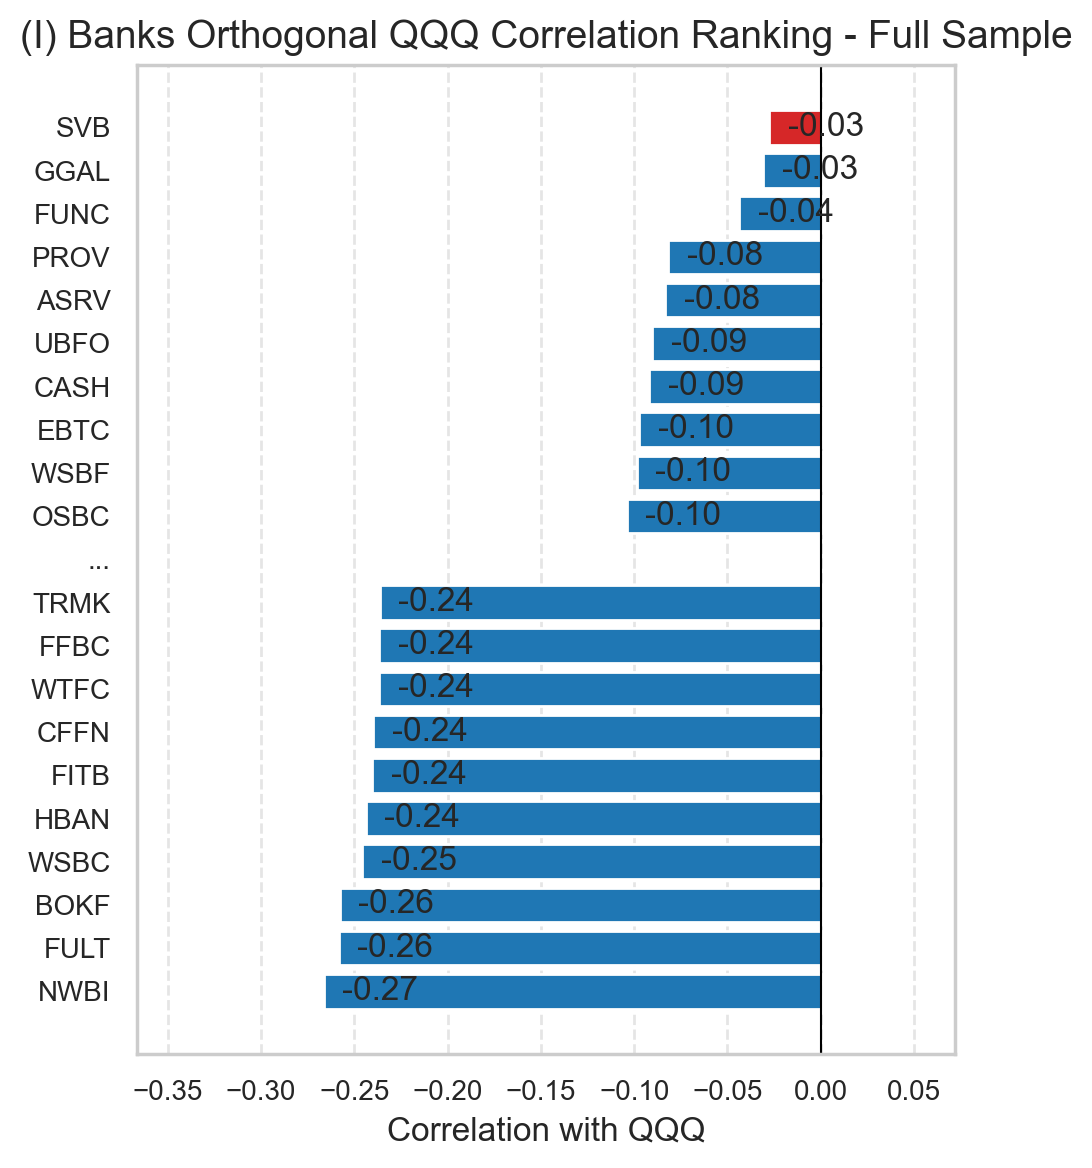

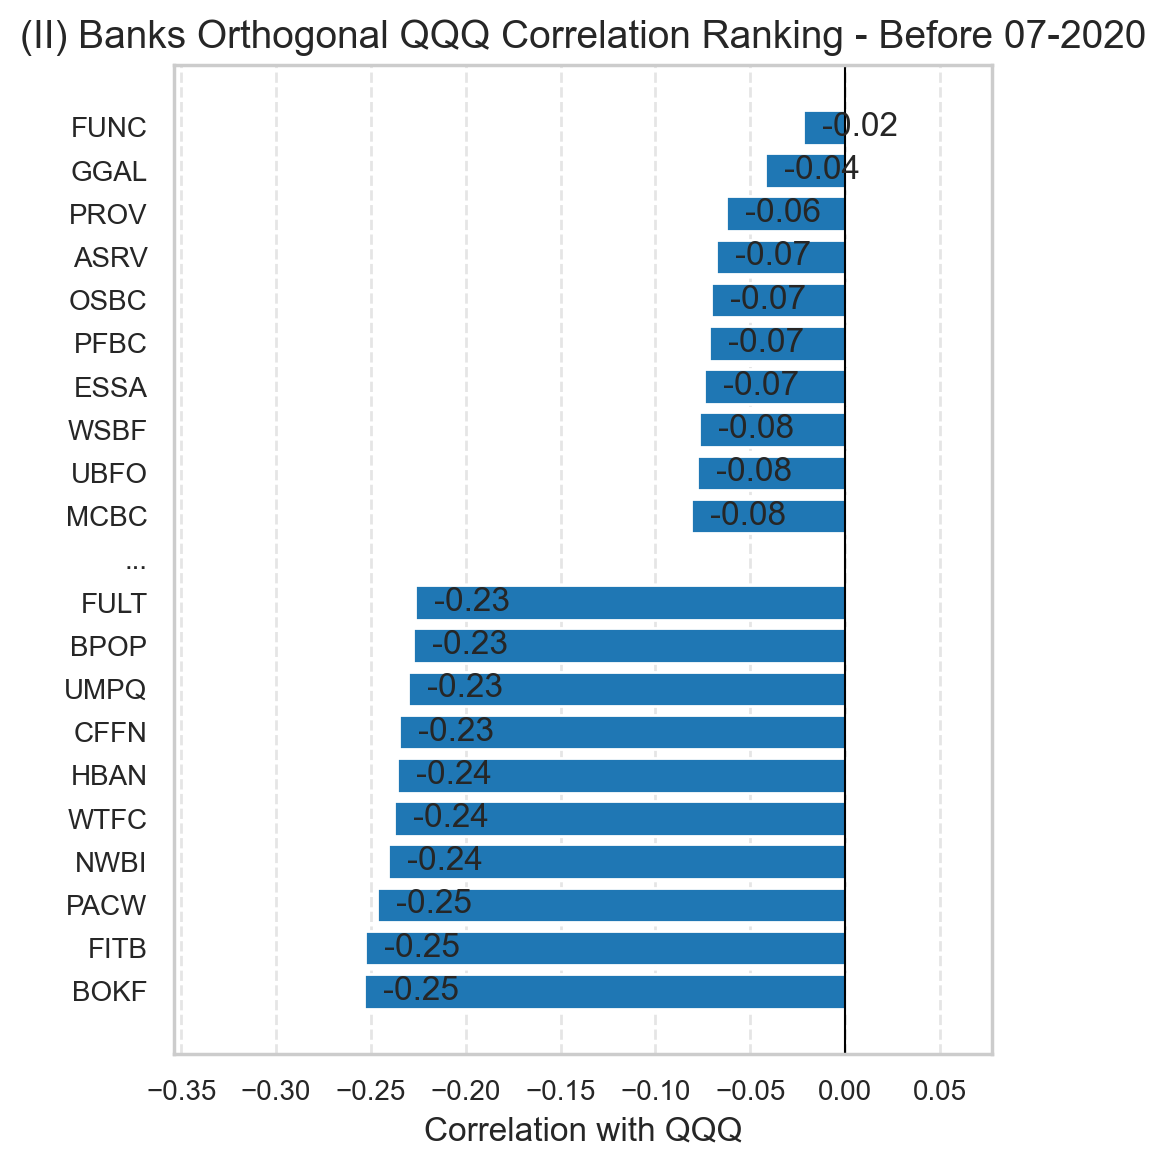

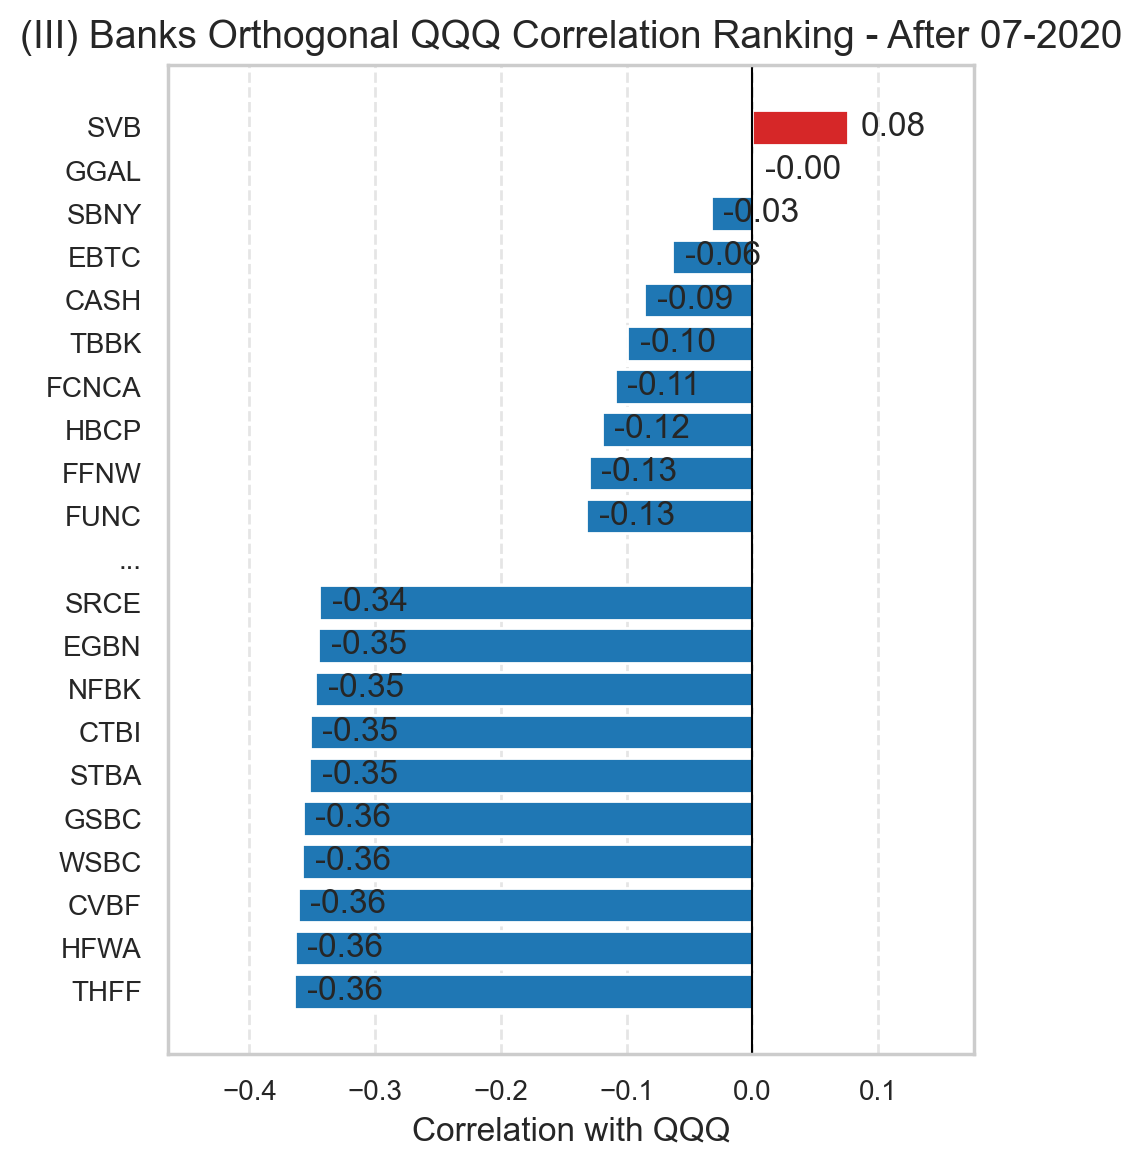

In [233]:
# --- plots ---
plot_corr_rank(corr_orth_all, highlight='SVB', title='(I) Banks Orthogonal QQQ Correlation Ranking - Full Sample', top_n=10, bottom_n=10, text_side='right')
plt.show()

plot_corr_rank(corr_orth_pre, highlight='SVB', title='(II) Banks Orthogonal QQQ Correlation Ranking - Before 07-2020', top_n=10, bottom_n=10, text_side='right')
plt.show()

plot_corr_rank(corr_orth_post, highlight='SVB', title='(III) Banks Orthogonal QQQ Correlation Ranking - After 07-2020', top_n=10, bottom_n=10, text_side='right')
plt.show()

In [234]:
# ---------------------------------------------
# Mapping tickers to bank names from COMNAM
# ---------------------------------------------
name_map = (
    other_banks
    .dropna(subset=["TICKER", "COMNAM"])
    .drop_duplicates("TICKER")
    .set_index("TICKER")["COMNAM"]
    .to_dict()
)

# ---------------------------------------------
# Helper: build top-N correlation table
# ---------------------------------------------
def make_top_corr_table(corr_series, name_map, top_n=15, drop_list=None):
    """
    corr_series: pd.Series with index = tickers (or column names) and values = correlations
    name_map: dict {ticker: bank name from COMNAM}
    drop_list: optional list of tickers/labels to exclude, e.g. ["SVB", "QQQ"]
    """
    s = corr_series.copy()

    if drop_list is not None:
        s = s[~s.index.isin(drop_list)]

    # top N correlations
    top = s.sort_values(ascending=False).head(top_n)

    # build output frame with explicit column names
    out = top.reset_index()
    out.columns = ["Ticker", "Correlation"]

    # map tickers to company names
    # map names, fix capitalization, and add custom SVB label
    out["Name"] = (
        out["Ticker"]
        .map(name_map)
        .fillna(out["Ticker"])
        .replace({"SVB": "Silicon Valley Bank"})
        .str.title()  # Capitalizes correctly (e.g., "Bank Of America")
    )


    # reorder columns
    out = out[["Name", "Ticker", "Correlation"]]

    return out

# ---------------------------------------------
# Examples: top 15 tables
# ---------------------------------------------

# Full sample, raw QQQ correlations (you already have corr_all)
top15_corr_all = make_top_corr_table(
    corr_all,
    name_map,
    top_n=15,
    drop_list=None        # or e.g. ["SVB", "QQQ"] if you want to exclude them
)

# Before break
top15_corr_pre = make_top_corr_table(
    corr_pre,
    name_map,
    top_n=15,
    drop_list=None
)

# After break
top15_corr_post = make_top_corr_table(
    corr_post,
    name_map,
    top_n=15,
    drop_list=None
)

# If you also want for the orthogonalized QQQ_on_SPY:
top15_corr_orth_all = make_top_corr_table(
    corr_orth_all,
    name_map,
    top_n=15,
    drop_list=None
)

# Print nicely
print("Top 15 correlations, full sample:")
display(top15_corr_all)

print("\nTop 15 correlations, pre-break:")
display(top15_corr_pre)

print("\nTop 15 correlations, post-break:")
display(top15_corr_post)

Top 15 correlations, full sample:


,Name,Ticker,Correlation
0,Northern Trust Corp,NTRS,0.600811
1,Fifth Third Bancorp,FITB,0.549351
2,Cathay General Bancorp,CATY,0.542998
3,East West Bancorp Inc,EWBC,0.538326
4,Silicon Valley Bank,SVB,0.537134
5,Commerce Bancshares Inc,CBSH,0.535889
6,Glacier Bancorp Inc New,GBCI,0.526027
7,Umpqua Holdings Corp,UMPQ,0.518103
8,International Bancshares Corp,IBOC,0.514174
9,Huntington Bancshares Inc,HBAN,0.508748



Top 15 correlations, pre-break:


,Name,Ticker,Correlation
0,Northern Trust Corp,NTRS,0.673161
1,Silicon Valley Bank,SVB,0.640924
2,Cathay General Bancorp,CATY,0.620532
3,Commerce Bancshares Inc,CBSH,0.617710
4,Fifth Third Bancorp,FITB,0.612920
5,Glacier Bancorp Inc New,GBCI,0.603414
6,N B T Bancorp Inc,NBTB,0.599291
7,International Bancshares Corp,IBOC,0.597047
8,Westamerica Bancorporation,WABC,0.595530
9,East West Bancorp Inc,EWBC,0.594229



Top 15 correlations, post-break:


,Name,Ticker,Correlation
0,Signature Bank New York N Y,SBNY,0.430178
1,Northern Trust Corp,NTRS,0.420394
2,East West Bancorp Inc,EWBC,0.401820
3,Silicon Valley Bank,SVB,0.399565
4,Fifth Third Bancorp,FITB,0.379344
5,Bancorp Inc,TBBK,0.365403
6,First Citizens Bancshares Inc Nc,FCNCA,0.364392
7,Meta Financial Group Inc,CASH,0.348601
8,Pacwest Bancorp De,PACW,0.348237
9,Pacific Premier Bancorp Inc,PPBI,0.344929


In [235]:
# Before break
top15_corr_orth_pre = make_top_corr_table(
    corr_orth_pre,
    name_map,
    top_n=15,
    drop_list=None
)

# After break
top15_corr_orth_post = make_top_corr_table(
    corr_orth_post,
    name_map,
    top_n=15,
    drop_list=None
)


print("\nTop 15 correlations, pre-break:")
display(top15_corr_orth_pre)

print("\nTop 15 correlations, post-break:")
display(top15_corr_orth_post)


Top 15 correlations, pre-break:


,Name,Ticker,Correlation
0,First United Corp,FUNC,-0.022317
1,Grupo Financiero Galicia S A,GGAL,-0.042179
2,Provident Financial Holdings Inc,PROV,-0.062733
3,Ameriserv Financial Inc,ASRV,-0.068067
4,Old Second Bancorp Inc,OSBC,-0.070761
5,Preferred Bank Los Angeles,PFBC,-0.071663
6,E S S A Bancorp Inc,ESSA,-0.074514
7,Waterstone Financial Inc,WSBF,-0.076966
8,United Security Bankshares,UBFO,-0.078278
9,Macatawa Bank Corp,MCBC,-0.081138



Top 15 correlations, post-break:


,Name,Ticker,Correlation
0,Silicon Valley Bank,SVB,0.076413
1,Grupo Financiero Galicia S A,GGAL,-0.000230
2,Signature Bank New York N Y,SBNY,-0.033021
3,Enterprise Bancorp Inc,EBTC,-0.063542
4,Meta Financial Group Inc,CASH,-0.085865
5,Bancorp Inc,TBBK,-0.099652
6,First Citizens Bancshares Inc Nc,FCNCA,-0.109410
7,Home Bancorp Inc,HBCP,-0.119708
8,First Financial Northwest Inc,FFNW,-0.130171
9,First United Corp,FUNC,-0.132269


#### (Appendix) Figure A.1: 120-day Rolling Correlations vs SVB

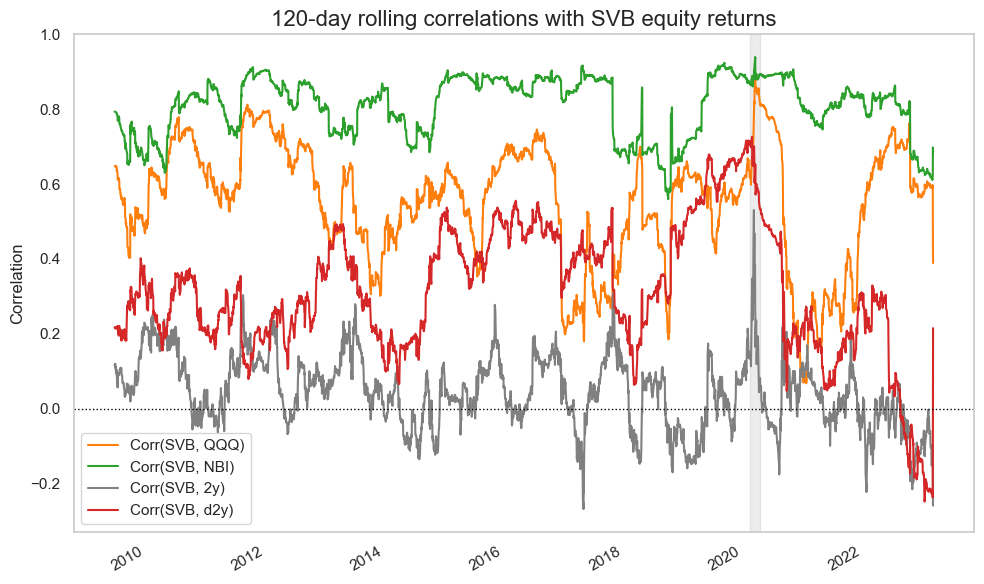

In [236]:
# -----------------------------
# Rolling correlations
# -----------------------------
roll = 120
rc = pd.concat({
    'Corr(SVB, QQQ)': rets['SVB'].rolling(roll).corr(rets['QQQ']),
    'Corr(SVB, NBI)': rets['SVB'].rolling(roll).corr(rets['NBI']),
    'Corr(SVB, 2y)':  rets['SVB'].rolling(roll).corr(rets['MKT_LVL']),
    'Corr(SVB, d2y)': rets['SVB'].rolling(roll).corr(rets['dMKT_bps']),
}, axis=1).dropna()

fig, ax = plt.subplots(figsize=(10,6), dpi=100)
for c in rc.columns:
    rc[c].plot(ax=ax, label=c, color=color_map[c])
add_covid_shade(ax)
ax.axhline(0, color='black', linestyle=':', linewidth=1)
ax.set_ylabel('Correlation', fontsize=12)
ax.set_title(f'{roll}-day rolling correlations with SVB equity returns', fontsize=16)
ax.legend()
ax.grid(False)
plt.tight_layout()
plt.show()


#### (Appendix) Figure A.2: 120-day Rolling Correlations vs QQQ

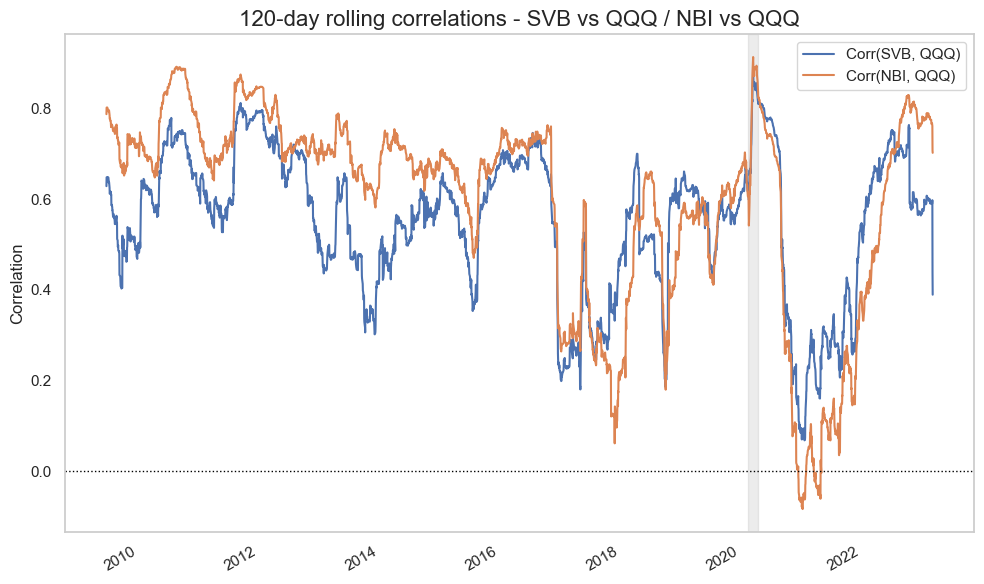

In [237]:
# Lets run and plot the same running correlations, but showing: (i) SVB vs QQQ, (ii) NBI vs QQQ, (iii) SVB vs SPY, (iv) NBI vs SPY
rc2 = pd.concat({
    'Corr(SVB, QQQ)': rets['SVB'].rolling(roll).corr(rets['QQQ']),
    'Corr(NBI, QQQ)': rets['NBI'].rolling(roll).corr(rets['QQQ']),
    # 'Corr(SVB, SPY)': rets['SVB'].rolling(roll).corr(rets['SPY']),
    # 'Corr(NBI, SPY)': rets['NBI'].rolling(roll).corr(rets['SPY']),
}, axis=1).dropna()
fig, ax = plt.subplots(figsize=(10,6), dpi=100)
rc2.plot(ax=ax)
add_covid_shade(ax)
ax.axhline(0, color='black', linestyle=':', linewidth=1)
ax.set_ylabel('Correlation', fontsize=12)
ax.set_title(f'{roll}-day rolling correlations - SVB vs QQQ / NBI vs QQQ', fontsize=16)
ax.grid(False)
plt.tight_layout()
plt.show()


### 1.3 Regression Analysis

In [238]:
# -----------------------------
# Samples (full, excl COVID, winsorized)
# -----------------------------
def build_samples(df):
    samples = {}
    samples['full'] = df.dropna().copy()
    mask_nc = ~((df.index >= COVID_START) & (df.index <= COVID_END))
    samples['excl_covid'] = df.loc[mask_nc].dropna().copy()
    w = df.copy()
    for c in w.columns:
        w[c] = winsorize_series(w[c], 0.01)
    samples['winsorized'] = w.dropna().copy()
    return samples

base_cols = ['SVB','QQQ','NBI','KBW','DFF_LVL','dDFF_bps','MKT_LVL','dMKT_bps','SPY']
SAMPLES = build_samples(rets[base_cols])

# -----------------------------
# Regression specs (7)
# -----------------------------
SPEC_LIST = [
    ("i_base",        "SVB", ["QQQ","NBI"]),

    ("ii_dff_lvl",    "SVB", ["QQQ","NBI","DFF_LVL"]),
    ("iii_dff_chg",   "SVB", ["QQQ","NBI","dDFF_bps"]),
    ("iv_dff_both",   "SVB", ["QQQ","NBI","DFF_LVL","dDFF_bps"]),
    
    ("v_mkt_lvl",     "SVB", ["QQQ","NBI","MKT_LVL"]),
    ("vi_mkt_chg",    "SVB", ["QQQ","NBI","dMKT_bps"]),
    ("vii_mkt_both",  "SVB", ["QQQ","NBI","MKT_LVL","dMKT_bps"]),
    
    ("viii_mkt_only", "SVB", ["MKT_LVL","dMKT_bps"]),

    ("ix_nbi_on_qqq", "NBI", ["QQQ"]),
    ("x_svb_on_qqq", "SVB", ["QQQ"]),
    
    ("xi_nbi_on_qqq", "NBI", ["QQQ_on_SPY"]),
    ("xii_svb_on_qqq", "SVB", ["QQQ_on_SPY"]),

    ("xiii_base_orth", "SVB", ["QQQ_on_SPY","NBI"]),
    ("xiv_mkt_chg_orth", "SVB", ["QQQ_on_SPY","NBI","dMKT_bps"]),

    ("xv_nbi_spy_qqq", "NBI", ["SPY","QQQ_on_SPY"]),
    ("xvi_svb_spy_qqq", "SVB", ["SPY","QQQ_on_SPY"]),

]


spec_labels = {
    "i_base":      "(i) Spec: SVB ~ QQQ + NBI",
    "ii_dff_lvl":  "(ii) Spec: SVB ~ QQQ + NBI + DFF (level)",
    "iii_dff_chg": "(iii) Spec: SVB ~ QQQ + NBI + Î”DFF",
    "iv_dff_both": "(iv) Spec: SVB ~ QQQ + NBI + DFF (level) + Î”DFF",
    "v_mkt_lvl":   "(v) Spec: SVB ~ QQQ + NBI + Market Rate (level)",
    "vi_mkt_chg":  "(vi) Spec: SVB ~ QQQ + NBI + Î”Market Rate",
    "vii_mkt_both":"(vii) Spec: SVB ~ QQQ + NBI + Market Rate (level) + Î”Market Rate",
    "viii_mkt_only":"(viii) Spec: SVB ~ Market Rate (level) + Î”Market Rate",
    "ix_nbi_on_qqq": "(ix) Spec: NBI ~ QQQ",
    "x_svb_on_qqq": "(x) Spec: SVB ~ QQQ",
    "xi_nbi_on_qqq": "(xi) Spec: NBI ~ QQQ âŸ‚ SPY",
    "xii_svb_on_qqq": "(xii) Spec: SVB ~ QQQ âŸ‚ SPY",
    "xiii_base_orth": "(xiii) Spec: SVB ~ QQQ + NBI âŸ‚ QQQ",
    "xiv_mkt_chg_orth": "(xiv) Spec: SVB ~ QQQ + NBI + Î”Market Rate",
    "xv_nbi_spy_qqq": "(xv) Spec: NBI ~ SPY + QQQ âŸ‚ SPY",
    "xvi_svb_spy_qqq": "(xvi) Spec: SVB ~ SPY + QQQ âŸ‚ SPY",
}

spec_short = {
    "i_base": "i",
    "ii_dff_lvl": "ii",
    "iii_dff_chg": "iii",
    "iv_dff_both": "iv",
    "v_mkt_lvl": "v",
    "vi_mkt_chg": "vi",
    "vii_mkt_both": "vii",
    "viii_mkt_only": "viii",
    "ix_nbi_on_qqq": "ix",
    "x_svb_on_qqq": "x",
    "xi_nbi_on_qqq": "xi",
    "xii_svb_on_qqq": "xii",
    "xiii_base_orth": "xiii",
    "xiv_mkt_chg_orth": "xiv",
    "xv_nbi_spy_qqq": "xv",
    "xvi_svb_spy_qqq": "xvi",
}

var_order = [
    "const","QQQ","NBI","DFF_LVL","dDFF_bps","MKT_LVL","dMKT_bps","SPY",
    "QQQ_on_SPY","NBI_on_QQQ","QQQ_on_NBI","NBI_on_SPY"
]

var_labels = {
    "const": "Intercept",
    "QQQ": "QQQ",
    "NBI": "NBI",
    "DFF_LVL": "DFF (level)",
    "dDFF_bps": "Î”DFF",
    "MKT_LVL": "Market Rate (level)",
    "dMKT_bps": "Î”Market Rate",
    "SPY": "S&P 500",
    "QQQ_on_SPY": "QQQ âŸ‚ SPY",
    "NBI_on_QQQ": "NBI âŸ‚ QQQ",
    "QQQ_on_NBI": "QQQ âŸ‚ NBI",
    "NBI_on_SPY": "NBI âŸ‚ SPY",
}

In [239]:
# -----------------------------
# Master computation
# -----------------------------
results = {}  # results[sample][residualized?]['baseline'/'two_state'/'three_state'][spec_key] = dict

for sample_name, df_s in SAMPLES.items():
    results[sample_name] = {}

    for resid_flag in [False]:
        key_resid = 'resid' if resid_flag else 'raw'
        results[sample_name][key_resid] = {"baseline": {}, "two_state": {}, "three_state": {}}

        # build residualized factors if requested (within the current sample)
        if resid_flag:
            dfX = df_s.copy()
            dfX['QQQ_net'] = sm.OLS(dfX['QQQ'], sm.add_constant(dfX['NBI'], has_constant='add')).fit().resid
            dfX['NBI_net'] = sm.OLS(dfX['NBI'], sm.add_constant(dfX['QQQ'], has_constant='add')).fit().resid
        else:
            dfX = df_s

        for spec_name, dep, rhs in SPEC_LIST:
            dfX, rhs_eff = prepare_rhs(df_s, rhs)

            results[sample_name][key_resid]["baseline"][spec_name] = run_baseline(dfX, rhs_eff, dep=dep)
            results[sample_name][key_resid]["two_state"][spec_name] = run_regime(dfX, rhs_eff, dep=dep, two_state=True)
            results[sample_name][key_resid]["three_state"][spec_name] = run_regime(dfX, rhs_eff, dep=dep, two_state=False)




#### 1.3.3 Results

In [240]:
# print_report for all regressions, two-state, windsorized only
# print_report(results, selected_samples=["winsorized"], selected_sections=["two_state"])

# print_report(results, selected_samples=["winsorized"], selected_sections=["baseline"], selected_specs=["ix"])
print_report(results, selected_samples=["winsorized"], selected_sections=["three_state"], selected_specs=["i"])
# print_report(results, selected_samples=["winsorized"], selected_sections=["three_state"], selected_specs=["x"])
# print_report(results, selected_samples=["winsorized"], selected_sections=["two_state"], selected_specs=["xvi"])
# print_report(results, selected_samples=["winsorized"], selected_sections=["two_state"], selected_specs=["xiv"])


SAMPLE: WINSORIZED | FACTORS: Raw

--- THREE_STATE ---


regime,Pre-2020-07-01,2020-07-01 to 2022-10-15,Post-2022-10-15
var,,,
Intercept,0.0004 (1.6889)*,0.0003 (0.5278),-0.0011 (-0.4757)
QQQ,0.2475 (6.5208)***,0.4806 (9.9056)***,0.8922 (4.0829)***
NBI,1.1968 (38.4157)***,1.1111 (26.9137)***,1.1111 (6.2687)***



Fit stats by regime:


,Obs,Adj_R2
Regime,,
Pre-2020-07-01,2871,0.7070
2020-07-01 to 2022-10-15,573,0.7130
Post-2022-10-15,99,0.6230



Overall Wald tests:


var,chi2,df,p,stars
const,0.4538,2,0.7970,
QQQ,21.1517,2,0.0000,***
NBI,2.8376,2,0.2420,



Pairwise Wald tests:


var,reg1,reg2,chi2,p,stars
const,Pre-2020-07-01,2020-07-01 to 2022-10-15,0.0378,0.8458,
const,Pre-2020-07-01,Post-2022-10-15,0.4324,0.5108,
const,2020-07-01 to 2022-10-15,Post-2022-10-15,0.3535,0.5522,
QQQ,Pre-2020-07-01,2020-07-01 to 2022-10-15,14.3222,0.0002,***
QQQ,Pre-2020-07-01,Post-2022-10-15,8.4501,0.0037,***
QQQ,2020-07-01 to 2022-10-15,Post-2022-10-15,3.3347,0.0678,*
NBI,Pre-2020-07-01,2020-07-01 to 2022-10-15,2.7412,0.0978,*
NBI,Pre-2020-07-01,Post-2022-10-15,0.2268,0.6339,
NBI,2020-07-01 to 2022-10-15,Post-2022-10-15,0.0000,0.9999,


feature,VIF
QQQ,1.5580
NBI,1.5580


#### 1.3.4 Sample Robustness Check (post-2016)

In [241]:
# =============================
# Post-2016 rerun, rate specs only
# =============================

# 1) Build post-2016 samples from your existing SAMPLES
SAMPLES_POST2016 = {
    f"{name}_post2016": s.loc[s.index >= "2016-01-01"].copy()
    for name, s in SAMPLES.items()
}

# 2) Define which variables count as "rates"
RATE_VARS = {"DFF_LVL", "dDFF_bps", "MKT_LVL", "dMKT_bps"}

# 3) Keep only the specs that include at least one rate var
SPEC_LIST_RATE = [
    (spec_name, dep, rhs)
    for (spec_name, dep, rhs) in SPEC_LIST
    if any(v in RATE_VARS for v in rhs)
]

# 4) Re-run your full pipeline on the post-2016 samples, but only for those rate specs
results_post2016 = {}  # same structure as 'results'

for sample_name, df_s in SAMPLES_POST2016.items():
    results_post2016[sample_name] = {}

    for resid_flag in [False]:  # mirror your current run
        key_resid = 'resid' if resid_flag else 'raw'
        results_post2016[sample_name][key_resid] = {
            "baseline": {},
            "two_state": {},
            "three_state": {},
        }

        # build residualized factors if requested
        if resid_flag:
            dfX = df_s.copy()
            dfX['QQQ_net'] = sm.OLS(dfX['QQQ'], sm.add_constant(dfX['NBI'], has_constant='add')).fit().resid
            dfX['NBI_net'] = sm.OLS(dfX['NBI'], sm.add_constant(dfX['QQQ'], has_constant='add')).fit().resid
        else:
            dfX = df_s

        for spec_name, dep, rhs in SPEC_LIST_RATE:
            # expand RHS the same way you do (handles *_on_* residualization)
            dfX_expanded, rhs_eff = prepare_rhs(dfX, rhs)

            # baseline, two_state, three_state just like your master loop
            results_post2016[sample_name][key_resid]["baseline"][spec_name] = run_baseline(dfX_expanded, rhs_eff, dep=dep)
            results_post2016[sample_name][key_resid]["two_state"][spec_name] = run_regime(dfX_expanded, rhs_eff, dep=dep, two_state=True)
            results_post2016[sample_name][key_resid]["three_state"][spec_name] = run_regime(dfX_expanded, rhs_eff, dep=dep, two_state=False)

# 5) Print in the exact same format
# print_report(results_post2016, selected_samples=["winsorized_post2016"], selected_sections=["two_state"])

In [242]:
# ============================================
# Comparison helper: full vs post-2016
# ============================================

def compare_results(results_full, results_cut, sample="winsorized", section="two_state", threshold=0.3):
    """
    Compare coefficient estimates and significance between full and post-2016 samples.
    
    threshold = fractional change in coefficient magnitude (e.g. 0.3 = 30%) to trigger flag.
    """

    full_dict = results_full[sample]["raw"][section]
    cut_dict  = results_cut[sample + "_post2016"]["raw"][section]

    for spec_key in cut_dict.keys():
        print(f"\n=== Spec {spec_key} ({spec_labels.get(spec_key,spec_key)}) ===")

        fbet = full_dict[spec_key]["full_betas"].set_index(["var","regime"])
        cbet = cut_dict[spec_key]["full_betas"].set_index(["var","regime"])

        merged = fbet[["coef","t"]].join(
            cbet[["coef","t"]],
            lsuffix="_full", rsuffix="_post2016"
        )

        # significance stars
        merged["stars_full"]     = merged["t_full"].apply(lambda t: sigstars(t, kind="t"))
        merged["stars_post2016"] = merged["t_post2016"].apply(lambda t: sigstars(t, kind="t"))

        # percent change in coefficient magnitude
        merged["pct_change_coef"] = (
            (merged["coef_post2016"] - merged["coef_full"]).abs()
            / merged["coef_full"].replace(0,np.nan)
        )

        # flag if significance changes or coef moves a lot
        def make_flag(row):
            flags = []
            if row["stars_full"] != row["stars_post2016"]:
                flags.append("sig shift")
            if pd.notnull(row["pct_change_coef"]) and row["pct_change_coef"] > threshold:
                flags.append(f"coef shift {row['pct_change_coef']:.1%}")
            return "; ".join(flags) if flags else ""
        
        merged["Flag"] = merged.apply(make_flag, axis=1)

        display(merged.reset_index())

# Example use:
# compare_results(results, results_post2016, sample="winsorized", section="two_state", threshold=0.3)

#### 1.3.5 Appendix - Orthogonalized Factors

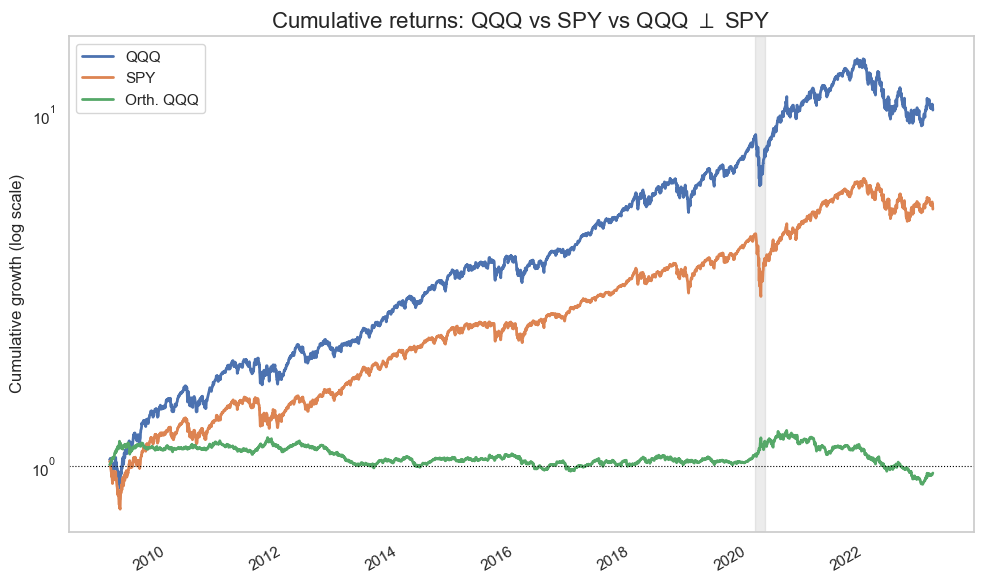

In [243]:
# -----------------------------
# Orthogonalized factors: cumulative returns
# -----------------------------
rets = add_residualized(rets, "QQQ", "SPY")
rets = add_residualized(rets, "QQQ", "NBI")
# rets = add_residualized(rets, "NBI", "QQQ")
# rets = add_residualized(rets, "NBI", "SPY")

cols = ["QQQ", "SPY", "QQQ_on_SPY"]
cum = (1 + rets[cols]).cumprod()

cum = cum.rename(columns={
    "QQQ_on_SPY": "Orth. QQQ",
})

fig, ax = plt.subplots(figsize=(10,6), dpi=100)
cum.plot(ax=ax, linewidth=2)
ax.set_yscale('log')
add_covid_shade(ax)

ax.axhline(1, color='black', linestyle=':', linewidth=.8)  # zero-growth line (1 on log scale)

ax.set_ylabel("Cumulative growth (log scale)", fontsize=12)
ax.set_title(r"Cumulative returns: QQQ vs SPY vs QQQ $\perp$ SPY", fontsize=16)
ax.legend(loc='best')
ax.grid(False)

plt.tight_layout()
plt.show()


### 1.4 AFS vs HTM Analysis

#### 1.4.1 Data and Setup

In [ ]:
# -------------------------------------------------------------------
# Variables:
# - AV_SA_FA_AT_FV_THRU_OT_COMP_INC: AFS securities at fair value (OCI bucket)
# - HTM_AMORTIZED_AT_CST_INVESTMENTS: HTM securities at amortized cost (book value)
# - BS_OTHER_INVESTMENTS: Other investment securities (not core AFS/HTM)
# - BS_TOT_ASSET: Total assets
# - BS_DEMAND_DPST: Demand deposits
# - INTEREST_BEARING_DEPOSITS_RATIO: Ratio of deposits that bear interest
# - BS_SVNG_DPST: Savings deposits
# - BS_TIME_DPST: Time deposits (CDs, term)
# - BS_OTHER_DPST: Other deposits
# - BS_CUSTOMER_DEPOSITS: Total customer deposits
# - FDIC_SECS_HELD_TO_MTY_BOOK_VAL: HTM securities, book value (regulatory report)
# - FDIC_SECS_AVAIL_FOR_SALE_MKT_VAL: AFS securities, fair value (regulatory report)
# - FDIC_FED_FUNDS_&_REPOS: Fed funds & repos
# - FED_TOTAL_SECURITIES_HTM_FV: HTM securities at fair value (Fed data)
# - FED_TOTAL_SECURITIES_AFS_COST: AFS securities at book (cost, Fed data)
# -------------------------------------------------------------------

# SVB Data
bs_data = pd.read_excel(r"data/Input/SVB/SVB_BS_Data.xlsx", skiprows=[0,1])

bs_data['Dates'] = pd.to_datetime(bs_data['Dates'])
bs_data = bs_data.set_index('Dates').sort_index()

bs_data = bs_data[[
    'BS_OTHER_INVESTMENTS',
    'BS_TOT_ASSET',
    'BS_DEMAND_DPST',
    'INTEREST_BEARING_DEPOSITS_RATIO',
    'BS_SVNG_DPST',
    'BS_TIME_DPST',
    'BS_OTHER_DPST',
    'BS_CUSTOMER_DEPOSITS',
    'FDIC_SECS_HELD_TO_MTY_BOOK_VAL',
    'FDIC_SECS_AVAIL_FOR_SALE_MKT_VAL',
    'FDIC_FED_FUNDS_&_REPOS',
    'FED_TOTAL_SECURITIES_HTM_FV',
    'FED_TOTAL_SECURITIES_AFS_COST'
]]

# Shorter, clearer labels
bs_data = bs_data.rename(columns={
    'BS_OTHER_INVESTMENTS': 'OtherInv',
    'BS_TOT_ASSET': 'TotalAssets',
    'BS_DEMAND_DPST': 'DemandDeposits',
    'INTEREST_BEARING_DEPOSITS_RATIO': 'IntBearingDepositsRatio',
    'BS_SVNG_DPST': 'SavingsDeposits',
    'BS_TIME_DPST': 'TimeDeposits',
    'BS_OTHER_DPST': 'OtherDeposits',
    'BS_CUSTOMER_DEPOSITS': 'TotalDeposits',
    'FDIC_SECS_HELD_TO_MTY_BOOK_VAL': 'HTM_BV',
    'FDIC_SECS_AVAIL_FOR_SALE_MKT_VAL': 'AFS_FV',
    'FDIC_FED_FUNDS_&_REPOS': 'FedFundsRepos',
    'FED_TOTAL_SECURITIES_HTM_FV': 'HTM_FV',
    'FED_TOTAL_SECURITIES_AFS_COST': 'AFS_BV'
})

# FDIC Aggregate Data
fdic_comp_raw = pd.read_excel('data/Input/SVB/FDIC_BS_Data.xlsx')
fdic_comp = fdic_comp_raw[['Unnamed: 0', 'Total Assets', '  Securities', '    Available for sale (fair value)', '    Held to maturity (amortized cost)', '  Deposits', '      Noninterest-bearing deposits']].copy()

# Rename consistent with SVB data
fdic_comp = fdic_comp.rename(columns={
    'Total Assets': 'TotalAssets',
    '  Securities': 'Securities',
    '    Available for sale (fair value)': 'AFS_FV',
    '    Held to maturity (amortized cost)': 'HTM_BV',
    '  Deposits': 'TotalDeposits',
    '      Noninterest-bearing deposits': 'DemandDeposits',
    })
fdic_comp = fdic_comp.rename(columns={'Unnamed: 0': 'Dates'})

# Format dates as date considering they are written as YYYYQN (Such as 1983Q1, 2023Q1 etc.) and considering consistency with SVB qaurter-end dates
def parse_fdic_date(qtr_str):
    year = int(qtr_str[:4])
    qtr = int(qtr_str[5])
    month = (qtr - 1) * 3 + 1
    return pd.Timestamp(year=year, month=month, day=1) + pd.offsets.QuarterEnd()


fdic_comp['Dates'] = fdic_comp['Dates'].apply(parse_fdic_date)
fdic_comp = fdic_comp.set_index('Dates').sort_index()
fdic_comp

,TotalAssets,Securities,AFS_FV,HTM_BV,TotalDeposits,DemandDeposits
Dates,,,,,,
1984-03-31,3.373920e+06,652720.974,NaN,NaN,2.697459e+06,363955.726
1984-06-30,3.479612e+06,657009.623,NaN,NaN,2.773230e+06,379300.050
1984-09-30,3.520867e+06,657410.662,NaN,NaN,2.781986e+06,364125.250
1984-12-31,3.653117e+06,673754.356,NaN,NaN,2.907668e+06,421535.819
1985-03-31,3.666443e+06,678811.640,NaN,NaN,2.916647e+06,371462.367
...,...,...,...,...,...,...
2023-03-31,2.371950e+07,5611164.728,2950384.152,2651133.114,1.874249e+07,4513184.573
2023-06-30,2.346118e+07,5436071.370,2832516.870,2592926.641,1.864393e+07,4234451.848
2023-09-30,2.340868e+07,5303500.126,2755402.212,2538760.835,1.855342e+07,4073888.308


#### 1.4.2 AFS vs HTM Shares

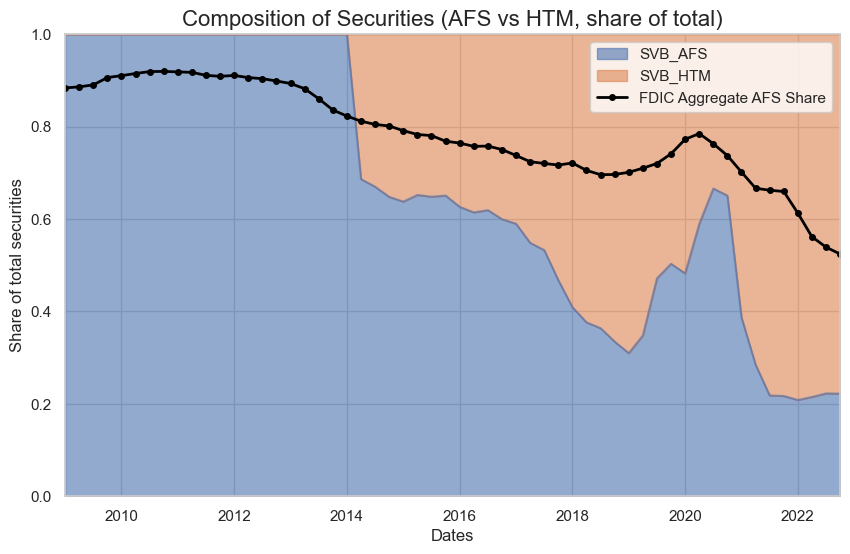

In [245]:
# Restrict both datasets to 2010 onwards and before SVB collapse (last available SVB date)
last_svb_date = bs_data.index.max()
df_sub = bs_data[(bs_data.index >= "2009-01-01") & (bs_data.index <= last_svb_date)].copy()
fdic_sub = fdic_comp[(fdic_comp.index >= "2009-01-01") & (fdic_comp.index <= last_svb_date)].copy()

# Compute shares
sec_total_svb = df_sub['AFS_FV'] + df_sub['HTM_BV']
shares_svb = pd.DataFrame({
    "SVB_AFS": df_sub['AFS_FV'] / sec_total_svb,
    "SVB_HTM": df_sub['HTM_BV'] / sec_total_svb,
})

sec_total_fdic = fdic_sub['AFS_FV'] + fdic_sub['HTM_BV']
shares_fdic = pd.DataFrame({
    "FDIC_AFS": fdic_sub['AFS_FV'] / sec_total_fdic,
}, index=fdic_sub.index).dropna()

# Combine into a single DataFrame, aligned by date
shares_all = pd.concat([shares_svb, shares_fdic], axis=1)

# Plot
fig, ax = plt.subplots(figsize=(10,6), dpi=100)
ax = shares_all[['SVB_AFS','SVB_HTM']].plot.area(ax=ax, alpha=0.6)
shares_all['FDIC_AFS'].plot(ax=ax, style='-o', markersize=4, color='black', label='FDIC Aggregate AFS Share', linewidth=2)

plt.title("Composition of Securities (AFS vs HTM, share of total)", fontsize=16)
plt.ylabel("Share of total securities", fontsize=12)
plt.ylim(0,1)
plt.legend()
plt.show()


#### 1.4.3 Ratio Analysis

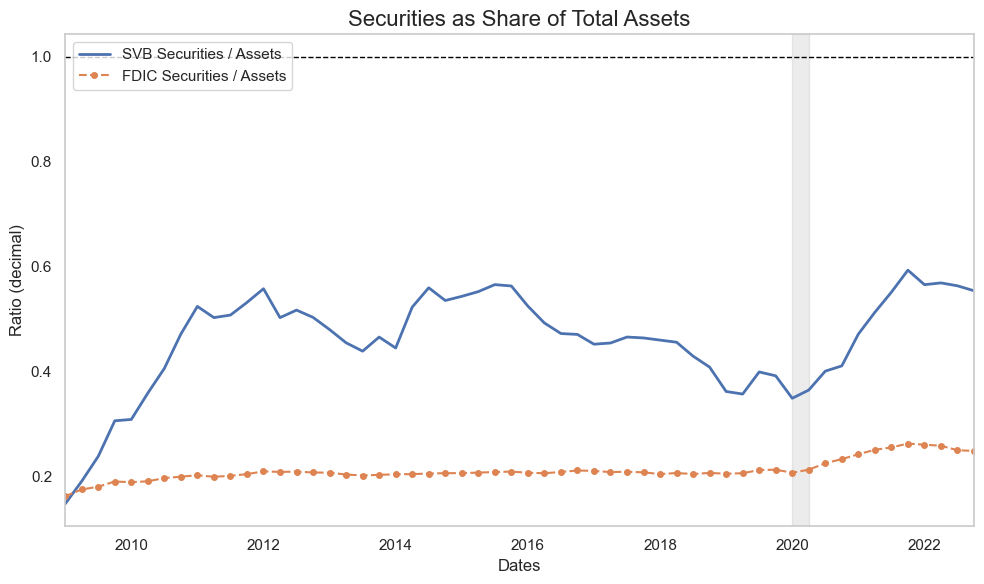

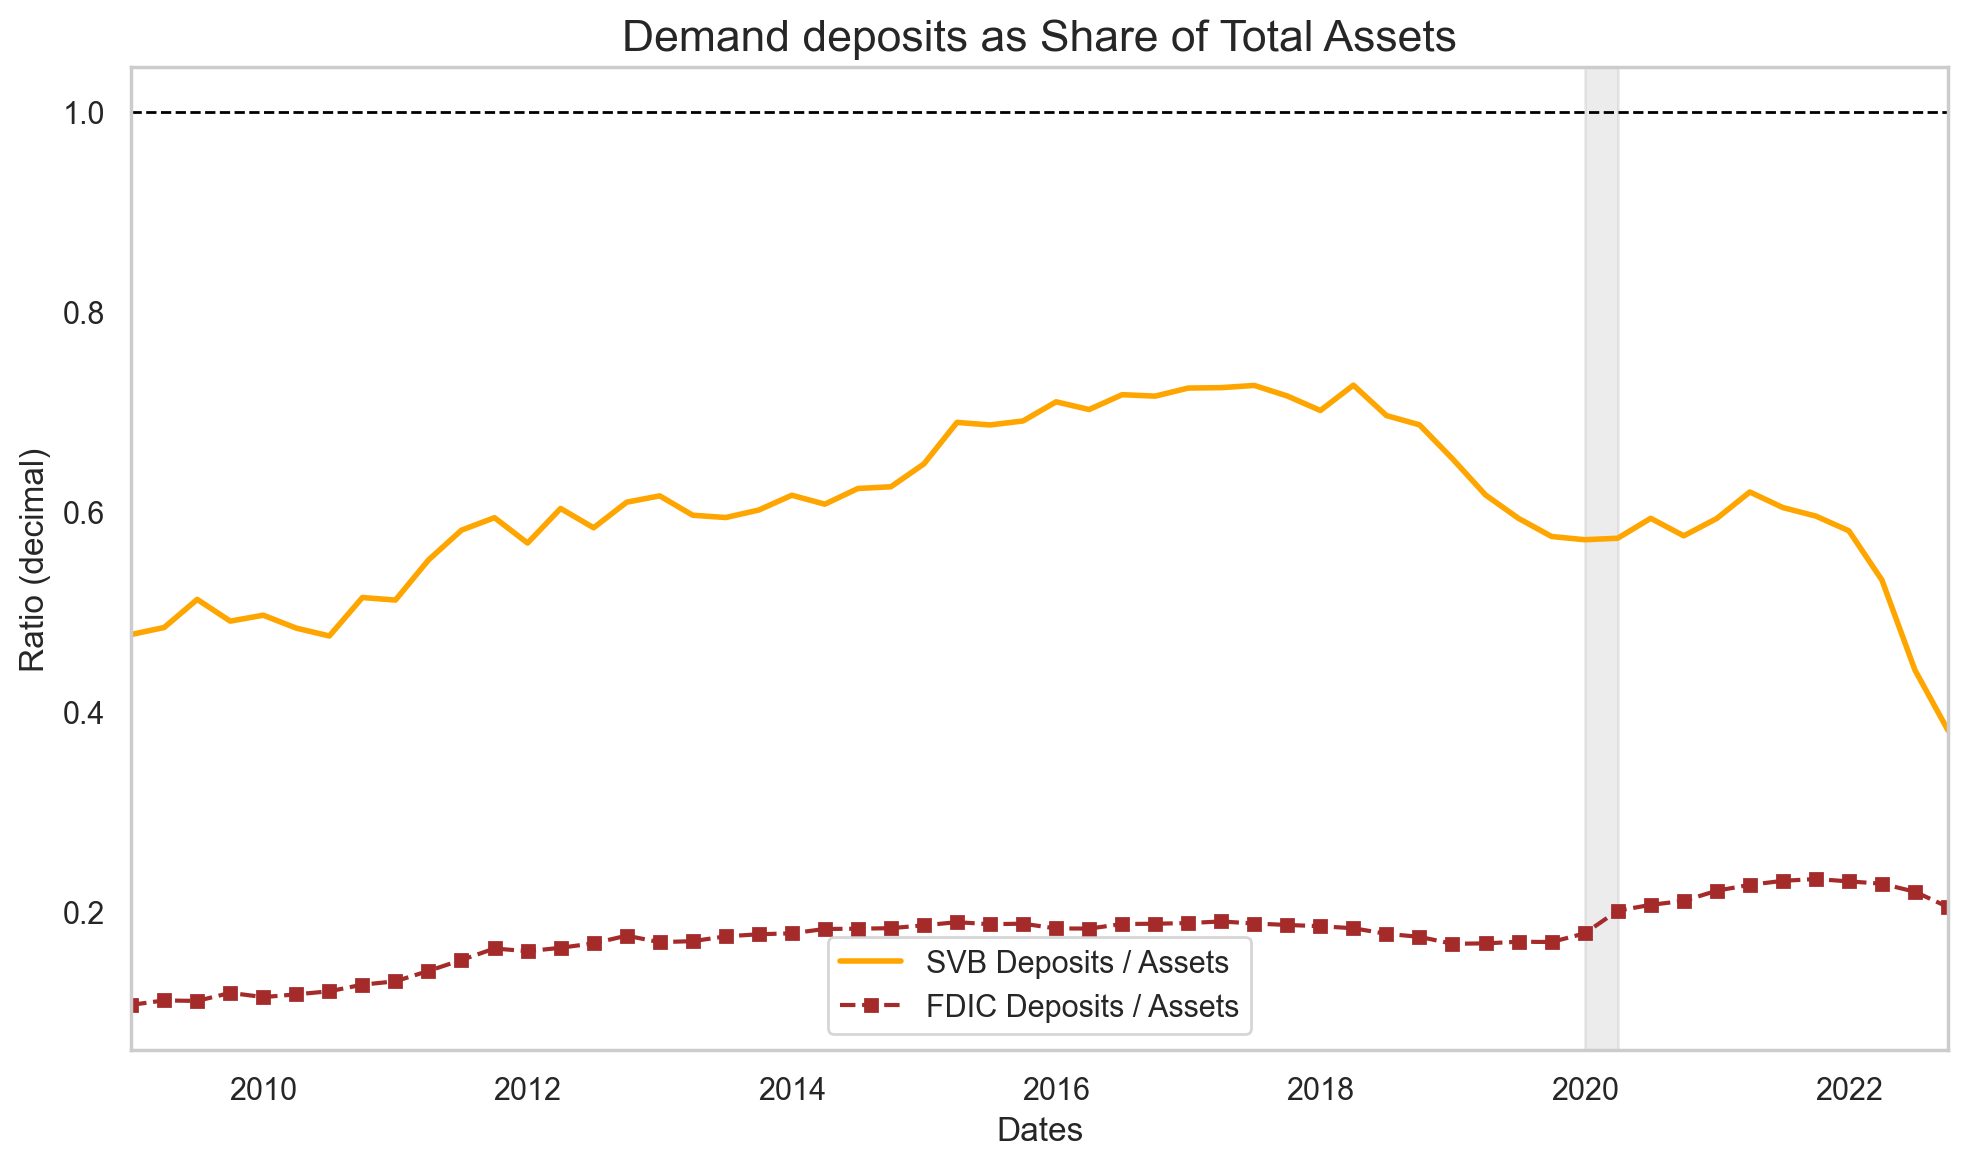

In [246]:
 # --- SVB ratios (already restricted to 2010â€“collapse) ---
df_sub['Securities_ratio'] = (df_sub['AFS_FV'] + df_sub['HTM_BV']) / df_sub['TotalAssets']
df_sub['Deposits_ratio']   = df_sub['DemandDeposits'] / df_sub['TotalAssets']

# --- FDIC ratios (aligned to same date range) ---
fdic_sub = fdic_comp[(fdic_comp.index >= df_sub.index.min()) & (fdic_comp.index <= df_sub.index.max())].copy()
fdic_sub['Securities_ratio'] = fdic_sub['Securities'] / fdic_sub['TotalAssets']
fdic_sub['Deposits_ratio']   = fdic_sub['DemandDeposits'] / fdic_sub['TotalAssets']

# -----------------------------
# Plot Securities / Assets
# -----------------------------
fig, ax = plt.subplots(figsize=(10,6), dpi=100)
df_sub['Securities_ratio'].plot(ax=ax, label='SVB Securities / Assets', linewidth=2)
fdic_sub['Securities_ratio'].plot(ax=ax, label='FDIC Securities / Assets', linestyle='--', marker='o', markersize=4)

add_covid_shade(ax)
ax.axhline(1, color='black', linestyle='--', linewidth=1)
ax.set_ylabel("Ratio (decimal)", fontsize=12)
ax.set_title("Securities as Share of Total Assets", fontsize=16)
ax.legend(loc='best')
ax.grid(False)
plt.tight_layout()
plt.show()

# -----------------------------
# Plot Deposits / Assets
# -----------------------------
fig, ax = plt.subplots(figsize=(10,6), dpi=200)
df_sub['Deposits_ratio'].plot(ax=ax, label='SVB Deposits / Assets', color='orange', linewidth=2)
fdic_sub['Deposits_ratio'].plot(ax=ax, label='FDIC Deposits / Assets', color='brown', linestyle='--', marker='s', markersize=4)

add_covid_shade(ax)
ax.axhline(1, color='black', linestyle='--', linewidth=1)
ax.set_ylabel("Ratio (decimal)", fontsize=12)
ax.set_title("Demand deposits as Share of Total Assets", fontsize=16)
ax.legend(loc='best')
ax.grid(False)
plt.tight_layout()
plt.show()


#### 1.4.4 Fair Value Analysis

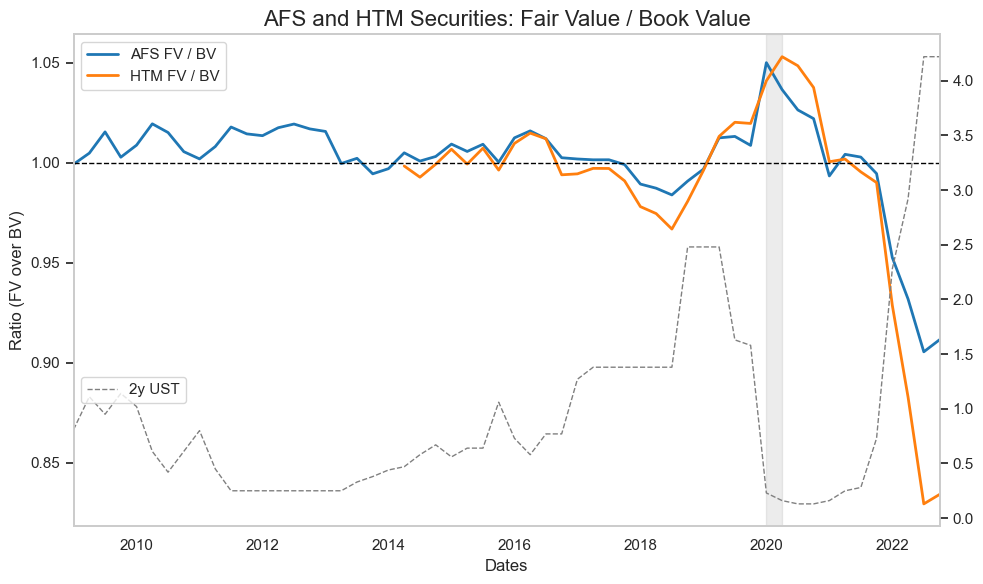

In [247]:
# -----------------------------
# AFS and HTM FV / BV ratios
# -----------------------------
df_sub['AFS_ratio'] = df_sub['AFS_FV'] / df_sub['AFS_BV']
df_sub['HTM_ratio'] = df_sub['HTM_FV'] / df_sub['HTM_BV']
# add market rates for context (making sure that if precise date isnt there we use closest prior)
mkt_sub = mkt[(mkt.index >= df_sub.index.min()) & (mkt.index <= df_sub.index.max())].copy()
df_sub = df_sub.join(mkt_sub, rsuffix='_mkt').ffill()


fig, ax = plt.subplots(figsize=(10,6), dpi=100)
df_sub['AFS_ratio'].plot(ax=ax, label='AFS FV / BV', color='tab:blue', linewidth=2)
df_sub['HTM_ratio'].plot(ax=ax, label='HTM FV / BV', color='tab:orange', linewidth=2)
# Plot rates on secondary axis
ax2 = ax.twinx()
df_sub['MKT'].plot(ax=ax2, label='2y UST', color='grey', linestyle='--', linewidth=1)
ax2.grid(False)

add_covid_shade(ax)
ax.axhline(1, color='black', linestyle='--', linewidth=1)
ax.set_ylabel("Ratio (FV over BV)", fontsize=12)
ax.set_title("AFS and HTM Securities: Fair Value / Book Value", fontsize=16)
ax.legend(loc='best')
ax2.legend(loc=[0.008,0.25])
ax.grid(False)
plt.tight_layout()
plt.show()

### Call Report Analysis

In [ ]:
import os
import re
import glob
import math
import pandas as pd
import xml.etree.ElementTree as ET

# -------------------------
# 0) Point this to your folder
# -------------------------
DATA_DIR = r"data/Input/SVB/call_reports"

# Build absolute file paths
FILES = sorted([
    os.path.join(DATA_DIR, f)
    for f in os.listdir(DATA_DIR)
    if re.match(r"Call_Cert24735_\d{8}\.XBRL$", f, re.IGNORECASE)
])

if not FILES:
    raise FileNotFoundError(f"No XBRL files found in: {DATA_DIR}")

# ----------------------------
# 1) Keep only the variables you decided to keep
# ----------------------------
CONCEPTS = {
    "deposits_total": ["RCON2200", "RCFD2200"],
    "deposits_uninsured_est": ["RCON5597", "RCFD5597"],
    "loans_bv": ["RCFD2122", "RCON2122"],

    # Realized gains(losses) on securities, YTD (you confirmed they exist 100%)
    "sec_realized_gl_htm_ytd": ["RIAD3521"],
    "sec_realized_gl_afs_ytd": ["RIAD3196"],
}

# ----------------------------
# 2) XBRL parsing helpers
# ----------------------------
def infer_report_date_from_filename(path):
    m = re.search(r"_(\d{2})(\d{2})(\d{4})\.XBRL$", os.path.basename(path), re.IGNORECASE)
    if not m:
        raise ValueError(f"Cannot parse report date from filename: {path}")
    mm, dd, yyyy = m.group(1), m.group(2), m.group(3)
    return f"{yyyy}-{mm}-{dd}"

def parse_instance_values(xbrl_path, wanted_concepts):
    tree = ET.parse(xbrl_path)
    root = tree.getroot()
    wanted = set(wanted_concepts)
    found = {}  # concept -> list of (contextRef, value)

    for elem in root.iter():
        tag = elem.tag.split("}")[-1]
        if tag not in wanted:
            continue
        txt = elem.text
        if txt is None:
            continue
        txt = txt.strip().replace(",", "")
        try:
            val = float(txt)
        except:
            continue
        cref = elem.attrib.get("contextRef")
        found.setdefault(tag, []).append((cref, val))

    return found

def pick_preferred_fact(facts_dict, concept_list, prefer_prefixes=("CI_", "CD_")):
    for c in concept_list:
        if c not in facts_dict:
            continue
        rows = facts_dict[c]
        for pref in prefer_prefixes:
            for cref, val in rows:
                if cref and cref.startswith(pref):
                    return val, c
        return rows[0][1], c
    return None, None

def build_panel(files, concepts_dict):
    all_wanted = sorted({c for lst in concepts_dict.values() for c in lst})
    rows = []

    for f in files:
        facts = parse_instance_values(f, all_wanted)
        report_date = infer_report_date_from_filename(f)

        row = {"report_date": report_date, "file": os.path.basename(f)}
        for k, clist in concepts_dict.items():
            val, used = pick_preferred_fact(facts, clist)
            row[k] = val
            row[k + "__concept_used"] = used
        rows.append(row)

    panel = pd.DataFrame(rows)
    panel["report_date"] = pd.to_datetime(panel["report_date"])
    panel = panel.sort_values("report_date").reset_index(drop=True)
    return panel

# ----------------------------
# 3) Flow construction (the useful ones you can do)
# ----------------------------
def ytd_to_quarterly(ytd: pd.Series, dates: pd.Series) -> pd.Series:
    df = pd.DataFrame({"date": pd.to_datetime(dates), "ytd": ytd})
    df["year"] = df["date"].dt.year
    df = df.sort_values("date")

    q = df.groupby("year")["ytd"].diff()
    is_q1 = df["date"].dt.quarter == 1
    q.loc[is_q1] = df.loc[is_q1, "ytd"]
    return q

def add_flows(panel: pd.DataFrame) -> pd.DataFrame:
    out = panel.copy().sort_values("report_date")

    # insured deposits
    out["deposits_insured_est"] = out["deposits_total"] - out["deposits_uninsured_est"]

    # QoQ balance sheet flows (first differences)
    for col in ["deposits_total", "deposits_uninsured_est", "deposits_insured_est", "loans_bv"]:
        out[f"d_{col}"] = out[col].diff()
        out[f"pct_{col}"] = out[f"d_{col}"] / out[col].shift(1)

    # Realized securities gains/losses: YTD -> quarterly
    out["sec_realized_gl_htm_q"] = ytd_to_quarterly(out["sec_realized_gl_htm_ytd"], out["report_date"])
    out["sec_realized_gl_afs_q"] = ytd_to_quarterly(out["sec_realized_gl_afs_ytd"], out["report_date"])
    out["sec_realized_gl_total_q"] = out["sec_realized_gl_htm_q"] + out["sec_realized_gl_afs_q"]

    # Scale realized P&L by deposits (useful normalization)
    out["sec_realized_gl_total_q_pct_deposits"] = out["sec_realized_gl_total_q"] / out["deposits_total"]

    return out

# ----------------------------
# 4) Run
# ----------------------------
panel = build_panel(FILES, CONCEPTS)
panel_flows = add_flows(panel)

# Show the columns you actually care about
cols = [
    "report_date",
    "deposits_total", "deposits_uninsured_est", "deposits_insured_est",
    "loans_bv",
    "sec_realized_gl_htm_q", "sec_realized_gl_afs_q", "sec_realized_gl_total_q",
    "d_deposits_total", "d_deposits_uninsured_est", "d_deposits_insured_est",
    "d_loans_bv",
    "pct_deposits_total", "pct_loans_bv",
    "sec_realized_gl_total_q_pct_deposits",
]
panel_flows[cols]


,report_date,deposits_total,deposits_uninsured_est,deposits_insured_est,loans_bv,sec_realized_gl_htm_q,sec_realized_gl_afs_q,sec_realized_gl_total_q,d_deposits_total,d_deposits_uninsured_est,d_deposits_insured_est,d_loans_bv,pct_deposits_total,pct_loans_bv,sec_realized_gl_total_q_pct_deposits
0,2017-03-31,3.900869e+10,3.544615e+10,3.562541e+09,2.042548e+10,0.0,0.0,0.0,NaN,NaN,NaN,NaN,NaN,NaN,0.000000
1,2017-06-30,3.984383e+10,3.619648e+10,3.647352e+09,2.097647e+10,0.0,0.0,0.0,8.351470e+08,7.503360e+08,8.481100e+07,5.509890e+08,0.021409,0.026976,0.000000
2,2017-09-30,4.198625e+10,3.789535e+10,4.090905e+09,2.218933e+10,0.0,0.0,0.0,2.142417e+09,1.698864e+09,4.435530e+08,1.212862e+09,0.053770,0.057820,0.000000
3,2017-12-31,4.141910e+10,3.737191e+10,4.047183e+09,2.310632e+10,0.0,-8783000.0,-8783000.0,-5.671550e+08,-5.234330e+08,-4.372200e+07,9.169880e+08,-0.013508,0.041326,-0.000212
4,2018-03-31,4.365428e+10,3.956650e+10,4.087778e+09,2.458794e+10,0.0,0.0,0.0,2.235186e+09,2.194591e+09,4.059500e+07,1.481628e+09,0.053965,0.064122,0.000000
5,2018-06-30,4.591048e+10,4.152609e+10,4.384397e+09,2.599619e+10,0.0,0.0,0.0,2.256201e+09,1.959582e+09,2.966190e+08,1.408247e+09,0.051683,0.057274,0.000000
6,2018-09-30,4.516048e+10,4.062149e+10,4.538984e+09,2.749492e+10,0.0,0.0,0.0,-7.500070e+08,-9.045940e+08,1.545870e+08,1.498724e+09,-0.016336,0.057652,0.000000
7,2018-12-31,4.525665e+10,3.954978e+10,5.706874e+09,2.833828e+10,0.0,-740000.0,-740000.0,9.617800e+07,-1.071712e+09,1.167890e+09,8.433650e+08,0.002130,0.030673,-0.000016
8,2019-03-31,4.792073e+10,4.206195e+10,5.858778e+09,2.882272e+10,0.0,-3630000.0,-3630000.0,2.664073e+09,2.512169e+09,1.519040e+08,4.844390e+08,0.058866,0.017095,-0.000076
9,2019-06-30,5.107357e+10,4.449324e+10,6.580326e+09,2.917821e+10,0.0,-275000.0,-275000.0,3.152842e+09,2.431294e+09,7.215480e+08,3.554890e+08,0.065793,0.012334,-0.000005


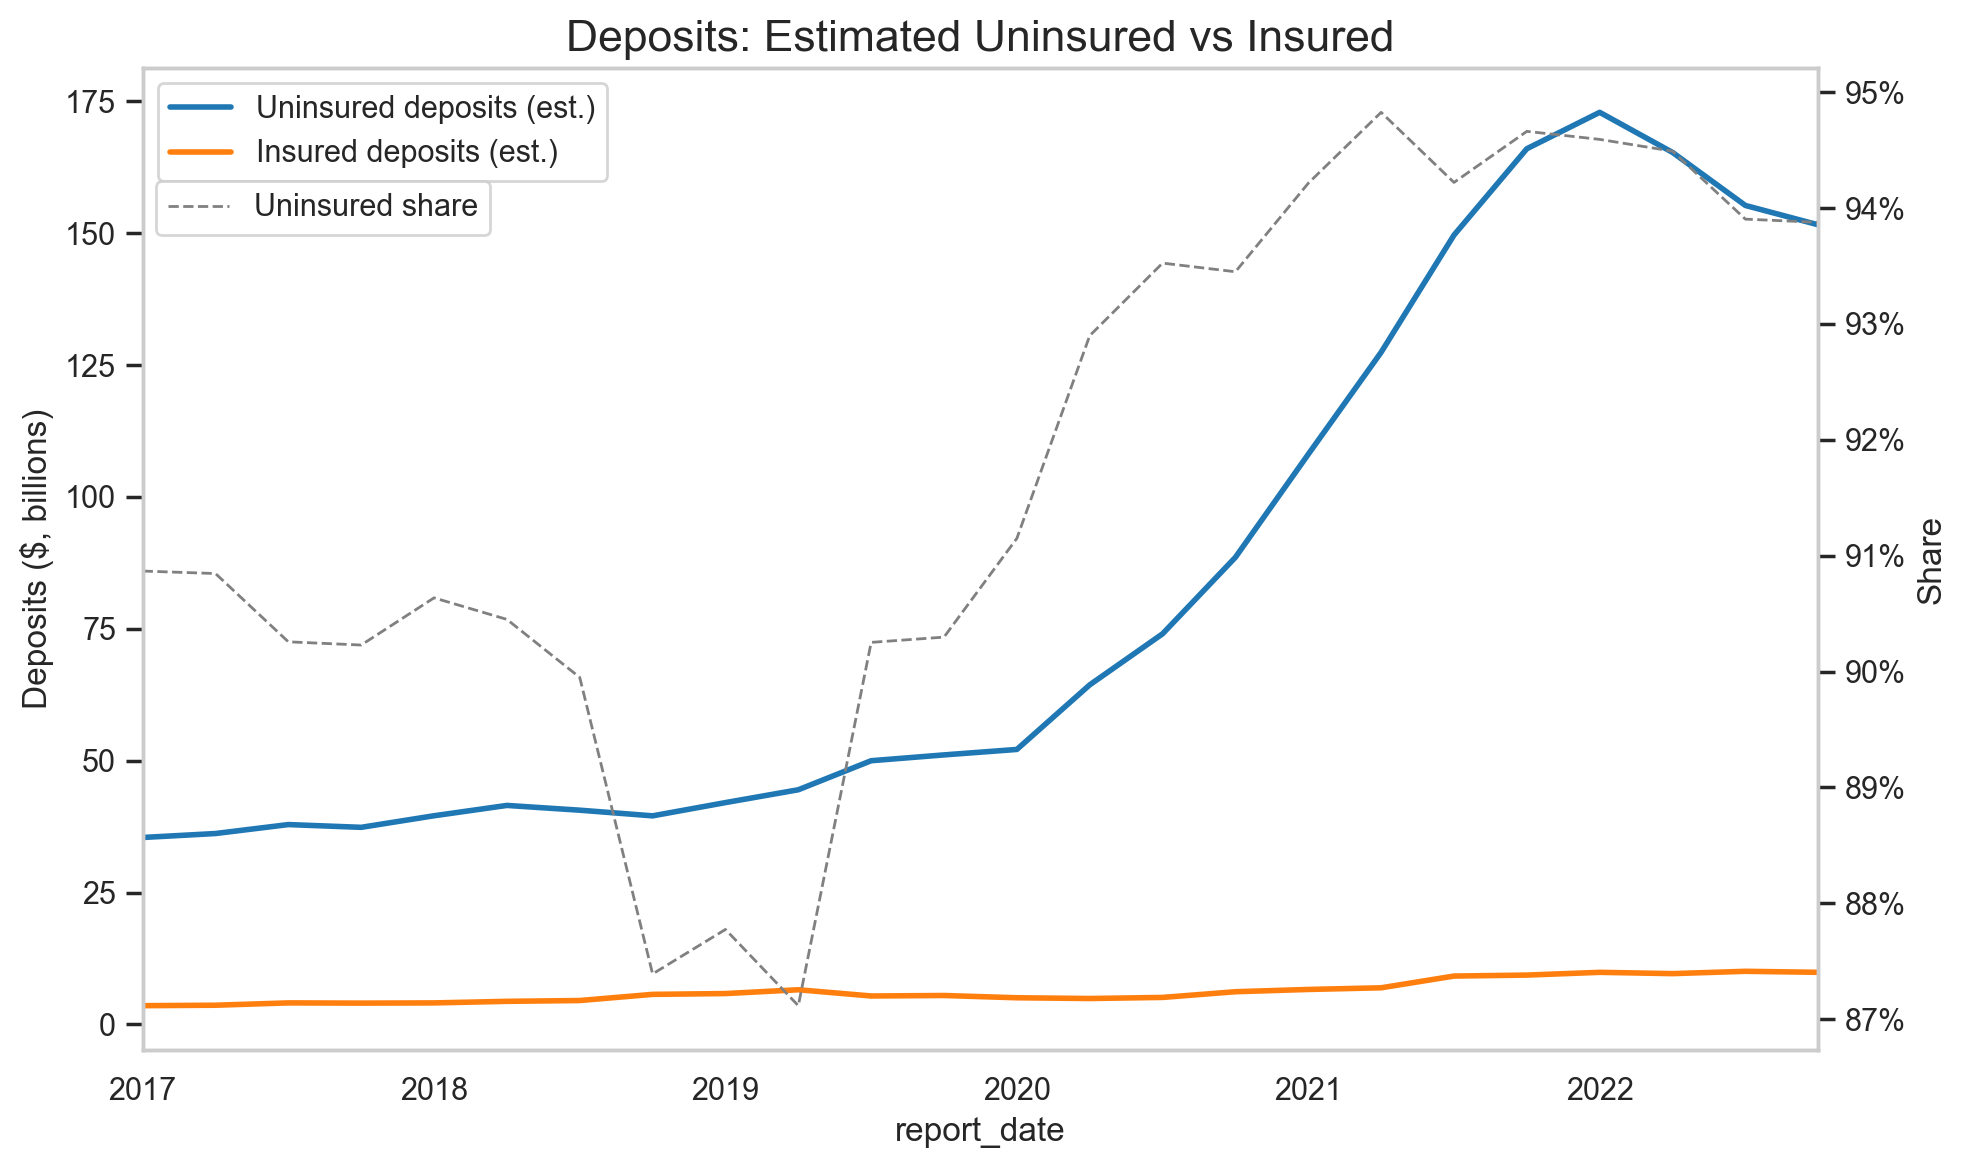

In [224]:
import matplotlib.pyplot as plt

# assumes you already have: panel_flows (from our extraction code)
# and your helper: add_covid_shade(ax)

# -----------------------------
# Prep: index by date
# -----------------------------
df_sub = panel_flows.copy()
df_sub = df_sub.set_index("report_date").sort_index()

# -----------------------------
# 1) Uninsured vs Insured deposits (levels + optional share)
# -----------------------------
df_sub["insured"] = df_sub["deposits_insured_est"]
df_sub["uninsured"] = df_sub["deposits_uninsured_est"]
df_sub["uninsured_share"] = df_sub["uninsured"] / df_sub["deposits_total"]

fig, ax = plt.subplots(figsize=(10,6), dpi=200)

(df_sub["uninsured"] / 1000000000).plot(ax=ax, label="Uninsured deposits (est.)", color="tab:blue", linewidth=2)
(df_sub["insured"] / 1000000000).plot(ax=ax, label="Insured deposits (est.)", color="tab:orange", linewidth=2)

# share on secondary axis (optional but usually useful)
ax2 = ax.twinx()
df_sub["uninsured_share"].plot(ax=ax2, label="Uninsured share", color="grey", linestyle="--", linewidth=1)
ax2.grid(False)

# add_covid_shade(ax)

ax.set_ylabel("Deposits ($, billions)", fontsize=12)
ax2.set_ylabel("Share", fontsize=12)
# set pct format for secondary y-axis
ax2.yaxis.set_major_formatter(plt.FuncFormatter(lambda y, _: f'{y:.0%}'))
ax.set_title("Deposits: Estimated Uninsured vs Insured", fontsize=16)
ax.legend(loc="best")
ax2.legend(loc=[0.008,0.83])
ax.grid(False)

plt.tight_layout()
plt.show()

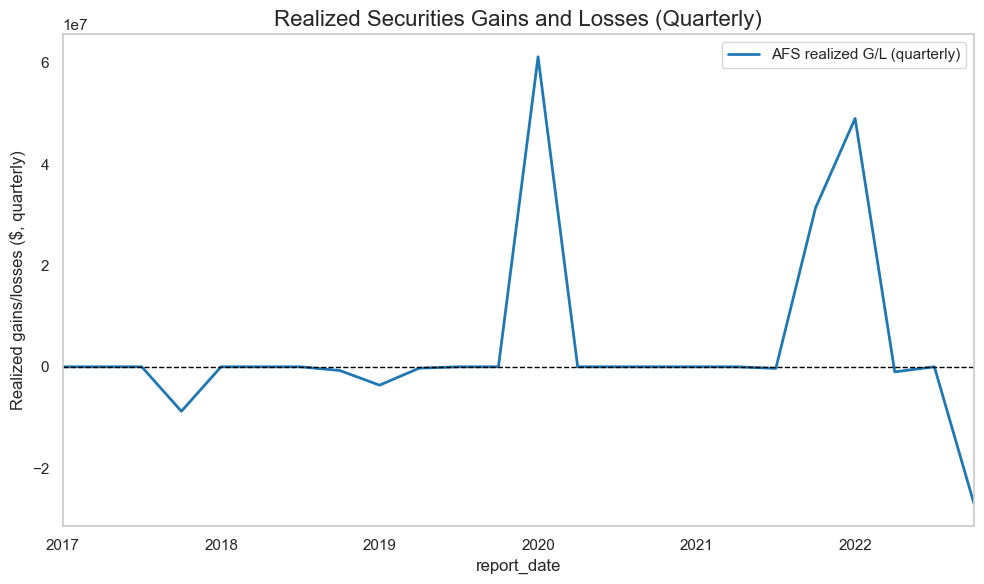

In [218]:
# -----------------------------
# 2) Losses plot (realized securities gains/losses, quarterly flows)
# -----------------------------
# these columns come from our code:
# sec_realized_gl_htm_q, sec_realized_gl_afs_q, sec_realized_gl_total_q
# sign convention: positive = net gain, negative = net loss

fig, ax = plt.subplots(figsize=(10,6), dpi=100)

df_sub["sec_realized_gl_afs_q"].plot(ax=ax, label="AFS realized G/L (quarterly)", color="tab:blue", linewidth=2)
# df_sub["sec_realized_gl_htm_q"].plot(ax=ax, label="HTM realized G/L (quarterly)", color="tab:orange", linewidth=2)
# df_sub["sec_realized_gl_total_q"].plot(ax=ax, label="Total realized G/L (quarterly)", color="grey", linestyle="--", linewidth=1)

# add_covid_shade(ax)

ax.axhline(0, color="black", linestyle="--", linewidth=1)
ax.set_ylabel("Realized gains/losses ($, quarterly)", fontsize=12)
ax.set_title("Realized Securities Gains and Losses (Quarterly)", fontsize=16)
ax.legend(loc="best")
ax.grid(False)
# ax.set_xlim(df_sub.index.min() - pd.DateOffset(months=3), df_sub.index.max()+pd.DateOffset(months=3))

plt.tight_layout()
plt.show()

### 1.5 Other Banks Analysis

In [ ]:
# import pandas as pd
# import numpy as np

# compustat = pd.read_csv("data/Input/SVB/ZScore_Data.csv")
# compustat

In [157]:
# import pandas as pd
# import numpy as np

# # 1. Basic cleaning
# df = compustat.copy()
# df['datadate'] = pd.to_datetime(df['datadate'])
# df['year'] = df['datadate'].dt.year

# # Filter to SVB only if you have multiple banks
# # df = df[df['tic'] == 'SIVB']

# # 2. Build annual panel
# agg = (
#     df
#     .sort_values(['gvkey', 'year', 'datadate'])
#     .groupby(['gvkey', 'year'])
#     .apply(
#         lambda g: pd.Series({
#             'ni_annual': g['niq'].sum(skipna=True),
#             'assets_avg': g['atq'].mean(skipna=True),
#             'assets_year_end': g['atq'].iloc[-1],
#             'equity_year_end': g['teqq'].iloc[-1],
#             'last_datadate': g['datadate'].iloc[-1]
#         }),
#         include_groups=False
#     )
#     .reset_index()
# )

# # 3. Compute ROA and EQTA
# agg['ROA'] = agg['ni_annual'] / agg['assets_avg']
# agg['EQTA'] = agg['equity_year_end'] / agg['assets_year_end']

# # 4. Rolling sigma of ROA (choose window_y = 5 or 3)
# window_y = 5

# agg = agg.sort_values(['gvkey', 'year'])

# agg['sigma_ROA'] = (
#     agg
#     .groupby('gvkey')['ROA']
#     .rolling(window_y, min_periods=window_y)
#     .std()
#     .reset_index(level=0, drop=True)
# )

# # 5. Compute Z-score
# agg['Z_LaevenLevine'] = (agg['ROA'] + agg['EQTA']) / agg['sigma_ROA']

# # Optional: drop early years without sigma
# agg = agg[~agg['sigma_ROA'].isna()].copy()

# # Now agg has one row per year with Z-score
# df_annual = agg[['gvkey', 'year', 'last_datadate', 'ROA', 'EQTA', 'sigma_ROA', 'Z_LaevenLevine']]

In [158]:
# import pandas as pd
# import matplotlib.pyplot as plt

# # --- make sure x is real datetime, and sorted ---
# dfp = df_annual.copy()
# dfp["last_datadate"] = pd.to_datetime(dfp["last_datadate"], errors="coerce")
# dfp = dfp.dropna(subset=["last_datadate"]).sort_values("last_datadate")

# # --- desired window ---
# x0 = pd.Timestamp("2010-01-01")
# x1 = pd.Timestamp("2024-01-01")

# plt.figure(figsize=(8, 5))
# plt.plot(dfp["last_datadate"], dfp["Z_LaevenLevine"], label="Annual Z-Score")

# # Risk bands (and place labels at the left edge of the window, not at overall min date)
# for y, label in [(60, "Very Safe"),
#                  (40, "Safe"),
#                  (20, "Moderate Risk"),
#                  (10, "High Risk")]:
#     plt.axhline(y, color="gray", linestyle="--", alpha=0.5)
#     plt.text(x0, y + 0.5, label, color="gray", va="bottom")

# # Event marker
# plt.axvline(pd.Timestamp("2023-03-10"), color="red", linestyle="--")

# plt.title("SVB Annual Laevenâ€“Levine Z-Score with Risk Thresholds")
# plt.ylabel("Z-Score")
# plt.xlabel("Year")

# plt.xlim(x0, x1)

# plt.grid(False)
# plt.show()

In [159]:
# import pandas as pd
# import numpy as np

# # df: quarterly WRDSâ€“Compustat Bank Fundamentals for SIVB
# # columns needed: gvkey, tic, datadate, atq, teqq, niq

# df = df.copy()
# df['datadate'] = pd.to_datetime(df['datadate'])
# df = df.sort_values(['gvkey', 'datadate'])

# # 1. Construct quarterly ratios
# df['ROA_q'] = df['niq'] / df['atq']
# df['EQTA_q'] = df['teqq'] / df['atq']

# # 2. Rolling sigma of ROA_q
# window = 12   # 12 quarters = 3 years
# df['sigma_ROA'] = (
#     df.groupby('gvkey')['ROA_q']
#       .rolling(window, min_periods=window)
#       .std()
#       .reset_index(level=0, drop=True)
# )

# # 3. Quarterly Z-score
# df['Z_LL'] = (df['ROA_q'] + df['EQTA_q']) / df['sigma_ROA']

# # Optional: drop early quarters without sigma
# df_out = df.dropna(subset=['sigma_ROA']).copy()

In [160]:
# import pandas as pd
# import matplotlib.pyplot as plt

# # --- make sure x is real datetime, and sorted ---
# dfp = df_out.copy()
# dfp["datadate"] = pd.to_datetime(dfp["datadate"], errors="coerce")
# dfp = dfp.dropna(subset=["datadate"]).sort_values("datadate")

# # --- optional window (set if you want) ---
# x0 = pd.Timestamp("2010-01-01")
# x1 = pd.Timestamp("2024-01-01")

# plt.figure(figsize=(8, 5))
# plt.plot(dfp["datadate"], dfp["Z_LL"], label="Quarterly Z-Score")

# # Risk bands (label at left edge of the window)
# for y, label in [(150, "Very Safe"),
#                  (100, "Safe"),
#                  (60, "Moderate Risk"),
#                  (30, "High Risk")]:
#     plt.axhline(y, color="gray", linestyle="--", alpha=0.5)
#     plt.text(x0, y + 2, label, color="gray", va="bottom")

# # Failure vertical line
# plt.axvline(pd.Timestamp("2023-03-10"), color="red", linestyle="--")

# plt.title("SVB Quarterly Laevenâ€“Levine Z-Score with Risk Thresholds")
# plt.ylabel("Z-Score")
# plt.xlabel("Quarter")

# plt.xlim(x0, x1)  # comment this out if you don't want to force a window

# plt.grid(False)
# plt.show()

In [ ]:
import pandas as pd
import numpy as np

compustat = pd.read_csv("data/Input/SVB/ZScore_Data.csv")

### Quarterly Z-score calculation

df = compustat.copy()
df['datadate'] = pd.to_datetime(df['datadate'])
df = df.sort_values(['gvkey', 'datadate'])

# 1. Construct quarterly ratios
df['ROA_q'] = df['niq'] / df['atq']
df['EQTA_q'] = df['teqq'] / df['atq']

# 2. Rolling sigma of ROA_q
window = 12   # 12 quarters = 3 years
df['sigma_ROA'] = (
    df.groupby('gvkey')['ROA_q']
      .rolling(window, min_periods=window)
      .std()
      .reset_index(level=0, drop=True)
)

# 3. Quarterly Z-score
df['Z_LL'] = (df['ROA_q'] + df['EQTA_q']) / df['sigma_ROA']

# Optional: drop early quarters without sigma
df_out = df.dropna(subset=['sigma_ROA']).copy()


### Annual Z-score calculation

# 1. Basic cleaning
df_y = compustat.copy()
df_y['datadate'] = pd.to_datetime(df_y['datadate'])
df_y['year'] = df_y['datadate'].dt.year

# Filter to SVB only if you have multiple banks
# df = df[df['tic'] == 'SIVB']

# 2. Build annual panel
agg_y = (
    df_y
    .sort_values(['gvkey', 'year', 'datadate'])
    .groupby(['gvkey', 'year'])
    .apply(
        lambda g: pd.Series({
            'ni_annual': g['niq'].sum(skipna=True),
            'assets_avg': g['atq'].mean(skipna=True),
            'assets_year_end': g['atq'].iloc[-1],
            'equity_year_end': g['teqq'].iloc[-1],
            'last_datadate': g['datadate'].iloc[-1]
        }),
        include_groups=False
    )
    .reset_index()
)

# 3. Compute ROA and EQTA
agg_y['ROA'] = agg_y['ni_annual'] / agg_y['assets_avg']
agg_y['EQTA'] = agg_y['equity_year_end'] / agg_y['assets_year_end']

# 4. Rolling sigma of ROA (choose window_y = 5 or 3)
window_y = 5

agg_y = agg_y.sort_values(['gvkey', 'year'])

agg_y['sigma_ROA'] = (
    agg_y
    .groupby('gvkey')['ROA']
    .rolling(window_y, min_periods=window_y)
    .std()
    .reset_index(level=0, drop=True)
)

# 5. Compute Z-score
agg_y['Z_LaevenLevine'] = (agg_y['ROA'] + agg_y['EQTA']) / agg_y['sigma_ROA']

# Optional: drop early years without sigma
agg_y = agg_y[~agg_y['sigma_ROA'].isna()].copy()

# Now agg has one row per year with Z-score
df_annual = agg_y[['gvkey', 'year', 'last_datadate', 'ROA', 'EQTA', 'sigma_ROA', 'Z_LaevenLevine']]



In [162]:
# plt.figure(figsize=(12,8))
# plt.plot(df_annual['last_datadate'], df_annual['Z_LaevenLevine'], label='Annual Z-Score', linewidth=2)

# # Risk bands
# for y, label in [(60, 'Very Safe'),
#                  (40, 'Safe'),
#                  (20, 'Moderate Risk'),
#                  (10, 'High Risk'),
#                  (0, 'Distress Zone')]:
    
#     plt.axhline(y, color='gray', linestyle='--', alpha=0.5)
#     plt.text(df_annual['last_datadate'].min(), y+0.5, label, color='black', fontsize=14)

# plt.axvline(pd.Timestamp("2023-03-10"), color='red', linestyle='--')

# plt.title("SVB Annual Laevenâ€“Levine Z-Score with Risk Thresholds", fontsize=16)
# plt.ylabel("Z-Score", fontsize=14)
# plt.xlabel("Year", fontsize=14)
# plt.ylim(0, 175)
# plt.xticks(fontsize=14)
# plt.yticks(fontsize=14)
# plt.grid(False)
# plt.show()

# import matplotlib.pyplot as plt

# plt.figure(figsize=(12,8))
# plt.plot(df_out['datadate'], df_out['Z_LL'], label='Quarterly Z-Score', linewidth=2)
# # Risk bands
# for y, label in [(150, 'Very Safe'),
#                  (100, 'Safe'),
#                  (60, 'Moderate Risk'),
#                  (30, 'High Risk'),
#                  (0, 'Distress Zone')]:
#     plt.axhline(y, color='gray', linestyle='--', alpha=0.5)
#     plt.text(df_out['datadate'].min(), y+2, label, color='black', fontsize=14)

# # Failure vertical line
# plt.axvline(pd.Timestamp("2023-03-10"), color='red', linestyle='--')

# plt.title("SVB Quarterly Laevenâ€“Levine Z-Score with Risk Thresholds", fontsize=16)
# plt.ylabel("Z-Score", fontsize=14)
# plt.xlabel("Quarter", fontsize=14)
# plt.xticks(fontsize=14)
# plt.yticks(fontsize=14)
# plt.ylim(0, 300)
# plt.grid(False)
# plt.show()


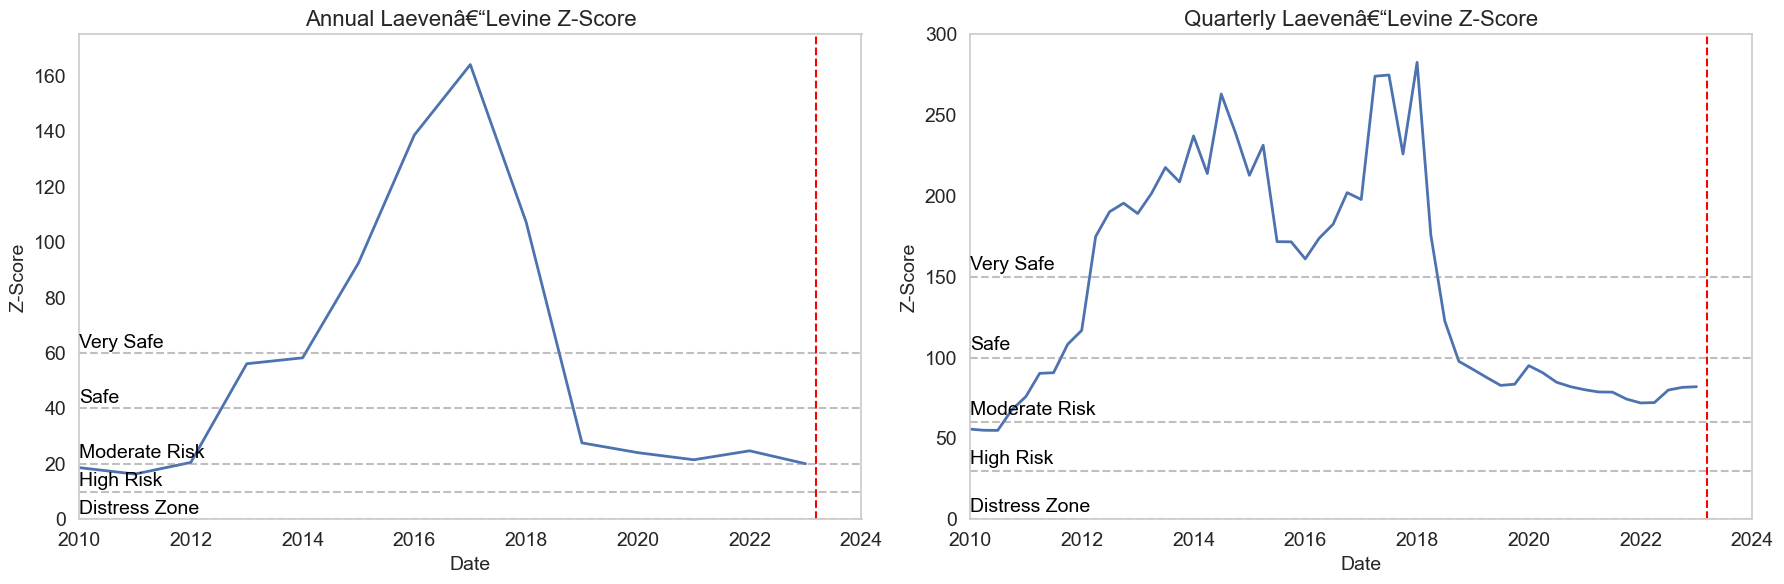

In [163]:
import pandas as pd
import matplotlib.pyplot as plt

# --- ensure datetime + sort (prevents xlim weirdness) ---
dfA = df_annual.copy()
dfA["last_datadate"] = pd.to_datetime(dfA["last_datadate"], errors="coerce")
dfA = dfA.dropna(subset=["last_datadate"]).sort_values("last_datadate")

dfQ = df_out.copy()
dfQ["datadate"] = pd.to_datetime(dfQ["datadate"], errors="coerce")
dfQ = dfQ.dropna(subset=["datadate"]).sort_values("datadate")

# same xlim as before
x0 = pd.Timestamp("2010-01-01")
x1 = pd.Timestamp("2024-01-01")

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(18, 6), dpi=100, sharex=True)

# --------------------
# Annual subplot
# --------------------
ax1.plot(dfA["last_datadate"], dfA["Z_LaevenLevine"], label="Annual Z-Score", linewidth=2)

for y, label in [(60, "Very Safe"),
                 (40, "Safe"),
                 (20, "Moderate Risk"),
                 (10, "High Risk"),
                 (0,  "Distress Zone")]:
    ax1.axhline(y, color="gray", linestyle="--", alpha=0.5)
    ax1.text(x0, y + 0.5, label, color="black", fontsize=14, va="bottom")

ax1.axvline(pd.Timestamp("2023-03-10"), color="red", linestyle="--")
ax1.set_title("Annual Laevenâ€“Levine Z-Score", fontsize=16)
ax1.set_ylabel("Z-Score", fontsize=14)
ax1.set_xlabel("Date", fontsize=14)
ax1.set_ylim(0, 175)
ax1.tick_params(axis="both", labelsize=14)
ax1.grid(False)
ax1.set_xlim(x0, x1)

# --------------------
# Quarterly subplot
# --------------------
ax2.plot(dfQ["datadate"], dfQ["Z_LL"], label="Quarterly Z-Score", linewidth=2)

for y, label in [(150, "Very Safe"),
                 (100, "Safe"),
                 (60,  "Moderate Risk"),
                 (30,  "High Risk"),
                 (0,   "Distress Zone")]:
    ax2.axhline(y, color="gray", linestyle="--", alpha=0.5)
    ax2.text(x0, y + 2, label, color="black", fontsize=14, va="bottom")

ax2.axvline(pd.Timestamp("2023-03-10"), color="red", linestyle="--")
ax2.set_title("Quarterly Laevenâ€“Levine Z-Score", fontsize=16)
ax2.set_ylabel("Z-Score", fontsize=14)
ax2.set_xlabel("Date", fontsize=14)
ax2.set_ylim(0, 300)
ax2.tick_params(axis="both", labelsize=14)
ax2.grid(False)
ax2.set_xlim(x0, x1)

plt.tight_layout()
plt.show()

In [ ]:
import pandas as pd
import numpy as np
import pandas as pd
import numpy as np
import pandas_datareader.data as web
from math import log, sqrt, erf
import numpy as np
import pandas as pd


# 1. Load data
comp = pd.read_csv("data/Input/SVB/Merton_Compustat_data.csv")
crsp = pd.read_csv("data/Input/SVB/Merton_CRSP_data.csv")
link = pd.read_csv("data/Input/SVB/Merton_CRSP_Compustat_Link.csv")

# 2. Parse dates
comp['datadate'] = pd.to_datetime(comp['datadate'])
crsp['date'] = pd.to_datetime(crsp['date'])
link['LINKDT'] = pd.to_datetime(link['LINKDT'])
link['LINKENDDT'] = pd.to_datetime(link['LINKENDDT'])

# 3. Clean CRSP and compute market equity
crsp = crsp.sort_values(['PERMNO', 'date'])

# Adjust price and shares with CRSP factors
crsp['prc_adj'] = crsp['PRC'] * crsp['CFACPR']
crsp['shrout_adj'] = crsp['SHROUT'] * crsp['CFACSHR']

# Market value of equity in dollars
crsp['mkt_equity'] = crsp['prc_adj'].abs() * crsp['shrout_adj'] * 1000.0

# Drop days with missing core fields
crsp = crsp.dropna(subset=['prc_adj', 'shrout_adj', 'mkt_equity'])

# 4. Build default point D on Compustat side
for col in ['atq', 'dlcq', 'dlttq', 'ltq']:
    if col not in comp.columns:
        comp[col] = np.nan

comp[['dlcq', 'dlttq']] = comp[['dlcq', 'dlttq']].fillna(0.0)

# KMV-style default point: ST debt + 0.5 * LT debt
comp['D_kmv'] = (comp['dlcq'] + 0.5 * comp['dlttq']) * 1000000

# Fallback: if no debt but total liabilities exist, use ltq
mask_no_debt = (comp['D_kmv'] == 0) & comp['ltq'].notna()
comp.loc[mask_no_debt, 'D_kmv'] = comp.loc[mask_no_debt, 'ltq']

# Keep only usable rows
comp = comp.dropna(subset=['atq', 'D_kmv']).sort_values(['gvkey', 'datadate'])

# 5. Prepare link table and attach gvkey to CRSP
link_use = link.copy()
link_use['LINKENDDT'] = link_use['LINKENDDT'].fillna(pd.Timestamp('2100-12-31'))

# Keep primary links only (P/C)
link_use = link_use[link_use['LINKPRIM'].isin(['P', 'C'])]

link_use = link_use[['gvkey', 'LPERMNO', 'LINKDT', 'LINKENDDT']]

# Merge CRSP with link table
crsp = crsp.merge(
    link_use,
    how='left',
    left_on='PERMNO',
    right_on='LPERMNO'
)

# Keep only rows where CRSP date is within link window
crsp = crsp[
    (crsp['date'] >= crsp['LINKDT']) &
    (crsp['date'] <= crsp['LINKENDDT'])
].copy()

# Drop link helper columns
crsp = crsp.drop(columns=['LPERMNO', 'LINKDT', 'LINKENDDT'])

# Final sort
crsp = crsp.sort_values(['gvkey', 'date'])

# ----------------------------
# STEP 2: Align CRSP + Compustat
# ----------------------------

# A. Compute daily returns for equity vol
crsp = crsp.sort_values(['gvkey', 'date'])
crsp['ret'] = crsp.groupby('gvkey')['prc_adj'].pct_change()

# Rolling volatility (252 trading days â‰ˆ 1 year)
window = 252

crsp['sigma_E'] = (
    crsp.groupby('gvkey')['ret']
        .rolling(window, min_periods=200)  # require ~80% obs
        .std()
        .reset_index(level=0, drop=True)
        * np.sqrt(252)
)

# B. Attach latest quarterly Compustat observation to each CRSP date
comp_sorted = comp.sort_values(['gvkey', 'datadate'])

# As-of merge (pandas merge_asof)
crsp = pd.merge_asof(
    crsp.sort_values('date'),
    comp_sorted.sort_values('datadate'),
    left_on='date',
    right_on='datadate',
    by='gvkey',
    direction='backward'     # pick last datadate <= date
)

# C. Set maturity horizon T (1 year is standard)
crsp['T'] = 1.0

# Keep only rows with complete fields
inputs = crsp[['gvkey', 'date', 'mkt_equity', 'sigma_E', 'D_kmv', 'T']].dropna()


# Load FRED risk-free rate: choose 10-year Treasury
fred_start = inputs['date'].min()  # from previous panel
fred_end   = inputs['date'].max()
r_t = web.DataReader('DGS10', 'fred', fred_start, fred_end)  # 10-yr rate in percent

# Align & forward-fill
r_t = r_t.rename(columns={'DGS10': 'r_percent'})
r_t['r'] = r_t['r_percent'] / 100.0
r_t = r_t.resample('D').ffill()  # daily forward fill
r_t = r_t.reset_index().rename(columns={'DATE': 'date'})

# Merge with inputs panel
inputs = inputs.merge(r_t[['date','r']], how='left', on='date')

# Keep only rows with strictly positive inputs
merton_df = inputs[
    (inputs['mkt_equity'] > 0) &
    (inputs['sigma_E'] > 0) &
    (inputs['D_kmv'] > 0)
].reset_index(drop=True)


In [165]:
# Standard normal CDF without SciPy
def Phi(x):
    return 0.5 * (1.0 + erf(x / sqrt(2.0)))

def solve_merton_kmv_row(E, sigma_E, D, r, T=1.0,
                         max_iter=100, tol=1e-6):
    """
    Full KMV-style fixed point solver for one observation.
    Returns: V_A, sigma_A, DD, PD, converged_flag
    """
    if E <= 0 or sigma_E <= 0 or D <= 0:
        return np.nan, np.nan, np.nan, np.nan, False

    # Initial guesses
    V = E + D
    sigma_A = sigma_E * E / (E + D)

    for _ in range(max_iter):
        if sigma_A <= 0:
            return np.nan, np.nan, np.nan, np.nan, False

        sqrtT = sqrt(T)
        d1 = (log(V / D) + (r + 0.5 * sigma_A**2) * T) / (sigma_A * sqrtT)
        d2 = d1 - sigma_A * sqrtT

        Nd1 = Phi(d1)
        Nd2 = Phi(d2)

        if Nd1 < 1e-6:  # avoid division blow-ups
            return np.nan, np.nan, np.nan, np.nan, False

        # Update V from equity pricing equation
        V_new = E + D * np.exp(-r * T) * Nd2 / Nd1

        # Update sigma_A from vol relation
        sigma_A_new = sigma_E * E / (V_new * Nd1)

        if (abs(V_new - V) / V < tol) and (abs(sigma_A_new - sigma_A) < tol):
            V, sigma_A = V_new, sigma_A_new
            break

        V, sigma_A = V_new, sigma_A_new
    else:
        # no convergence
        return np.nan, np.nan, np.nan, np.nan, False

    # Distance to default and PD
    sqrtT = sqrt(T)
    d1 = (log(V / D) + (r + 0.5 * sigma_A**2) * T) / (sigma_A * sqrtT)
    d2 = d1 - sigma_A * sqrtT
    DD = d2
    PD = Phi(-DD)

    return V, sigma_A, DD, PD, True

def apply_kmv(row):
    V, sigma_A, DD, PD, conv = solve_merton_kmv_row(
        E=row['mkt_equity'],
        sigma_E=row['sigma_E'],
        D=row['D_kmv'],
        r=row['r'],
        T=row['T']
    )
    return pd.Series({
        'V_assets_kmv': V,
        'sigma_V_kmv': sigma_A,
        'DD_kmv': DD,
        'PD_kmv': PD,
        'kmv_converged': conv
    })

kmv_results = merton_df.apply(apply_kmv, axis=1)

merton_panel = pd.concat([merton_df.reset_index(drop=True), kmv_results], axis=1)


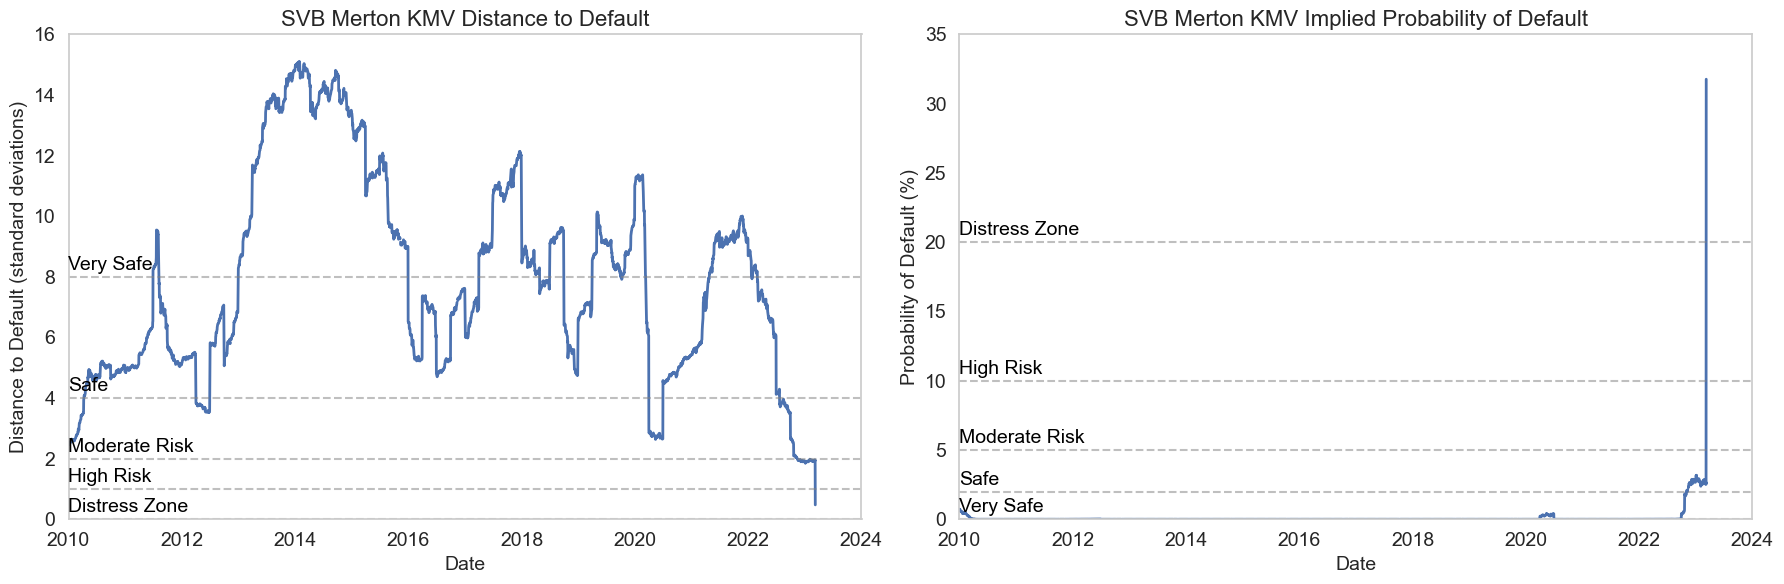

In [166]:
# import matplotlib.pyplot as plt

# plot_df = merton_panel[['date', 'DD_kmv', 'PD_kmv']].copy()
# plot_df = plot_df.sort_values('date')
# plot_df['PD_pct'] = plot_df['PD_kmv'] * 100

# # --- Distance to Default ---
# plt.figure(figsize=(12, 8))
# plt.plot(plot_df['date'], plot_df['DD_kmv'], label='Merton KMV DD', linewidth=2)

# for y, label in [
#     (8,  'Very Safe'),
#     (4,  'Safe'),
#     (2,  'Moderate Risk'),
#     (1,  'High Risk'),
#     (0,  'Distress Zone')
# ]:
#     plt.axhline(y, color='gray', linestyle='--', alpha=0.5)
#     plt.text(plot_df['date'].min(), y + 0.1, label, color='black', fontsize=14)

# # plt.axvline(pd.Timestamp('2023-03-10'), color='red', linestyle='--')
# plt.title('SVB Merton KMV Distance to Default with Risk Thresholds', fontsize=16)
# plt.ylabel('Distance to Default (standard deviations)', fontsize=14)
# plt.xlabel('Date', fontsize=14)
# plt.xticks(fontsize=14)
# plt.yticks(fontsize=14)
# plt.ylim(0, 16)
# plt.grid(False)
# plt.show()

# # --- Probability of Default ---
# plt.figure(figsize=(12,8))
# plt.plot(plot_df['date'], plot_df['PD_pct'], label='Merton KMV PD (1 year)', linewidth=2)

# for y, label in [
#     (0,  'Very Safe'),
#     (2,    'Safe'),
#     (5,    'Moderate Risk'),
#     (10,   'High Risk'),
#     (20,   'Distress Zone')
# ]:
#     plt.axhline(y, color='gray', linestyle='--', alpha=0.5)
#     plt.text(plot_df['date'].min(), y + 0.2, label, color='black', fontsize=14)

# # plt.axvline(pd.Timestamp('2023-03-10'), color='red', linestyle='--')
# plt.title('SVB Merton KMV Implied Probability of Default with Risk Thresholds', fontsize=16)
# plt.ylabel('Probability of Default (%)', fontsize=14)
# plt.xlabel('Date', fontsize=14)
# plt.xticks(fontsize=14)
# plt.yticks(fontsize=14)
# plt.ylim(0, 35)
# plt.grid(False)
# plt.show()

import pandas as pd
import matplotlib.pyplot as plt

plot_df = merton_panel[["date", "DD_kmv", "PD_kmv"]].copy()
plot_df["date"] = pd.to_datetime(plot_df["date"], errors="coerce")
plot_df = plot_df.dropna(subset=["date"]).sort_values("date")
plot_df["PD_pct"] = plot_df["PD_kmv"] * 100

# same xlim as before
x0 = pd.Timestamp("2010-01-01")
x1 = pd.Timestamp("2024-01-01")

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(18, 6), dpi=100, sharex=True)

# --- Distance to Default ---
ax1.plot(plot_df["date"], plot_df["DD_kmv"], label="Merton KMV DD", linewidth=2)

for y, label in [
    (8,  "Very Safe"),
    (4,  "Safe"),
    (2,  "Moderate Risk"),
    (1,  "High Risk"),
    (0,  "Distress Zone"),
]:
    ax1.axhline(y, color="gray", linestyle="--", alpha=0.5)
    ax1.text(x0, y + 0.1, label, color="black", fontsize=14, va="bottom")

ax1.set_title("SVB Merton KMV Distance to Default", fontsize=16)
ax1.set_ylabel("Distance to Default (standard deviations)", fontsize=14)
ax1.set_xlabel("Date", fontsize=14)
ax1.tick_params(axis="both", labelsize=14)
ax1.set_ylim(0, 16)
ax1.set_xlim(x0, x1)
ax1.grid(False)

# --- Probability of Default ---
ax2.plot(plot_df["date"], plot_df["PD_pct"], label="Merton KMV PD (1 year)", linewidth=2)

for y, label in [
    (0,  "Very Safe"),
    (2,  "Safe"),
    (5,  "Moderate Risk"),
    (10, "High Risk"),
    (20, "Distress Zone"),
]:
    ax2.axhline(y, color="gray", linestyle="--", alpha=0.5)
    ax2.text(x0, y + 0.2, label, color="black", fontsize=14, va="bottom")

ax2.set_title("SVB Merton KMV Implied Probability of Default", fontsize=16)
ax2.set_ylabel("Probability of Default (%)", fontsize=14)
ax2.set_xlabel("Date", fontsize=14)
ax2.tick_params(axis="both", labelsize=14)
ax2.set_ylim(0, 35)
ax2.set_xlim(x0, x1)
ax2.grid(False)

plt.tight_layout()
plt.show()


In [167]:
import pandas as pd

# ---------- Moody's Issuer Rating ----------
moody_issuer = pd.DataFrame({
    "date": [
        "2002-06-17",
        "2007-03-03",
        "2023-03-08",
        "2023-03-10",
        "2023-03-13",
    ],
    "agency": "Moody's",
    "rating_type": "Issuer",
    "rating": ["Baa1", "A3", "Baa1", "C", "WR"],
})

# ---------- S&P LT Local Issuer Credit ----------
sp_local_issuer = pd.DataFrame({
    "date": [
        "2003-12-08",
        "2006-01-12",
        "2006-02-13",
        "2010-12-20",
        "2014-07-08",
        "2023-03-09",
        "2023-03-10",
        "2023-03-11",
    ],
    "agency": "S&P",
    "rating_type": "LT Local Issuer Credit",
    "rating": ["BBB-", "BBB-", "BBB", "BBB+", "BBB", "BBB-", "CC", "NR"],
})

# ---------- Bloomberg Composite (Issuer) Rating ----------
bbg_composite = pd.DataFrame({
    "date": [
        "2006-05-31",
        "2007-03-03",
        "2010-12-20",
        "2012-04-02",
        "2014-07-08",
        "2019-04-22",
        "2023-03-08",
        "2023-03-09",
        "2023-03-10",
        "2023-03-11",
        "2023-03-13",
    ],
    "agency": "Bloomberg",
    "rating_type": "Composite Issuer",
    "rating": ["BBB", "BBB+", "BBB+", "BBB+", "BBB+", "BBB+",
               "BBB", "BBB", "C+", "NR", "NR"],
})

# ---------- Combine all ----------
ratings_all = (
    pd.concat([moody_issuer, sp_local_issuer, bbg_composite], ignore_index=True)
      .assign(date=lambda d: pd.to_datetime(d["date"]))
      .sort_values(["date", "agency"])
)

print(ratings_all.head(15))


         date     agency             rating_type rating
0  2002-06-17    Moody's                  Issuer   Baa1
5  2003-12-08        S&P  LT Local Issuer Credit   BBB-
6  2006-01-12        S&P  LT Local Issuer Credit   BBB-
7  2006-02-13        S&P  LT Local Issuer Credit    BBB
13 2006-05-31  Bloomberg        Composite Issuer    BBB
14 2007-03-03  Bloomberg        Composite Issuer   BBB+
1  2007-03-03    Moody's                  Issuer     A3
15 2010-12-20  Bloomberg        Composite Issuer   BBB+
8  2010-12-20        S&P  LT Local Issuer Credit   BBB+
16 2012-04-02  Bloomberg        Composite Issuer   BBB+
17 2014-07-08  Bloomberg        Composite Issuer   BBB+
9  2014-07-08        S&P  LT Local Issuer Credit    BBB
18 2019-04-22  Bloomberg        Composite Issuer   BBB+
19 2023-03-08  Bloomberg        Composite Issuer    BBB
2  2023-03-08    Moody's                  Issuer   Baa1


In [168]:
import numpy as np
import pandas as pd

# ratings_all has: ['date', 'agency', 'rating_type', 'rating']

ratings_all['date'] = pd.to_datetime(ratings_all['date'])

# Clean up rating strings
ratings_all['rating_clean'] = (
    ratings_all['rating']
      .str.strip()
      .str.replace(r'\s+', '', regex=True)
      .str.upper()
)

# Common 0â€“20 notch scale, higher = safer
rating_scale = {
    # S&P style
    "AAA": 20,
    "AA+": 19, "AA": 18, "AA-": 17,
    "A+": 16, "A": 15, "A-": 14,
    "BBB+": 13, "BBB": 12, "BBB-": 11,
    "BB+": 10, "BB": 9, "BB-": 8,
    "B+": 7, "B": 6, "B-": 5,
    "CCC+": 4, "CCC": 3, "CCC-": 2,
    "CC": 1, "C": 1, "D": 0,

    # Moodyâ€™s style
    "AA1": 19, "AA2": 18, "AA3": 17,
    "A1": 16, "A2": 15, "A3": 14,
    "BAA1": 13, "BAA2": 12, "BAA3": 11,
    "BA1": 10, "BA2": 9, "BA3": 8,
    "B1": 7, "B2": 6, "B3": 5,
    "CAA1": 4, "CAA2": 3, "CAA3": 2,
    "CA": 1,

    # Bloomberg composite oddball
    "C+": 2,
}

# distinguish Moodyâ€™s "C" from S&P / Bloomberg "C" a bit
def normalize_key(row):
    r = row['rating_clean']
    ag = row['agency'].upper()

    if r == "C" and "MOODY" in ag:
        return "CA"       # Moodyâ€™s C / Ca bucket
    return r

ratings_all['rating_key'] = ratings_all.apply(normalize_key, axis=1)

ratings_all['rating_score'] = ratings_all['rating_key'].map(rating_scale)

# NR and WR are non rated or withdrawn
ratings_all.loc[
    ratings_all['rating_clean'].isin(["NR", "WR"]),
    'rating_score'
] = np.nan


In [169]:
def make_daily(df_group):
    df_group = df_group.sort_values('date')
    idx = pd.date_range(df_group['date'].min(),
                        df_group['date'].max(),
                        freq='D')
    ts = (
        df_group.set_index('date')[['rating_score']]
                .reindex(idx)
                .ffill()
    )
    ts['agency'] = df_group['agency'].iloc[0]
    ts['rating_type'] = df_group['rating_type'].iloc[0]
    ts = ts.reset_index().rename(columns={'index': 'date'})
    return ts

daily_list = [
    make_daily(sub)
    for (_, _), sub in ratings_all.groupby(['agency', 'rating_type'])
]

ratings_daily = pd.concat(daily_list, ignore_index=True)

# Wide format, one column per agency
ratings_wide = (
    ratings_daily
      .pivot_table(index='date', columns='agency', values='rating_score')
      .sort_index()
      .reset_index()
)

print(ratings_wide.head())


agency       date  Bloomberg  Moody's  S&P
0      2002-06-17        NaN     13.0  NaN
1      2002-06-18        NaN     13.0  NaN
2      2002-06-19        NaN     13.0  NaN
3      2002-06-20        NaN     13.0  NaN
4      2002-06-21        NaN     13.0  NaN


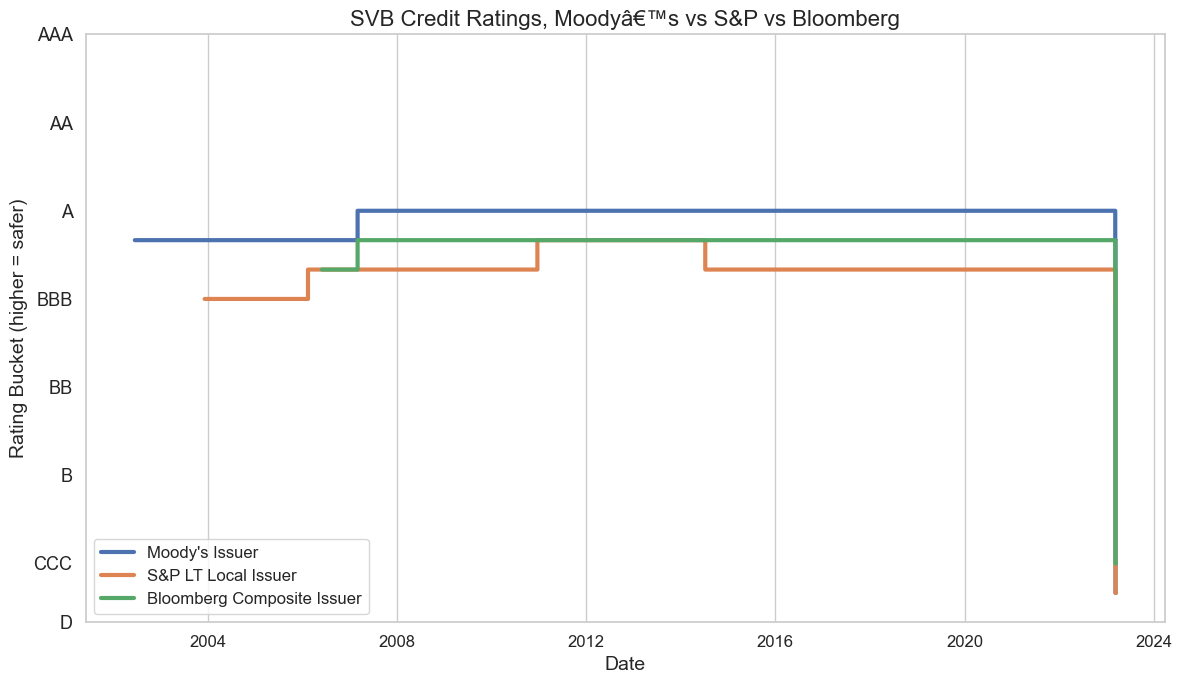

In [170]:
import matplotlib.pyplot as plt

fig, ax = plt.subplots(figsize=(12, 7))

# Plot the stepped ratings as before
for col, label in [
    ("Moody's", "Moody's Issuer"),
    ("S&P", "S&P LT Local Issuer"),
    ("Bloomberg", "Bloomberg Composite Issuer")
]:
    if col in ratings_wide.columns:
        ax.step(ratings_wide['date'], ratings_wide[col],
                where='post', label=label, linewidth=3)

# Simplified y-axis labels (broad buckets)
yticks = [20, 17, 14, 11, 8, 5, 2, 0]
ytick_labels = [
    "AAA",
    "AA",
    "A",
    "BBB",
    "BB",
    "B",
    "CCC",
    "D"
]

ax.set_yticks(yticks)
ax.set_yticklabels(ytick_labels, fontsize=13)

ax.set_xlabel("Date", fontsize=14)
ax.set_ylabel("Rating Bucket (higher = safer)", fontsize=14)
ax.set_title("SVB Credit Ratings, Moodyâ€™s vs S&P vs Bloomberg", fontsize=16)
ax.tick_params(axis='x', labelsize=12)
ax.grid(axis='y')
ax.legend(fontsize=12, loc='lower left')
# ax.axvline(pd.Timestamp("2023-03-10"), color='red', linestyle='--', alpha=0.7)

plt.tight_layout()
plt.show()

### 1.6 Assets Growth

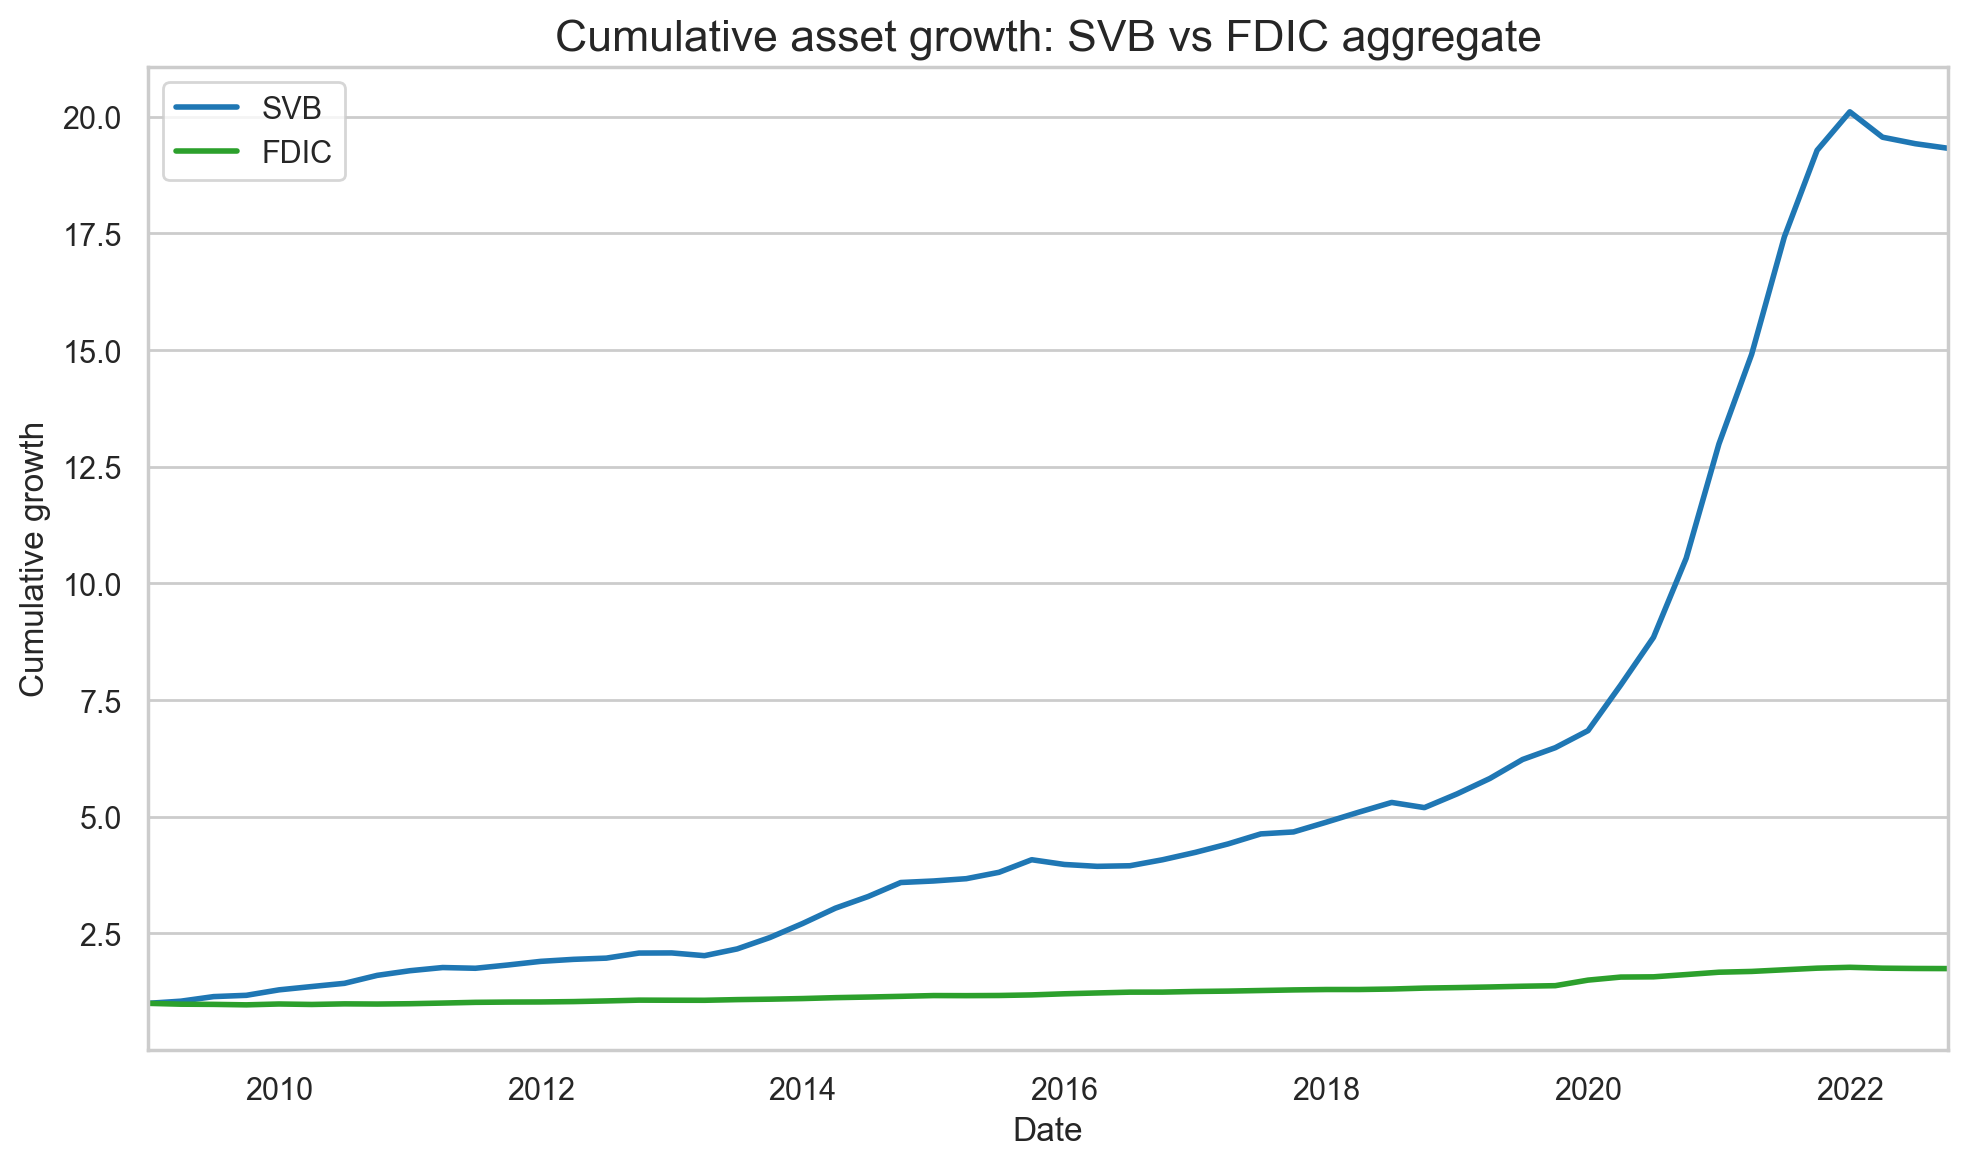

In [249]:
import pandas as pd
import matplotlib.pyplot as plt

# --- SVB vs FDIC cumulative asset growth (aligned window) ---
svb_assets = bs_data["TotalAssets"].copy()
fdic_assets = fdic_comp["TotalAssets"].copy()

start_date = pd.Timestamp("2009-01-01")

svb_assets  = svb_assets[svb_assets.index >= start_date]
fdic_assets = fdic_assets[fdic_assets.index >= svb_assets.index.min()]

assets = pd.concat({"SVB": svb_assets, "FDIC": fdic_assets}, axis=1).dropna()
cum_assets = assets / assets.iloc[0]

fig, ax = plt.subplots(figsize=(10, 6), dpi=200)

svb_color  = color_map.get("SVB", "tab:blue") if "color_map" in globals() else "tab:blue"
fdic_color = color_map.get("FDIC", "tab:green") if "color_map" in globals() else "tab:green"  # (was 'NBI' before)

cum_assets.plot(ax=ax, color=[svb_color, fdic_color], linewidth=2)

# ax.set_yscale("log")  # uncomment if you want log scale like code 2
ax.set_ylabel("Cumulative growth", fontsize=12)
ax.set_xlabel("Date", fontsize=12)
ax.set_title("Cumulative asset growth: SVB vs FDIC aggregate", fontsize=16)
ax.legend(loc="upper left")

ax.grid(axis='x')

plt.tight_layout()
plt.show()


In [187]:
import numpy as np
import pandas as pd
import statsmodels.api as sm

import sys


# -----------------------------
# User controls
# -----------------------------
BREAK_SAMPLE = 'winsorized'      # any key in SAMPLES (e.g., full, excl_covid, winsorized)
BREAK_SPEC = 'i_base'            # any spec key from SPEC_LIST; default is SVB ~ QQQ + NBI
BREAK_TRIM = 0.1
BREAK_MAX_BREAKS = 2
BREAK_STEP = 1                   # increase (e.g., 3/5) for faster 2-break search
BREAK_VERBOSE = True
BREAK_PROGRESS = True
BREAK_EXCLUDE_COVID = True
BREAK_CANDIDATE_START = pd.Timestamp('2018-01-01')
BREAK_CANDIDATE_END = None        # e.g., pd.Timestamp('2022-12-31')


def _progress_tick(i, total, label, last_pct):
    if total <= 0:
        return last_pct
    pct = int((i * 100) / total)
    if (pct >= last_pct + 2) or (i == total):
        sys.stdout.write(f"\r[{label}] {i}/{total} ({pct:3d}%)")
        sys.stdout.flush()
        return pct
    return last_pct


def _build_xy_from_spec(spec_key='i_base', sample_key='winsorized', exclude_covid=True):
    if 'SPEC_LIST' not in globals():
        raise NameError("SPEC_LIST not found. Run the regression setup cell(s) first.")

    spec_map = {name: (dep, rhs) for name, dep, rhs in SPEC_LIST}
    if spec_key not in spec_map:
        avail = ', '.join(spec_map.keys())
        raise KeyError(f"Spec '{spec_key}' not found in SPEC_LIST. Available: {avail}")

    dep, rhs = spec_map[spec_key]

    if 'SAMPLES' in globals() and isinstance(SAMPLES, dict) and (sample_key in SAMPLES):
        df_src = SAMPLES[sample_key].copy()
        source_name = f"SAMPLES['{sample_key}']"
    elif 'rets' in globals() and isinstance(rets, pd.DataFrame):
        df_src = rets.copy()
        source_name = 'rets'
    else:
        raise NameError("Could not find SAMPLES or rets. Run the pre-Old setup/regression cells first.")

    if 'prepare_rhs' in globals():
        df_work, rhs_eff = prepare_rhs(df_src, rhs)
    else:
        df_work = df_src.copy()
        rhs_eff = list(rhs)

    needed = [dep] + rhs_eff
    missing = [c for c in needed if c not in df_work.columns]
    if missing:
        raise KeyError(f"Spec '{spec_key}' requires missing columns: {missing}")

    XY = df_work[needed].copy()

    if exclude_covid:
        covid_start = globals().get('COVID_START', pd.to_datetime('2020-02-15'))
        covid_end = globals().get('COVID_END', pd.to_datetime('2020-04-15'))
        idx = pd.to_datetime(XY.index)
        XY = XY.loc[~((idx >= pd.to_datetime(covid_start)) & (idx <= pd.to_datetime(covid_end)))]

    XY = XY.dropna()
    if XY.empty:
        raise ValueError('No observations left after NA filtering and sample restrictions.')

    y = XY[dep]
    X = sm.add_constant(XY[rhs_eff], has_constant='add')

    meta = {
        'source': source_name,
        'spec_key': spec_key,
        'spec_label': globals().get('spec_labels', {}).get(spec_key, spec_key),
        'dep': dep,
        'rhs': rhs_eff,
        'sample': sample_key,
        'exclude_covid': bool(exclude_covid),
        'n_obs': int(XY.shape[0]),
    }
    return y, X, meta


def find_structural_breaks(
    y, X, trim=0.15, max_breaks=2, step=1, verbose=True, progress=True,
    candidate_start=None, candidate_end=None
):
    y = pd.Series(y)
    X = pd.DataFrame(X)

    if y.empty or X.empty:
        raise ValueError('y and X must be non-empty.')

    data = pd.concat([y.rename('y'), X], axis=1).dropna()
    if data.empty:
        raise ValueError('No valid observations after aligning y and X and dropping NA.')

    yv = data['y'].to_numpy(dtype=float)
    Xv = data[X.columns].to_numpy(dtype=float)
    dates_aligned = pd.to_datetime(data.index)

    candidate_start = pd.to_datetime(candidate_start) if candidate_start is not None else None
    candidate_end = pd.to_datetime(candidate_end) if candidate_end is not None else None

    def in_window(i):
        dt = pd.Timestamp(dates_aligned[i])
        if (candidate_start is not None) and (dt < candidate_start):
            return False
        if (candidate_end is not None) and (dt > candidate_end):
            return False
        return True

    n = yv.shape[0]
    k = Xv.shape[1]
    step = max(int(step), 1)

    min_seg = int(np.floor(trim * n))
    min_seg = max(min_seg, 1)

    if n <= k:
        raise ValueError('Not enough observations relative to regressors.')

    if verbose:
        print(f'[breaks] n={n}, k={k}, trim={trim}, min_seg={min_seg}, step={step}, max_breaks={max_breaks}')
        print(f'[breaks] candidate window: start={candidate_start}, end={candidate_end}')

    rss_cache = {}

    def seg_rss(i0, i1):
        key = (i0, i1)
        if key in rss_cache:
            return rss_cache[key]

        ys = yv[i0:i1]
        Xs = Xv[i0:i1, :]

        if ys.shape[0] <= k:
            rss_cache[key] = np.inf
            return np.inf

        res = sm.OLS(ys, Xs).fit()
        rss = float(np.sum(res.resid ** 2))
        rss_cache[key] = rss
        return rss

    rss_no_break = seg_rss(0, n)

    def bic_from_rss(rss):
        rss = max(float(rss), 1e-12)
        return float(n * np.log(rss / n) + k * np.log(n))

    best_1 = None
    bic_1 = None

    one_break_candidates = [
        i for i in range(min_seg, n - min_seg + 1, step)
        if in_window(i)
    ]
    if verbose:
        print(f'[breaks] 1-break candidates: {len(one_break_candidates)}')
        if len(one_break_candidates) > 0:
            dmin = pd.Timestamp(dates_aligned[min(one_break_candidates)]).date()
            dmax = pd.Timestamp(dates_aligned[max(one_break_candidates)]).date()
            print(f'[breaks] 1-break candidate dates: {dmin} -> {dmax}')

    if one_break_candidates and max_breaks >= 1:
        best_rss_1 = np.inf
        best_i = None

        total1 = len(one_break_candidates)
        pct1 = -1
        for pos, i in enumerate(one_break_candidates, start=1):
            rss_tot = seg_rss(0, i) + seg_rss(i, n)
            if rss_tot < best_rss_1:
                best_rss_1 = rss_tot
                best_i = i
            if progress:
                pct1 = _progress_tick(pos, total1, '1-break', pct1)
        if progress and total1 > 0:
            print()

        if best_i is not None and np.isfinite(best_rss_1):
            best_1 = {
                'break_date': pd.Timestamp(dates_aligned[best_i]),
                'rss': float(best_rss_1),
                'n1': int(best_i),
                'n2': int(n - best_i),
            }
            bic_1 = bic_from_rss(best_rss_1)

    best_2 = None
    bic_2 = None

    if max_breaks >= 2 and n >= 3 * min_seg:
        first_candidates = [
            i for i in range(min_seg, n - 2 * min_seg + 1, step)
            if in_window(i)
        ]
        if verbose:
            approx_pairs = 0
            for i in first_candidates:
                j_start = i + min_seg
                j_end = n - min_seg
                if j_start <= j_end:
                    cand_j = [j for j in range(j_start, j_end + 1, step) if in_window(j)]
                    approx_pairs += len(cand_j)
            print(f'[breaks] 2-break first-loop candidates: {len(first_candidates)}')
            if len(first_candidates) > 0:
                dmin2 = pd.Timestamp(dates_aligned[min(first_candidates)]).date()
                dmax2 = pd.Timestamp(dates_aligned[max(first_candidates)]).date()
                print(f'[breaks] 2-break first-break candidate dates: {dmin2} -> {dmax2}')
            print(f'[breaks] 2-break approx evaluated pairs: {approx_pairs}')

        best_rss_2 = np.inf
        best_pair = None

        total2 = len(first_candidates)
        pct2 = -1
        for pos, i in enumerate(first_candidates, start=1):
            j_start = i + min_seg
            j_end = n - min_seg
            if j_start <= j_end:
                second_candidates = [j for j in range(j_start, j_end + 1, step) if in_window(j)]
                for j in second_candidates:
                    rss_tot = seg_rss(0, i) + seg_rss(i, j) + seg_rss(j, n)
                    if rss_tot < best_rss_2:
                        best_rss_2 = rss_tot
                        best_pair = (i, j)
            if progress:
                pct2 = _progress_tick(pos, total2, '2-break', pct2)
        if progress and total2 > 0:
            print()

        if best_pair is not None and np.isfinite(best_rss_2):
            i, j = best_pair
            best_2 = {
                'break_dates': (pd.Timestamp(dates_aligned[i]), pd.Timestamp(dates_aligned[j])),
                'rss': float(best_rss_2),
                'n1': int(i),
                'n2': int(j - i),
                'n3': int(n - j),
            }
            bic_2 = bic_from_rss(best_rss_2)

    if candidate_start is not None:
        if (best_1 is not None) and (pd.Timestamp(best_1['break_date']) < candidate_start):
            raise RuntimeError(f"Window violation for best_1: {best_1['break_date']} < {candidate_start}")
        if (best_2 is not None):
            d1, d2 = best_2['break_dates']
            if pd.Timestamp(d1) < candidate_start or pd.Timestamp(d2) < candidate_start:
                raise RuntimeError(f"Window violation for best_2: {(d1, d2)} below {candidate_start}")

    if candidate_end is not None:
        if (best_1 is not None) and (pd.Timestamp(best_1['break_date']) > candidate_end):
            raise RuntimeError(f"Window violation for best_1: {best_1['break_date']} > {candidate_end}")
        if (best_2 is not None):
            d1, d2 = best_2['break_dates']
            if pd.Timestamp(d1) > candidate_end or pd.Timestamp(d2) > candidate_end:
                raise RuntimeError(f"Window violation for best_2: {(d1, d2)} above {candidate_end}")

    return {
        'best_1': best_1,
        'best_2': best_2,
        'rss_no_break': float(rss_no_break),
        'bic_no_break': bic_from_rss(rss_no_break),
        'bic_1': bic_1,
        'bic_2': bic_2,
    }



# Build y/X from chosen spec and run break search
y, X, break_meta = _build_xy_from_spec(
    spec_key=BREAK_SPEC,
    sample_key=BREAK_SAMPLE,
    exclude_covid=BREAK_EXCLUDE_COVID,
)

if BREAK_VERBOSE:
    print('[breaks] Input selection')
    print(f"  source      : {break_meta['source']}")
    print(f"  sample      : {break_meta['sample']}")
    print(f"  spec        : {break_meta['spec_key']} -> {break_meta['spec_label']}")
    print(f"  dependent   : {break_meta['dep']}")
    print(f"  regressors  : {break_meta['rhs']}")
    print(f"  exclude covid window: {break_meta['exclude_covid']}")
    print(f"  n_obs       : {break_meta['n_obs']}")

active_candidate_start = pd.to_datetime(BREAK_CANDIDATE_START) if BREAK_CANDIDATE_START is not None else None
active_candidate_end = pd.to_datetime(BREAK_CANDIDATE_END) if BREAK_CANDIDATE_END is not None else None
if BREAK_VERBOSE:
    print(f"[breaks] active window pre-call: start={active_candidate_start}, end={active_candidate_end}")

break_results = find_structural_breaks(
    y,
    X,
    trim=BREAK_TRIM,
    max_breaks=BREAK_MAX_BREAKS,
    step=BREAK_STEP,
    verbose=BREAK_VERBOSE,
    progress=BREAK_PROGRESS,
    candidate_start=active_candidate_start,
    candidate_end=active_candidate_end,
)

print('\nStructural break search (OLS, RSS minimization)')
print(f"No break: RSS={break_results['rss_no_break']:.6f}, BIC={break_results['bic_no_break']:.6f}")

if break_results['best_1'] is None:
    print('Best 1 break: not feasible under current trim/sample.')
else:
    b1 = break_results['best_1']
    print(
        f"Best 1 break: {b1['break_date'].date()} | RSS={b1['rss']:.6f}, "
        f"BIC={break_results['bic_1']:.6f} | n=({b1['n1']}, {b1['n2']})"
    )

if break_results['best_2'] is None:
    print('Best 2 breaks: not feasible under current trim/sample.')
else:
    b2 = break_results['best_2']
    d1, d2 = b2['break_dates']
    print(
        f"Best 2 breaks: ({d1.date()}, {d2.date()}) | RSS={b2['rss']:.6f}, "
        f"BIC={break_results['bic_2']:.6f} | n=({b2['n1']}, {b2['n2']}, {b2['n3']})"
    )


[breaks] Input selection
  source      : SAMPLES['winsorized']
  sample      : winsorized
  spec        : i_base -> (i) Spec: SVB ~ QQQ + NBI
  dependent   : SVB
  regressors  : ['QQQ', 'NBI']
  exclude covid window: True
  n_obs       : 3252
[breaks] active window pre-call: start=2018-01-01 00:00:00, end=None
[breaks] n=3252, k=3, trim=0.1, min_seg=325, step=1, max_breaks=2
[breaks] candidate window: start=2018-01-01 00:00:00, end=None
[breaks] 1-break candidates: 931
[breaks] 1-break candidate dates: 2018-01-02 -> 2021-11-19
[1-break] 931/931 (100%)
[breaks] 2-break first-loop candidates: 606
[breaks] 2-break first-break candidate dates: 2018-01-02 -> 2020-08-03
[breaks] 2-break approx evaluated pairs: 183921
[2-break] 606/606 (100%)

Structural break search (OLS, RSS minimization)
No break: RSS=0.493594, BIC=-28570.796526
Best 1 break: 2018-06-19 | RSS=0.482503, BIC=-28644.700777 | n=(2113, 1139)
Best 2 breaks: (2019-12-23, 2021-07-09) | RSS=0.475738, BIC=-28690.617047 | n=(2490, 34


================ 1-BREAK SWITCHING REGRESSIONS ================

Regime 1 | 2010-01-05 -> 2018-06-18 | n=2113
                            OLS Regression Results                            
Dep. Variable:                      y   R-squared:                       0.712
Model:                            OLS   Adj. R-squared:                  0.712
Method:                 Least Squares   F-statistic:                     1618.
Date:                Sun, 22 Feb 2026   Prob (F-statistic):               0.00
Time:                        14:56:22   Log-Likelihood:                 6586.3
No. Observations:                2113   AIC:                        -1.317e+04
Df Residuals:                    2110   BIC:                        -1.315e+04
Df Model:                           2                                         
Covariance Type:                  HAC                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
--------------------

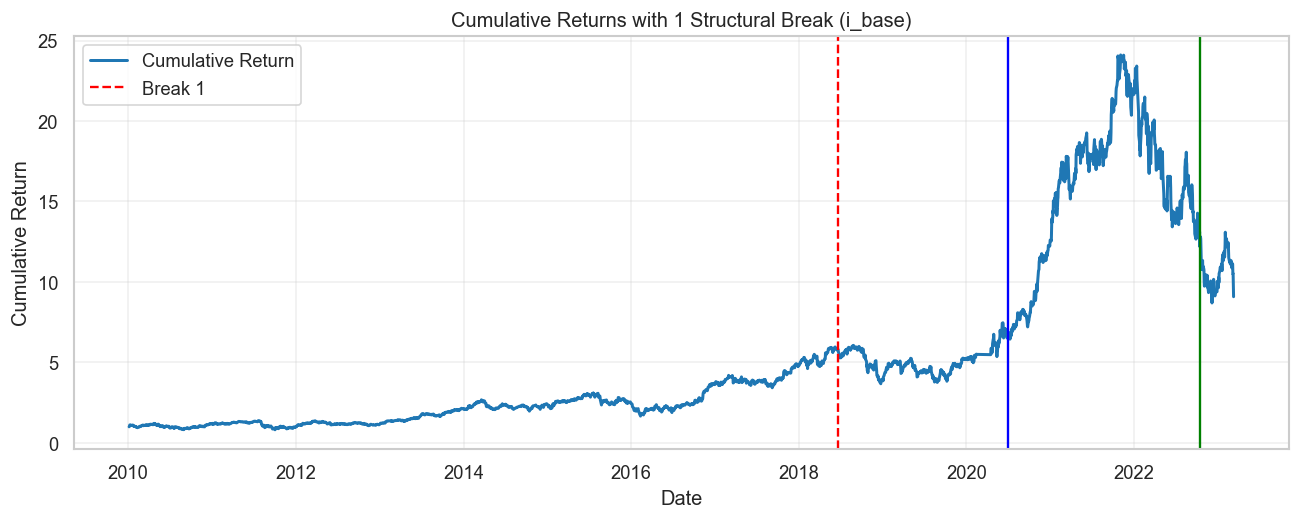


================ 2-BREAK SWITCHING REGRESSIONS ================

Regime 1 | 2010-01-05 -> 2019-12-20 | n=2490
                            OLS Regression Results                            
Dep. Variable:                      y   R-squared:                       0.712
Model:                            OLS   Adj. R-squared:                  0.711
Method:                 Least Squares   F-statistic:                     1930.
Date:                Sun, 22 Feb 2026   Prob (F-statistic):               0.00
Time:                        14:56:22   Log-Likelihood:                 7714.7
No. Observations:                2490   AIC:                        -1.542e+04
Df Residuals:                    2487   BIC:                        -1.541e+04
Df Model:                           2                                         
Covariance Type:                  HAC                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
--------------------

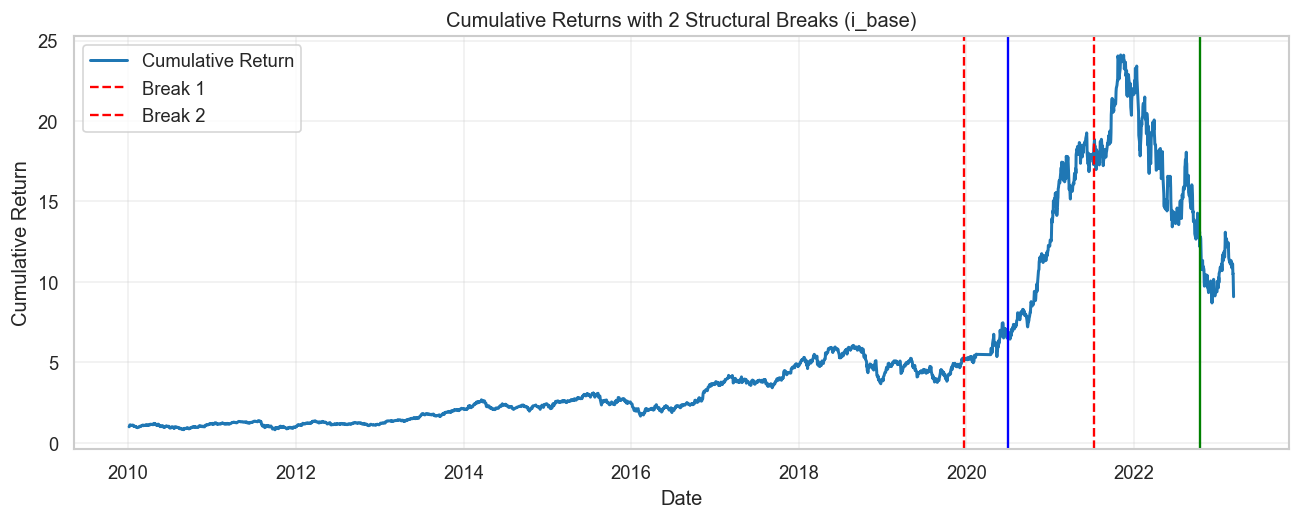

In [192]:
# --- Cumulative return plots with detected break dates ---
import pandas as pd
import matplotlib.pyplot as plt

# y is the dependent stock return series already built in your cell
cum_ret = (1 + pd.Series(y).dropna()).cumprod()

def plot_cumret_with_breaks(cum_series, break_dates, title):
    plt.figure(figsize=(11, 4.5), dpi=120)
    plt.plot(cum_series.index, cum_series.values, color='tab:blue', linewidth=1.8, label='Cumulative Return')
    for j, dt in enumerate(break_dates, start=1):
        plt.axvline(pd.to_datetime(dt), color='red', linestyle='--', linewidth=1.4, label=f'Break {j}')
    plt.axvline(pd.to_datetime("2020-07-01"), color='blue', linestyle='-', linewidth=1.4)
    plt.axvline(pd.to_datetime("2022-10-15"), color='green', linestyle='-', linewidth=1.4)
    plt.title(title)
    plt.xlabel('Date')
    plt.ylabel('Cumulative Return')
    plt.grid(alpha=0.3)
    plt.legend(loc='upper left')
    plt.tight_layout()
    plt.show()

import statsmodels.api as sm
import pandas as pd

# Align exactly as break search did
data = pd.concat([pd.Series(y, name='y'), pd.DataFrame(X)], axis=1).dropna()

def print_segment_regression(i0, i1, label):
    ys = data['y'].iloc[i0:i1]
    Xs = data.drop(columns='y').iloc[i0:i1]
    m = sm.OLS(ys, Xs).fit(cov_type='HAC', cov_kwds={'maxlags': 5})
    print(f"\n{label} | {ys.index.min().date()} -> {ys.index.max().date()} | n={len(ys)}")
    print(m.summary())

# 1-break switching regressions
if break_results.get('best_1') is not None:
    i = int(break_results['best_1']['n1'])
    print("\n================ 1-BREAK SWITCHING REGRESSIONS ================")
    print_segment_regression(0, i, "Regime 1")
    print_segment_regression(i, len(data), "Regime 2")

# 1-break cumulative return plot
if break_results.get('best_1') is not None:
    b1_date = break_results['best_1']['break_date']
    plot_cumret_with_breaks(
        cum_ret,
        [b1_date],
        f"Cumulative Returns with 1 Structural Break ({break_meta['spec_key']})"
    )

# 2-break switching regressions
if break_results.get('best_2') is not None:
    i = int(break_results['best_2']['n1'])
    j = int(break_results['best_2']['n1'] + break_results['best_2']['n2'])
    print("\n================ 2-BREAK SWITCHING REGRESSIONS ================")
    print_segment_regression(0, i, "Regime 1")
    print_segment_regression(i, j, "Regime 2")
    print_segment_regression(j, len(data), "Regime 3")

# 2-break cumulative return plot
if break_results.get('best_2') is not None:
    b2_date_1, b2_date_2 = break_results['best_2']['break_dates']
    plot_cumret_with_breaks(
        cum_ret,
        [b2_date_1, b2_date_2],
        f"Cumulative Returns with 2 Structural Breaks ({break_meta['spec_key']})"
    )




## Old

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import statsmodels.api as sm
import seaborn as sns
from scipy.stats import chi2
sns.set_theme(context="notebook", style="whitegrid")

def add_covid_shade(ax):
    ax.axvspan(pd.to_datetime("2020-02-15"), pd.to_datetime("2020-04-15"),
               color='grey', alpha=0.15)

def format_regression_table(model, title="Baseline regression"):
    rows = []
    for p, b, se, tval in zip(model.params.index,
                              model.params.values,
                              model.bse.values,
                              model.tvalues.values):
        rows.append({
            "Variable": p,
            "Coef": f"{b:.3f}",
            "t-stat": f"{tval:.2f}"
        })
    table = pd.DataFrame(rows).set_index("Variable")
    print(f"\n{title}\n")
    display(table)
    return table
    # small helper for HAC OLS
def fit_ols_hac(X, y, title=None):
    res = sm.OLS(y, X).fit(cov_type='HAC', cov_kwds={'maxlags':5})
    if title:
        print(f"\n=== {title} ===")
        print(res.summary())
    return res

# regime dummies
def regime_dummies(index, b1, b2=None):
    d = pd.DataFrame(index=index)
    if b2 is None:
        d['Pre-2020-07']  = (index < b1).astype(int)
        d['Post-2020-07'] = (index >= b1).astype(int)
        return d, ['Pre-2020-07','Post-2020-07']
    d['Pre-2020-07']         = (index < b1).astype(int)
    d['2020-07 to 2022-10']  = ((index >= b1) & (index < b2)).astype(int)
    d['Post-2022-10']        = (index >= b2).astype(int)
    return d, ['Pre-2020-07','2020-07 to 2022-10','Post-2022-10']

# build interaction design
def build_X_interactions(Xb, R, cols_order):
    X = Xb.copy()
    for r in cols_order[1:]:  # baseline is first regime, keep plain betas as baseline
        for col in Xb.columns:
            X[f'{col}_x_{r}'] = Xb[col].values * R[r].values
    return X

def regime_fit_stats(Y, X_base, tab, regimes, R):
    """
    Compute regime-specific adjusted RÂ² and number of observations.
    - Y: dependent series
    - X_base: base regressors with const
    - tab: DataFrame of betas/se/t for all regimes
    - regimes: list of regime labels
    - R: dummy DataFrame with regime indicators
    """
    results = []
    for r in regimes:
        mask = R[r] == 1
        y_sub = Y.loc[mask]
        X_sub = X_base.loc[mask]

        # extract betas for this regime
        sub_tab = tab[tab['regime'] == r].set_index('var')
        betas = sub_tab['coef'].reindex(X_sub.columns).values

        # predictions and residuals
        y_hat = X_sub.values @ betas
        resid = y_sub.values - y_hat

        ss_res = np.sum(resid**2)
        ss_tot = np.sum((y_sub - y_sub.mean())**2)
        r2 = 1 - ss_res/ss_tot if ss_tot > 0 else np.nan

        n = len(y_sub)
        k = X_sub.shape[1] - 1   # exclude const
        adj_r2 = 1 - (1-r2) * (n-1)/(n-k-1) if n > k+1 else np.nan

        results.append({
            "Regime": r,
            "Obs": n,
            "Adj_R2": round(adj_r2, 3)
        })
    return pd.DataFrame(results).set_index("Regime")


# delta-method extraction of full betas, SEs, t-stats per regime
def extract_full_betas(res, Xb_cols, regimes):
    P = res.params
    V = res.cov_params()
    rows = []
    for col in Xb_cols:  # includes 'const'
        # Jacobian mapping params -> full betas for each regime
        J = []
        labels = []
        # baseline
        j0 = np.zeros(len(P))
        j0[P.index.get_loc(col)] = 1.0
        J.append(j0); labels.append(f'{col}:{regimes[0]}')
        # others
        for r in regimes[1:]:
            jr = np.zeros(len(P))
            jr[P.index.get_loc(col)] = 1.0
            iname = f'{col}_x_{r}'
            if iname in P.index:
                jr[P.index.get_loc(iname)] = 1.0
            J.append(jr); labels.append(f'{col}:{r}')
        J = np.vstack(J)
        b = J @ P.values
        C = J @ V.values @ J.T
        se = np.sqrt(np.diag(C))
        t = b / se
        for lab, bi, sei, ti in zip(labels, b, se, t):
            var, reg = lab.split(':')
            rows.append({'var': var, 'regime': reg, 'coef': bi, 'se': sei, 't': ti})
    out = pd.DataFrame(rows)
    return out

# Wald equality of full betas across regimes (per var)
def wald_equal_betas(res, Xb_cols, regimes):
    P = res.params; V = res.cov_params()
    out = {}
    for col in Xb_cols:
        # Build Jacobian as above
        J = []
        j0 = np.zeros(len(P)); j0[P.index.get_loc(col)] = 1.0
        J.append(j0)
        for r in regimes[1:]:
            jr = np.zeros(len(P)); jr[P.index.get_loc(col)] = 1.0
            iname = f'{col}_x_{r}'
            if iname in P.index: jr[P.index.get_loc(iname)] = 1.0
            J.append(jr)
        J = np.vstack(J)
        b = J @ P.values
        C = J @ V.values @ J.T
        if len(regimes) > 1:
            Rm = []
            for k in range(1, len(regimes)):
                row = np.zeros(len(regimes)); row[k] = 1.0; row[0] = -1.0
                Rm.append(row)
            Rm = np.vstack(Rm)
            Rc = Rm @ C @ Rm.T
            stat = float((Rm @ b).T @ np.linalg.inv(Rc) @ (Rm @ b))
            df = Rm.shape[0]; pval = chi2.sf(stat, df)
        else:
            stat = np.nan; df = 0; pval = np.nan
        out[col] = (stat, df, pval, b)
    return out

# short Wald test print
def print_wald_short(wald, label):
    print(f"\nWald equality tests across regimes [{label}]")
    for var, (stat, df_, pval, bvec) in wald.items():
        print(f"  {var}: chi2({df_}) = {stat:.2f}, p = {pval:.4g}")

# table print
from IPython.display import display

def make_table(df, title):
    wide_rows = []
    for var in df['var'].unique():
        sub = df[df['var']==var].copy()
        row = {'var': var}
        for _, r in sub.iterrows():
            row[r['regime']] = f"{r['coef']:.3f} ({r['t']:.2f})"
        wide_rows.append(row)
    table = pd.DataFrame(wide_rows).set_index('var')
    print(f"\n{title}\n")
    display(table)   # <- displays nicely in notebooks
    return table

# Pairwise Wald tests of full betas across regimes (per var)
def wald_pairwise_betas(res, Xb_cols, regimes):
    """
    For each variable, perform pairwise Wald tests of equality
    between all regime-specific betas.

    Returns
    -------
    dict : {var: [(reg1, reg2, stat, pval), ...]}
    """
    P = res.params; V = res.cov_params()
    out = {}
    for col in Xb_cols:
        # Build Jacobian for full betas per regime
        J = []
        j0 = np.zeros(len(P)); j0[P.index.get_loc(col)] = 1.0
        J.append(j0)
        for r in regimes[1:]:
            jr = np.zeros(len(P)); jr[P.index.get_loc(col)] = 1.0
            iname = f'{col}_x_{r}'
            if iname in P.index: jr[P.index.get_loc(iname)] = 1.0
            J.append(jr)
        J = np.vstack(J)
        b = J @ P.values
        C = J @ V.values @ J.T

        # Pairwise restrictions
        results = []
        for i in range(len(regimes)):
            for j in range(i+1, len(regimes)):
                R = np.zeros(len(regimes)); R[i] = 1; R[j] = -1
                diff = R @ b
                var = R @ C @ R.T
                if var > 0:
                    stat = float(diff**2 / var)
                    pval = chi2.sf(stat, 1)
                else:
                    stat, pval = np.nan, np.nan
                results.append((regimes[i], regimes[j], stat, pval))
        out[col] = results
    return out

def print_wald_pairwise(wald_pw, label):
    print(f"\nPairwise Wald tests across regimes [{label}]")
    for var, tests in wald_pw.items():
        print(f"  {var}:")
        for r1, r2, stat, pval in tests:
            print(f"    {r1} vs {r2}: chi2(1) = {stat:.2f}, p = {pval:.4g}")

def regime_dummies(index, b1, b2=None):
    d = pd.DataFrame(index=index)
    if b2 is None:
        pre = f"Pre-{b1.date()}"
        post = f"Post-{b1.date()}"
        d[pre]  = (index < b1).astype(int)
        d[post] = (index >= b1).astype(int)
        return d, [pre, post]
    r1 = f"Pre-{b1.date()}"
    r2 = f"{b1.date()} to {b2.date()}"
    r3 = f"Post-{b2.date()}"
    d[r1] = (index < b1).astype(int)
    d[r2] = ((index >= b1) & (index < b2)).astype(int)
    d[r3] = (index >= b2).astype(int)
    return d, [r1, r2, r3]

In [ ]:
import requests
import pandas as pd

def get_svb_afs_htm(cik="0000719739"):
    url = f"https://data.sec.gov/api/xbrl/companyfacts/CIK{cik}.json"
    headers = {"User-Agent": "Niccolo Comati ncomati@mit.edu"}
    data = requests.get(url, headers=headers).json()
    facts = data["facts"]["us-gaap"]

    # Candidate tags for each bucket
    tag_map = {
        "afs_fv": [
            "AvailableForSaleSecurities",
            "DebtSecuritiesAvailableForSaleFairValue",
            "AvailableForSaleSecuritiesContinuousUnrealizedLossPositionFairValue",
        ],
        "afs_ac": [
            "AvailableForSaleSecuritiesAmortizedCost",
            "AvailableForSaleDebtSecuritiesAmortizedCostBasis",
        ],
        "htm_fv": [
            "HeldToMaturitySecuritiesFairValue",
            "DebtSecuritiesHeldToMaturityFairValue",
            "HeldToMaturitySecuritiesContinuousUnrealizedLossPositionFairValue",
        ],
        "htm_ac": [
            "HeldToMaturitySecuritiesAmortizedCostBeforeOtherThanTemporaryImpairment",
            "HeldToMaturitySecuritiesDebtMaturitiesAfterTenYearsNetCarryingAmount",  # sometimes used
        ],
    }

    # Collect records
    records = []
    for bucket, candidates in tag_map.items():
        for tag in candidates:
            if tag in facts and "USD" in facts[tag]["units"]:
                for entry in facts[tag]["units"]["USD"]:
                    records.append({
                        "bucket": bucket,
                        "tag": tag,
                        "fy": entry.get("fy"),
                        "fp": entry.get("fp"),
                        "end": entry.get("end"),
                        "val": entry.get("val"),
                    })

    df = pd.DataFrame(records)

    # Collapse to one value per bucket per period: keep the first non-null
    df = df.sort_values(["end", "bucket", "tag"])
    pivot = (
        df.pivot_table(index=["fy", "fp", "end"], columns="bucket", values="val", aggfunc="first")
        .reset_index()
        .sort_values("end")
    )

    return pivot

# Example usage
df = get_svb_afs_htm()
pd.set_option("display.float_format", "{:,.0f}".format)
df

### 1. No Rates (FEDFUNDS)

In [ ]:
# ---------- Load and reshape ----------
df = pd.read_excel(r"data/Input/SVB/Equity_Mkt_Data.xlsx", skiprows=[1,2])
df = df.rename(columns={'Unnamed: 0': 'Date', 'SIVBQ US Equity': 'SVB', 'Unnamed: 2': 'SVB_net', 'QQQ US Equity': 'QQQ', 'Unnamed: 4': 'QQQ_net', 
        'CBNK Index': 'NBI', 'Unnamed: 6': 'NBI_net', 'BKXTR Index': 'KBW', 'Unnamed: 8': 'KBW_net'})
df['Date'] = pd.to_datetime(df['Date'])

start_date = "2010-01-01"
end_date = "2023-03-10"

break_1 = pd.to_datetime("2020-10-18")
break_2 = pd.to_datetime("2022-09-15")

covid_start = pd.to_datetime("2020-02-15")
covid_end   = pd.to_datetime("2020-04-15")

df = df[(df['Date'] >= start_date) & (df['Date'] <= end_date)]
df.set_index('Date', inplace=True)
df = df.div(100)

ret_df = df[['SVB', 'QQQ', 'NBI', 'KBW']]
net_ret_df = df[['SVB_net', 'QQQ_net', 'NBI_net', 'KBW_net']]

# Keep only needed columns if present
cols_needed = [c for c in ['SVB', 'QQQ', 'NBI'] if c in ret_df.columns]
ret_df = ret_df[cols_needed].apply(pd.to_numeric, errors='coerce').sort_index().dropna(how='any')

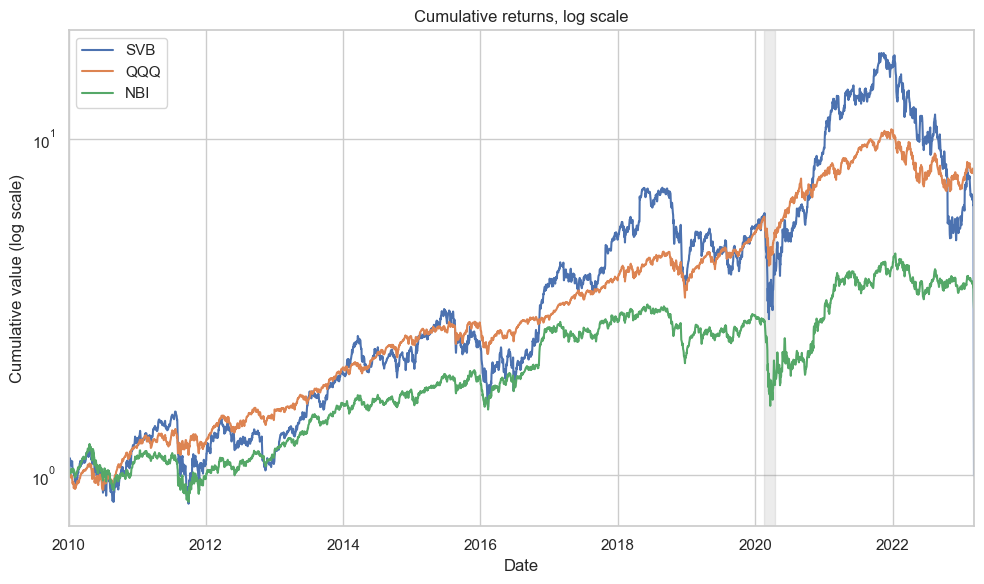

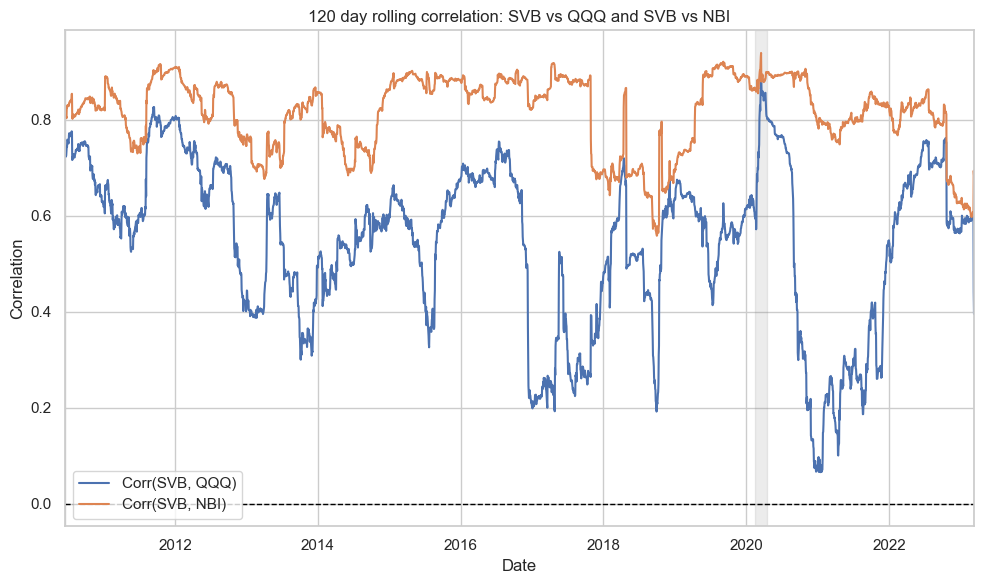

                            OLS Regression Results                            
Dep. Variable:                    SVB   R-squared:                       0.536
Model:                            OLS   Adj. R-squared:                  0.535
Method:                 Least Squares   F-statistic:                     351.7
Date:                Thu, 18 Sep 2025   Prob (F-statistic):          1.51e-139
Time:                        12:44:34   Log-Likelihood:                 8606.8
No. Observations:                3398   AIC:                        -1.721e+04
Df Residuals:                    3395   BIC:                        -1.719e+04
Df Model:                           2                                         
Covariance Type:                  HAC                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
const         -0.0003      0.000     -0.853      0.3

,Coef,t-stat
Variable,,
const,-0.000,-0.85
QQQ,0.368,6.59
NBI,1.200,10.93


In [3]:
# ---------- 1) Cumulative returns, log scale ----------
cum = (1 + ret_df).cumprod()
plt.figure(figsize=(10,6), dpi=100)
ax = plt.gca()
cum.plot(ax=ax)
add_covid_shade(ax)
plt.yscale('log')
plt.title('Cumulative returns, log scale')
plt.xlabel('Date'); plt.ylabel('Cumulative value (log scale)')
plt.tight_layout()
plt.show()


# ---------- 2) Rolling correlations: SVB vs QQQ and SVB vs KBWB ----------
roll = 120  # days
to_plot = {}

if {'SVB','QQQ'}.issubset(ret_df.columns):
    to_plot['Corr(SVB, QQQ)'] = ret_df['SVB'].rolling(roll).corr(ret_df['QQQ'])

if {'SVB','NBI'}.issubset(ret_df.columns):
    to_plot['Corr(SVB, NBI)'] = ret_df['SVB'].rolling(roll).corr(ret_df['NBI'])

if to_plot:
    rc_df = pd.concat(to_plot, axis=1).dropna()
    plt.figure(figsize=(10,6), dpi=100)
    ax = plt.gca()
    rc_df.plot(ax=ax)
    add_covid_shade(ax)
    plt.axhline(0, color='black', linestyle='--', linewidth=1)
    plt.title(f'{roll} day rolling correlation: SVB vs QQQ and SVB vs NBI')
    plt.xlabel('Date'); plt.ylabel('Correlation')
    plt.tight_layout()
    plt.show()

else:
    print("Rolling correlations skipped, missing columns.")

# ---------- 3) Baseline regression: SIVB ~ const + QQQ + NBI ----------
avail = [c for c in ['QQQ','NBI'] if c in ret_df.columns]
if 'SVB' in ret_df.columns and len(avail) > 0:
    covid_start = pd.to_datetime("2020-02-15")
    covid_end   = pd.to_datetime("2020-04-15")
    est_mask = ~((ret_df.index >= covid_start) & (ret_df.index <= covid_end))
    Y = ret_df.loc[est_mask, 'SVB']
    X = ret_df.loc[est_mask, avail]
    XY = pd.concat([Y, X], axis=1).dropna()
    Y_aligned = XY['SVB']
    X_aligned = sm.add_constant(XY[avail])
    model = sm.OLS(Y_aligned, X_aligned).fit(cov_type='HAC', cov_kwds={'maxlags':5})
    print(model.summary())   # keep full statsmodels summary
    baseline_table = format_regression_table(model, "Baseline regression: SVB ~ QQQ + NBI (COVID extremes dropped)")
else:
    print("Missing SVB or regressors for the baseline regression.")

In [4]:
# estimation mask: drop only the extreme covid window
est_mask = ~((ret_df.index >= covid_start) & (ret_df.index <= covid_end))

# ----- 1) estimation dataset (drop covid extremes for regressions only) -----
req = [c for c in ['SVB','QQQ','NBI'] if c in ret_df.columns]
df_reg_all = ret_df[req].dropna().copy()
df_reg = df_reg_all.loc[est_mask].copy()

Y = df_reg['SVB']
X_base = sm.add_constant(df_reg[[c for c in ['QQQ','NBI'] if c in df_reg.columns]])

In [5]:
# ----- 2) Two-state model -----
R2, rcols2 = regime_dummies(Y.index, break_1, None)
X2 = build_X_interactions(X_base, R2, rcols2)
m2 = fit_ols_hac(X2, Y, "Dummy interaction OLS, 2 states (covid extremes dropped)")
tab2 = extract_full_betas(m2, X_base.columns, rcols2)
wald2 = wald_equal_betas(m2, X_base.columns, rcols2)

table2 = make_table(tab2, "Per-regime betas, 2-state: value (t-stat)")

print_wald_short(wald2, "2-state")

fit_stats2 = regime_fit_stats(Y, X_base, tab2, rcols2, R2)
print("\nRegime fit stats (2-state):")
display(fit_stats2)


=== Dummy interaction OLS, 2 states (covid extremes dropped) ===
                            OLS Regression Results                            
Dep. Variable:                    SVB   R-squared:                       0.548
Model:                            OLS   Adj. R-squared:                  0.548
Method:                 Least Squares   F-statistic:                     488.3
Date:                Thu, 18 Sep 2025   Prob (F-statistic):               0.00
Time:                        12:44:34   Log-Likelihood:                 8654.7
No. Observations:                3398   AIC:                        -1.730e+04
Df Residuals:                    3392   BIC:                        -1.726e+04
Df Model:                           5                                         
Covariance Type:                  HAC                                         
                           coef    std err          z      P>|z|      [0.025      0.975]
-------------------------------------------------------

,Pre-2020-07,Post-2020-07
var,,
const,0.000 (0.96),-0.003 (-1.34)
QQQ,0.276 (7.11),0.560 (4.62)
NBI,1.134 (33.19),1.431 (3.97)



Wald equality tests across regimes [2-state]
  const: chi2(1) = 2.09, p = 0.1486
  QQQ: chi2(1) = 4.99, p = 0.02552
  NBI: chi2(1) = 0.67, p = 0.4126

Regime fit stats (2-state):


,Obs,Adj_R2
Regime,,
Pre-2020-07,2773,0.680
Post-2020-07,625,0.419


In [6]:
# ----- 3) Three-state model -----
R3, rcols3 = regime_dummies(Y.index, break_1, break_2)
X3 = build_X_interactions(X_base, R3, rcols3)
m3 = fit_ols_hac(X3, Y, "Dummy interaction OLS, 3 states (covid extremes dropped)")
tab3 = extract_full_betas(m3, X_base.columns, rcols3)
wald3 = wald_equal_betas(m3, X_base.columns, rcols3)

table3 = make_table(tab3, "Per-regime betas, 3-state: value (t-stat)")
print_wald_short(wald3, "3-state")

fit_stats3 = regime_fit_stats(Y, X_base, tab3, rcols3, R3)

print("\nRegime fit stats (3-state):")
display(fit_stats3)


=== Dummy interaction OLS, 3 states (covid extremes dropped) ===
                            OLS Regression Results                            
Dep. Variable:                    SVB   R-squared:                       0.610
Model:                            OLS   Adj. R-squared:                  0.609
Method:                 Least Squares   F-statistic:                     358.8
Date:                Thu, 18 Sep 2025   Prob (F-statistic):               0.00
Time:                        12:44:34   Log-Likelihood:                 8902.1
No. Observations:                3398   AIC:                        -1.779e+04
Df Residuals:                    3389   BIC:                        -1.773e+04
Df Model:                           8                                         
Covariance Type:                  HAC                                         
                                 coef    std err          z      P>|z|      [0.025      0.975]
-------------------------------------------------

,Pre-2020-07,2020-07 to 2022-10,Post-2022-10
var,,,
const,0.000 (0.96),-0.000 (-0.47),-0.006 (-1.29)
QQQ,0.276 (7.11),0.580 (8.62),-0.729 (-0.77)
NBI,1.134 (33.19),1.051 (12.39),4.075 (2.25)



Wald equality tests across regimes [3-state]
  const: chi2(2) = 2.28, p = 0.3195
  QQQ: chi2(2) = 16.57, p = 0.0002524
  NBI: chi2(2) = 3.48, p = 0.1758

Regime fit stats (3-state):


,Obs,Adj_R2
Regime,,
Pre-2020-07,2773,0.680
2020-07 to 2022-10,498,0.670
Post-2022-10,127,0.465


### 2. With Rates (FEDFUNDS)

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import statsmodels.api as sm

start_date = "2010-01-01"
end_date = "2023-03-10"

break_1 = pd.to_datetime("2020-10-18")
break_2 = pd.to_datetime("2022-09-15")

covid_start = pd.to_datetime("2020-02-15")
covid_end   = pd.to_datetime("2020-04-15")

# ---------- Load and reshape ----------
df = pd.read_excel(r"data/Input/SVB/Equity_Mkt_Data.xlsx", skiprows=[1,2])
df = df.rename(columns={'Unnamed: 0': 'Date', 'SIVBQ US Equity': 'SVB', 'Unnamed: 2': 'SVB_net', 'QQQ US Equity': 'QQQ', 'Unnamed: 4': 'QQQ_net', 
        'CBNK Index': 'NBI', 'Unnamed: 6': 'NBI_net', 'BKXTR Index': 'KBW', 'Unnamed: 8': 'KBW_net'})
df['Date'] = pd.to_datetime(df['Date'])

df = df[(df['Date'] >= start_date) & (df['Date'] <= end_date)]
df.set_index('Date', inplace=True)
df = df.div(100)

ret_df = df[['SVB', 'QQQ', 'NBI', 'KBW']]
net_ret_df = df[['SVB_net', 'QQQ_net', 'NBI_net', 'KBW_net']]

# Keep only needed columns if present
cols_needed = [c for c in ['SVB', 'QQQ', 'NBI'] if c in ret_df.columns]
ret_df = ret_df[cols_needed].apply(pd.to_numeric, errors='coerce').sort_index().dropna(how='any')

from fredapi import Fred

# ---------- Add Fed Funds Rate from FRED ----------
fred = Fred(api_key="f7bd6800ee6e028d316414339437dd09")

# Download daily effective Fed Funds Rate (percent)
fed = fred.get_series("DFF", start_date, end_date)

# Put in DataFrame, convert to decimal
fed = fed.to_frame(name="FEDFUNDS") / 100.0

# Merge into returns DataFrame
ret_df = ret_df.join(fed, how="left").ffill()

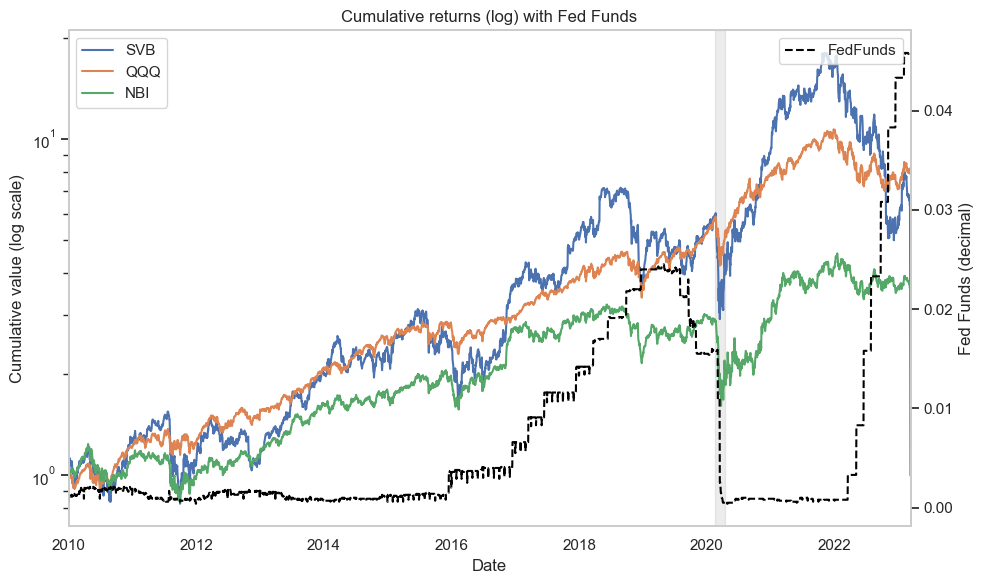

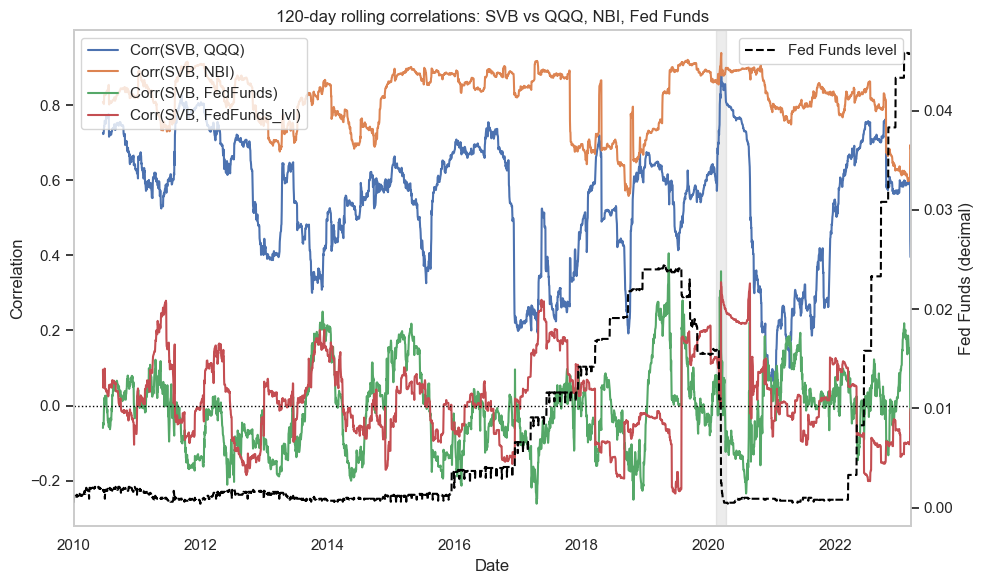

                            OLS Regression Results                            
Dep. Variable:                    SVB   R-squared:                       0.538
Model:                            OLS   Adj. R-squared:                  0.537
Method:                 Least Squares   F-statistic:                     255.4
Date:                Thu, 18 Sep 2025   Prob (F-statistic):          4.60e-192
Time:                        13:52:57   Log-Likelihood:                 8612.7
No. Observations:                3397   AIC:                        -1.722e+04
Df Residuals:                    3392   BIC:                        -1.718e+04
Df Model:                           4                                         
Covariance Type:                  HAC                                         
                   coef    std err          z      P>|z|      [0.025      0.975]
--------------------------------------------------------------------------------
const            0.0006      0.001      1.146   

,Coef,t-stat
Variable,,
const,0.001,1.15
QQQ,0.370,6.81
NBI,1.196,11.31
FEDFUNDS,-0.143,-1.17
FEDFUNDS_lvl,0.581,0.74



Variance Inflation Factors (VIF) for regressors:


,feature,VIF
0,const,1.516753
1,QQQ,1.534362
2,NBI,1.536445
3,FEDFUNDS,1.007105
4,FEDFUNDS_lvl,1.006367


Note: VIF > 5-10 indicates potential collinearity issues.


In [37]:
cum = (1 + ret_df[['SVB','QQQ','NBI']]).cumprod()

fig, ax1 = plt.subplots(figsize=(10,6), dpi=100)
cum.plot(ax=ax1)
ax1.set_yscale('log')
ax1.set_ylabel('Cumulative value (log scale)')
add_covid_shade(ax1)

# Secondary axis for Fed Funds
ax2 = ax1.twinx()
ret_df['FEDFUNDS'].plot(ax=ax2, color='black', linestyle='--', label='FedFunds')
ax2.set_ylabel('Fed Funds (decimal)')
ax2.grid(False)
ax1.grid(False)
# Titles & legends
ax1.set_title('Cumulative returns (log) with Fed Funds')
ax1.legend(loc='upper left')
ax2.legend(loc='upper right')
plt.tight_layout()
plt.show()

roll = 120
to_plot = {}

# Add Fed funds pct changes and level changes
ret_df['FEDFUNDS_lvl'] = ret_df['FEDFUNDS'].diff()

if {'SVB','QQQ'}.issubset(ret_df.columns):
    to_plot['Corr(SVB, QQQ)'] = ret_df['SVB'].rolling(roll).corr(ret_df['QQQ'])
if {'SVB','NBI'}.issubset(ret_df.columns):
    to_plot['Corr(SVB, NBI)'] = ret_df['SVB'].rolling(roll).corr(ret_df['NBI'])
if 'FEDFUNDS' in ret_df.columns:
    to_plot['Corr(SVB, FedFunds)'] = ret_df['SVB'].rolling(roll).corr(ret_df['FEDFUNDS'])
if 'FEDFUNDS_lvl' in ret_df.columns:
    to_plot['Corr(SVB, FedFunds_lvl)'] = ret_df['SVB'].rolling(roll).corr(ret_df['FEDFUNDS_lvl'])

if to_plot:
    rc_df = pd.concat(to_plot, axis=1).dropna()

    fig, ax1 = plt.subplots(figsize=(10,6), dpi=100)
    rc_df.plot(ax=ax1)
    add_covid_shade(ax1)
    ax1.axhline(0, color='black', linestyle=':', linewidth=1)
    ax1.set_ylabel("Correlation")
    ax1.set_title(f"{roll}-day rolling correlations: SVB vs QQQ, NBI, Fed Funds")
    ax1.grid(False)
    # Secondary axis: Fed Funds levels
    ax2 = ax1.twinx()
    ret_df['FEDFUNDS'].plot(ax=ax2, color='black', linestyle='--', label='Fed Funds level')
    # ax2.plot(ret_df['FEDFUNDS'], color='black', linestyle='--', label='Fed Funds level')
    ax2.set_ylabel("Fed Funds (decimal)")
    ax2.grid(False)
    # Legends
    ax1.legend(loc="upper left")
    ax2.legend(loc="upper right")

    plt.tight_layout()
    plt.show()
else:
    print("Rolling correlations skipped, missing columns.")

# ---------- 3) Baseline regression: SIVB ~ const + QQQ + NBI ----------
avail = [c for c in ['QQQ','NBI', 'FEDFUNDS', 'FEDFUNDS_lvl'] if c in ret_df.columns]
if 'SVB' in ret_df.columns and len(avail) > 0:
    covid_start = pd.to_datetime("2020-02-15")
    covid_end   = pd.to_datetime("2020-04-15")
    est_mask = ~((ret_df.index >= covid_start) & (ret_df.index <= covid_end))
    Y = ret_df.loc[est_mask, 'SVB']
    X = ret_df.loc[est_mask, avail]
    XY = pd.concat([Y, X], axis=1).dropna()
    Y_aligned = XY['SVB']
    X_aligned = sm.add_constant(XY[avail])
    model = sm.OLS(Y_aligned, X_aligned).fit(cov_type='HAC', cov_kwds={'maxlags':5})
    print(model.summary())   # keep full statsmodels summary
    baseline_table = format_regression_table(model, "Baseline regression: SVB ~ QQQ + NBI (COVID extremes dropped)")
else:
    print("Missing SVB or regressors for the baseline regression.")

# Test collinearity of regressors (show acceptance treshold)
from statsmodels.stats.outliers_influence import variance_inflation_factor
if len(avail) > 1:
    X_test = sm.add_constant(ret_df[avail].dropna())
    vif_data = pd.DataFrame()
    vif_data["feature"] = X_test.columns
    vif_data["VIF"] = [variance_inflation_factor(X_test.values, i) for i in range(X_test.shape[1])]
    print("\nVariance Inflation Factors (VIF) for regressors:")
    display(vif_data)
    print("Note: VIF > 5-10 indicates potential collinearity issues.")

In [29]:
# ----- 1) estimation dataset (drop covid extremes for regressions only) -----
req = [c for c in ['SVB','QQQ','NBI', 'FEDFUNDS', 'FEDFUNDS_lvl'] if c in ret_df.columns]
df_reg_all = ret_df[req].dropna().copy()
# Align the mask to df_reg_all's index
est_mask_aligned = ~((df_reg_all.index >= covid_start) & (df_reg_all.index <= covid_end))
df_reg = df_reg_all.loc[est_mask_aligned].copy()

Y = df_reg['SVB']
X_base = sm.add_constant(df_reg[[c for c in ['QQQ','NBI','FEDFUNDS', 'FEDFUNDS_lvl'] if c in df_reg.columns]])

# ----- 2) Two-state model -----
R2, rcols2 = regime_dummies(Y.index, break_1, None)
X2 = build_X_interactions(X_base, R2, rcols2)
m2 = fit_ols_hac(X2, Y, "Dummy interaction OLS, 2 states (covid extremes dropped)")
tab2 = extract_full_betas(m2, X_base.columns, rcols2)
wald2 = wald_equal_betas(m2, X_base.columns, rcols2)

table2 = make_table(tab2, "Per-regime betas, 2-state: value (t-stat)")

print_wald_short(wald2, "2-state")

fit_stats2 = regime_fit_stats(Y, X_base, tab2, rcols2, R2)
print("\nRegime fit stats (2-state):")
display(fit_stats2)


=== Dummy interaction OLS, 2 states (covid extremes dropped) ===
                            OLS Regression Results                            
Dep. Variable:                    SVB   R-squared:                       0.552
Model:                            OLS   Adj. R-squared:                  0.551
Method:                 Least Squares   F-statistic:                     275.8
Date:                Thu, 18 Sep 2025   Prob (F-statistic):               0.00
Time:                        13:49:15   Log-Likelihood:                 8665.4
No. Observations:                3397   AIC:                        -1.731e+04
Df Residuals:                    3387   BIC:                        -1.725e+04
Df Model:                           9                                         
Covariance Type:                  HAC                                         
                                  coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------

,Pre-2020-07,Post-2020-07
var,,
const,0.000 (0.91),0.000 (0.02)
QQQ,0.276 (7.11),0.574 (5.04)
NBI,1.134 (33.18),1.419 (4.11)
FEDFUNDS,-0.005 (-0.15),-0.249 (-1.16)
FEDFUNDS_lvl,0.960 (1.05),1.907 (1.23)



Wald equality tests across regimes [2-state]
  const: chi2(1) = 0.06, p = 0.7999
  QQQ: chi2(1) = 6.14, p = 0.01324
  NBI: chi2(1) = 0.68, p = 0.411
  FEDFUNDS: chi2(1) = 1.26, p = 0.2609
  FEDFUNDS_lvl: chi2(1) = 0.28, p = 0.5984

Regime fit stats (2-state):


,Obs,Adj_R2
Regime,,
Pre-2020-07,2772,0.680
Post-2020-07,625,0.424


In [30]:
# ----- 3) Three-state model -----
R3, rcols3 = regime_dummies(Y.index, break_1, break_2)
X3 = build_X_interactions(X_base, R3, rcols3)
m3 = fit_ols_hac(X3, Y, "Dummy interaction OLS, 3 states (covid extremes dropped)")
tab3 = extract_full_betas(m3, X_base.columns, rcols3)
wald3 = wald_equal_betas(m3, X_base.columns, rcols3)
wald3_pw = wald_pairwise_betas(m3, X_base.columns, rcols3)
table3 = make_table(tab3, "Per-regime betas, 3-state: value (t-stat)")

print_wald_short(wald3, "3-state")
print_wald_pairwise(wald3_pw, "3-state")

fit_stats3 = regime_fit_stats(Y, X_base, tab3, rcols3, R3)

print("\nRegime fit stats (3-state):")
display(fit_stats3)


=== Dummy interaction OLS, 3 states (covid extremes dropped) ===
                            OLS Regression Results                            
Dep. Variable:                    SVB   R-squared:                       0.610
Model:                            OLS   Adj. R-squared:                  0.609
Method:                 Least Squares   F-statistic:                     205.6
Date:                Thu, 18 Sep 2025   Prob (F-statistic):               0.00
Time:                        13:49:16   Log-Likelihood:                 8901.9
No. Observations:                3397   AIC:                        -1.777e+04
Df Residuals:                    3382   BIC:                        -1.768e+04
Df Model:                          14                                         
Covariance Type:                  HAC                                         
                                        coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------

,Pre-2020-07,2020-07 to 2022-10,Post-2022-10
var,,,
const,0.000 (0.91),-0.000 (-0.01),-0.019 (-0.68)
QQQ,0.276 (7.11),0.584 (8.61),-0.737 (-0.80)
NBI,1.134 (33.18),1.053 (12.32),4.105 (2.29)
FEDFUNDS,-0.005 (-0.15),-0.100 (-0.86),0.305 (0.44)
FEDFUNDS_lvl,0.960 (1.05),1.507 (1.08),2.280 (1.06)



Wald equality tests across regimes [3-state]
  const: chi2(2) = 0.59, p = 0.7463
  QQQ: chi2(2) = 16.89, p = 0.000215
  NBI: chi2(2) = 3.54, p = 0.1701
  FEDFUNDS: chi2(2) = 0.78, p = 0.6778
  FEDFUNDS_lvl: chi2(2) = 0.36, p = 0.8343

Pairwise Wald tests across regimes [3-state]
  const:
    Pre-2020-07 vs 2020-07 to 2022-10: chi2(1) = 0.10, p = 0.7505
    Pre-2020-07 vs Post-2022-10: chi2(1) = 0.48, p = 0.4892
    2020-07 to 2022-10 vs Post-2022-10: chi2(1) = 0.46, p = 0.4955
  QQQ:
    Pre-2020-07 vs 2020-07 to 2022-10: chi2(1) = 15.54, p = 8.072e-05
    Pre-2020-07 vs Post-2022-10: chi2(1) = 1.21, p = 0.2717
    2020-07 to 2022-10 vs Post-2022-10: chi2(1) = 2.04, p = 0.1527
  NBI:
    Pre-2020-07 vs 2020-07 to 2022-10: chi2(1) = 0.77, p = 0.3791
    Pre-2020-07 vs Post-2022-10: chi2(1) = 2.75, p = 0.0974
    2020-07 to 2022-10 vs Post-2022-10: chi2(1) = 2.89, p = 0.08892
  FEDFUNDS:
    Pre-2020-07 vs 2020-07 to 2022-10: chi2(1) = 0.61, p = 0.4363
    Pre-2020-07 vs Post-2022-10: c

,Obs,Adj_R2
Regime,,
Pre-2020-07,2772,0.680
2020-07 to 2022-10,498,0.670
Post-2022-10,127,0.458


In [31]:
import pandas as pd

def find_consecutive_declines(returns, min_length=2):
    """
    Find uninterrupted streaks of consecutive negative returns.

    Parameters
    ----------
    returns : pd.Series
        Daily returns in decimal (e.g., -0.02 for -2%).
    min_length : int
        Minimum streak length (number of consecutive negative days).

    Returns
    -------
    list of dict
        Each dict has: start, end, length, cumulative_return.
    """
    declines = []
    start = None
    streak = []

    for date, r in returns.items():
        if r < 0:
            if start is None:
                start = date
            streak.append(r)
        else:
            if start is not None and len(streak) >= min_length:
                end = date - pd.Timedelta(days=1)
                cum_ret = (1 + pd.Series(streak)).prod() - 1
                declines.append({
                    "start": start,
                    "end": end,
                    "length": len(streak),
                    "cumulative_return": cum_ret
                })
            start = None
            streak = []

    # Handle case if series ends in a decline
    if start is not None and len(streak) >= min_length:
        end = returns.index[-1]
        cum_ret = (1 + pd.Series(streak)).prod() - 1
        declines.append({
            "start": start,
            "end": end,
            "length": len(streak),
            "cumulative_return": cum_ret
        })

    return declines


# -------- Example usage ----------
svb_rets = ret_df['SVB'].dropna()
drops = find_consecutive_declines(svb_rets, min_length=3)
drops_df = pd.DataFrame(drops)
ret_df["2022-10-17":"2022-10-24"]

,SVB,QQQ,NBI,FEDFUNDS,FEDFUNDS_lvl
Date,,,,,
2022-10-17,0.049533,0.033021,0.024063,0.0308,0.0
2022-10-18,-0.010404,0.007908,0.002392,0.0308,0.0
2022-10-19,-0.044449,-0.003647,-0.015594,0.0308,0.0
2022-10-20,-0.040936,-0.005102,-0.034322,0.0308,0.0
2022-10-21,-0.239470,0.023448,0.007041,0.0308,0.0
2022-10-24,0.008608,0.011001,0.013620,0.0308,0.0
